# data import

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

from datetime import datetime, timedelta

from scipy.stats import gaussian_kde
from scipy.signal import find_peaks
from scipy.signal import periodogram
from scipy.stats import entropy
from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.fft import fft, fftfreq

from statsmodels.tsa.stattools import acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import coint

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import BallTree

import random

from pandas.tseries.offsets import DateOffset

from collections import defaultdict

from hmmlearn.hmm import GaussianHMM


In [2]:
import plotly.io as pio
pio.renderers.default = "browser" 

## node DA LMP

In [ ]:
import polars as pl

file_path = "data/nodeDALMPH/NodeDALMPH_2025.csv"

result = (
    pl.scan_csv(
        file_path,
        skip_rows_after_header=1,   # equivalent to pandas skiprows=[1]
        schema_overrides={
            "NodeKey": pl.Int64,
            "Congestion": pl.Float64,
        },
        try_parse_dates=True,
        infer_schema_length=10_000,
    )
    .filter(pl.col("MarketDateTime") > pl.datetime(2025, 1, 1))
    .collect()
)

result.head()

In [ ]:
df = result.to_pandas()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

df.head()

In [ ]:
df['nodekey'].nunique()

In [ ]:
# vc = df['nodekey'].value_counts()

# # maximum occurrence count
# max_count = vc.max()

# # nodekeys that have the maximum count
# max_nodekeys = vc[vc == max_count].index

# # filter dataframe
# df = df[
#     df['nodekey'].isin(max_nodekeys)
# ]

# df.head()

In [ ]:
# df['nodekey'].nunique()

In [ ]:
# # make sure date is datetime
# df['marketdatetime'] = pd.to_datetime(df['marketdatetime'])

# # count how many existing nodekeys appear each day
# daily_counts = (
#     df
#     .groupby('marketdatetime')['nodekey']
#     .nunique()
#     .reset_index(name='num_nodekeys')
# )

# # plot
# fig = px.line(
#     daily_counts,
#     x='marketdatetime',
#     y='num_nodekeys',
#     markers=True,
#     title='Number of Existing NodeKeys Per Day'
# )

# fig.update_layout(
#     xaxis_title='Date',
#     yaxis_title='Number of NodeKeys',
#     hovermode='x unified',
#     template='plotly_white'
# )

# fig.show()

## node

In [ ]:
node = pd.read_csv('data/nodeDALMPH/Node.csv')
node.columns = (
    node.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

node.head()

In [ ]:
node["nodekey"].nunique()

## node lat lon

In [ ]:
pnode_to_bus = pd.read_csv('data/pnode_with_loc.csv')
pnode_to_bus.columns = (
    pnode_to_bus.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

dtype_map = {
    "psse_bus_#": "string",
    "substation": "string",
    "nodename": "string",
    "nodekey": "int64",
    "lon": "float64",
    "lat": "float64",
}

pnode_to_bus["externalnodeid"] = pnode_to_bus["externalnodeid"].astype("string").str.replace(r"\.0$", "", regex=True)

pnode_to_bus = pnode_to_bus.astype(dtype_map)

pnode_to_bus.head()

In [ ]:
pnode_to_bus["nodekey"].nunique()

In [ ]:
node_lmp = df.merge(node[["nodekey", "nodename", "zone"]], how="inner", on="nodekey")

In [ ]:
node_lmp.head()

In [ ]:
node_lmp = node_lmp.merge(pnode_to_bus[["externalnodeid", "nodekey", "nodename", "lat", "lon"]], how="inner", on=["nodekey", "nodename"])

In [ ]:
node_lmp.head()

In [ ]:
node_lmp['nodekey'].nunique()

In [ ]:
node_lmp['zone'].unique()

In [ ]:
standard_map = {
    # Already standard / keep as-is
    'DAY': 'DAY',
    'COMED': 'COMED',
    'PEPCO': 'PEPCO',
    'AEP': 'AEP',
    'AECO': 'AECO',
    'DOM': 'DOM',
    'PSEG': 'PSEG',
    'APS': 'APS',
    'DPL': 'DPL',
    'PENELEC': 'PENELEC',
    'METED': 'METED',
    'RECO': 'RECO',
    'PECO': 'PECO',
    'PPL': 'PPL',
    'DUQ': 'DUQ',
    'BGE': 'BGE',
    'JCPL': 'JCPL',
    'DUKE': 'DUKE',
    'CPL': 'DOM',
    'ATSI': 'ATSI',
    'DEOK': 'DEOK',

    # Aggregate/system categories
    'LOAD': 'LOAD',
    'GEN': 'GENERATION',

    # Short aliases → standard zones
    'PE': 'PECO',
    'PL': 'PPL',
    'JC': 'JCPL',
    'PN': 'PENELEC',
    'PS': 'PSEG',
    'AP': 'APS',
    'PS-S': 'PSEG',
    'ME': 'METED',
    'AE': 'AECO',

    # Other entities
    'EKPC': 'EKPC',
    'OVEC': 'AEP',

    # Missing / placeholders
    'NONE': None,
    'MANUAL': None,
    np.nan: None
}

node_lmp['zone'] = node_lmp['zone'].map(standard_map)

In [ ]:
node_lmp = node_lmp[node_lmp['zone'].isin([
    'AECO', 'AEP', 'APS', 'ATSI', 'BGE',
    'COMED', 'DEOK', 'DOM', 'DPL', 'DUQ',
    'EKPC', 'JCPL', 'METED', 'PE', 'PECO',
    'PENELEC', 'PEPCO', 'PPL', 'PSEG', 'RECO'
])].copy()


In [ ]:
node_lmp['nodekey'].nunique()

In [ ]:
# fig = px.histogram(
#     pnode_to_bus,
#     x="nodekey",
#     nbins=500,
#     title="Distribution of Pnode Nodekeys"
# )

# fig.update_layout(
#     xaxis_title="Nodekey",
#     yaxis_title="Count",
#     bargap=0.05
# )

# fig.show()

## node NM

In [ ]:
node_bid_type = pd.read_csv('data/nodeDALMPH/node_bid_type.csv')

node_bid_type.columns = (
    node_bid_type.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

node_bid_type.rename(columns={'node_name': 'nodename'}, inplace=True)

node_bid_type.head()

In [ ]:
node_bid_type["bid_type_code"].value_counts()

In [ ]:
node_bid_type = node_bid_type[node_bid_type['bid_type_code'] == 'PM'].copy()

In [ ]:
# Merge bid_type_code into node_lmp using nodename <-> node_name correspondence
node_lmp_pm = node_lmp.merge(
    node_bid_type[['nodename', 'bid_type_code']],
    on = 'nodename',
    how='left'
)

node_lmp_pm.head()

In [ ]:
node_lmp_pm = node_lmp_pm[node_lmp_pm['bid_type_code'] == 'PM'].copy()
node_lmp_pm.head()

In [ ]:
node_lmp_pm['nodekey'].nunique()

In [ ]:
# node_lmp_pm.to_csv('data/nodeDALMPH/hourly_congestion_pm.csv', index=False)

## duplicates

In [3]:
node_lmp = pd.read_csv('data/nodeDALMPH/hourly_congestion_pm.csv')
node_lmp.head()

,nodekey,congestion,marketdatetime,nodename,zone,externalnodeid,lat,lon,bid_type_code
0,361,-1.32,2025-01-01 01:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
1,361,-1.22,2025-01-01 02:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
2,361,-1.64,2025-01-01 03:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
3,361,-1.62,2025-01-01 04:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
4,361,-1.51,2025-01-01 05:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM


In [4]:
node_lmp = (
    node_lmp
    .sort_values(['nodekey', 'marketdatetime'])
    .drop_duplicates(['nodekey', 'marketdatetime'], keep='first')
) 

# node_lmp = node_lmp[node_lmp["marketdatetime"] != "2026-01-02 04:00:00"].copy()

today = pd.Timestamp.today().normalize()
current_year = today.year

# current year: 3 months ago -> now
current_start = (today - DateOffset(months=2)).replace(day=1)

# last year: same month -> 3 months later
last_year_start = pd.Timestamp(current_year - 1, today.month - 2, 1)
last_year_end = (
    last_year_start + DateOffset(months=5) - pd.Timedelta(seconds=1)
)

max_dt = node_lmp["marketdatetime"].max()

node_lmp["marketdatetime"] = pd.to_datetime(node_lmp["marketdatetime"])

node_lmp = node_lmp.loc[
    (node_lmp["marketdatetime"].between(last_year_start, last_year_end))
    |
    (node_lmp["marketdatetime"].between(current_start, max_dt))
].copy()

In [5]:
node_lmp['nodekey'].nunique()

6528

In [6]:
vc = node_lmp['nodekey'].value_counts()

# maximum occurrence count
max_count = vc.max()

# nodekeys that have the maximum count
max_nodekeys = vc[vc == max_count].index

# filter dataframe
node_lmp = node_lmp[
    node_lmp['nodekey'].isin(max_nodekeys)
].copy()

node_lmp.head()

,nodekey,congestion,marketdatetime,nodename,zone,externalnodeid,lat,lon,bid_type_code
9169198,361,-6.49,2025-03-01 00:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169199,361,-7.02,2025-03-01 01:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169200,361,-7.52,2025-03-01 02:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169201,361,-7.96,2025-03-01 03:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169202,361,-8.14,2025-03-01 04:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM


In [7]:
# Pivot so each nodekey becomes a row with dates as columns
pivot = node_lmp.pivot(index='nodekey', columns='marketdatetime', values='congestion')

# Round to reduce noise
pivot_rounded = pivot.round()

# Drop near-duplicates
deduped = pivot_rounded.drop_duplicates()

nodekeys_to_keep = deduped.index

# Filter original dataframe
node_lmp = node_lmp[node_lmp['nodekey'].isin(nodekeys_to_keep)]

node_lmp.head()

,nodekey,congestion,marketdatetime,nodename,zone,externalnodeid,lat,lon,bid_type_code
9169198,361,-6.49,2025-03-01 00:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169199,361,-7.02,2025-03-01 01:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169200,361,-7.52,2025-03-01 02:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169201,361,-7.96,2025-03-01 03:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM
9169202,361,-8.14,2025-03-01 04:00:00,1 LASALL138 KV TR041 04,COMED,32406703,41.234642,-88.688491,PM


In [8]:
node_lmp['nodekey'].nunique()

5147

## filter pairs

In [9]:
node_lmp.groupby('zone')['nodekey'].nunique()

zone
AECO         87
AEP        1351
APS         338
ATSI        581
BGE          81
COMED       511
DEOK        229
DOM         563
DPL         138
DUQ          41
EKPC        299
JCPL         55
METED       115
PECO        141
PENELEC     172
PEPCO        38
PPL         225
PSEG        174
RECO          8
Name: nodekey, dtype: int64

### quantile

In [10]:
# # 10%-90% congestion bounds within each zone + date
# bounds = (
#     node_lmp
#     .groupby(["zone", "marketdatetime"])["congestion"]
#     .quantile([0.02, 0.98])
#     .unstack()
#     .rename(columns={0.02: "p5", 0.98: "p95"})
#     .reset_index()
# )

# df = node_lmp.merge(bounds, on=["zone", "marketdatetime"], how="left")

# # flag rows where node is outside daily zone-level 5%-95% range
# df["outside_5_95"] = (
#     (df["congestion"] < df["p5"]) |
#     (df["congestion"] > df["p95"])
# )

# # percentage of dates each nodekey is outside the range
# node_outside_pct = (
#     df.groupby("nodekey")["outside_5_95"]
#     .mean()
#     .reset_index(name="outside_pct")
# )

# # nodekeys outside the band on more than 10% of dates
# bad_nodekeys = node_outside_pct.loc[
#     node_outside_pct["outside_pct"] > 0.20,
#     "nodekey"
# ]

# # filtered dataset: removes those nodekeys and keeps their information out
# node_lmp_day_filtered = (
#     node_lmp
#     .loc[node_lmp["nodekey"].isin(bad_nodekeys)]
#     .copy()
# )

# # information for removed nodekeys
# removed_node_info = (
#     node_lmp
#     .loc[~node_lmp["nodekey"].isin(bad_nodekeys)]
#     .merge(node_outside_pct, on="nodekey", how="left")
#     .copy()
# )

# node_lmp_day_filtered.head()

In [11]:
# node_lmp_day_filtered['nodekey'].nunique()

### MAD

In [12]:
# zone_stats = (
#     node_lmp
#     .groupby(["zone", "marketdatetime"])["congestion"]
#     .agg(
#         zone_median="median",
#         zone_mad=lambda x: np.median(
#             np.abs(x - np.median(x))
#         )
#     )
#     .reset_index()
# )

# df = node_lmp.merge(
#     zone_stats,
#     on=["zone", "marketdatetime"],
#     how="left"
# )

# df["zone_mad"] = df["zone_mad"].replace(0, np.nan)

# df["robust_score"] = (
#     (df["congestion"] - df["zone_median"]).abs()
#     / df["zone_mad"]
# )

# # df["robust_score"] = np.log(df["robust_score"] + 1)
# # df["robust_score"] = np.sqrt(df["robust_score"])

# node_scores = (
#     df.groupby("nodekey")
#     .agg(
#         avg_score=("robust_score", "mean"),
#         p95_score=("robust_score", lambda x: x.quantile(0.90)),
#         freq_large=("robust_score", lambda x: (x > 5).mean())
#     )
#     .reset_index()
# )

# # global 95th percentile of node average scores
# threshold = node_scores["avg_score"].quantile(0.95)

# bad_nodekeys = node_scores.loc[
#     (node_scores["avg_score"] > threshold) &
#     (node_scores["freq_large"] > 0.05),
#     "nodekey"
# ]

# node_lmp_day_filtered = (
#     node_lmp
#     .loc[node_lmp["nodekey"].isin(bad_nodekeys)]
#     .copy()
# )

# node_lmp_day_filtered.head()

In [13]:
# node_lmp_day_filtered['nodekey'].nunique()

In [14]:
# import plotly.graph_objects as go

# # choose node
# selected_node = 3888

# # node data
# node_df = (
#     node_lmp_day_filtered
#     .loc[node_lmp_day_filtered["nodekey"] == selected_node]
#     .copy()
# )

# # ensure datetime
# node_df["marketdatetime"] = pd.to_datetime(node_df["marketdatetime"])

# # get node zone
# selected_zone = node_df["zone"].iloc[0]

# # zone mean congestion by marketdatetime
# zone_mean = (
#     node_lmp_day_filtered
#     .loc[node_lmp_day_filtered["zone"] == selected_zone]
#     .groupby("marketdatetime")["congestion"]
#     .mean()
#     .reset_index(name="zone_mean_congestion")
# )

# zone_mean["marketdatetime"] = pd.to_datetime(zone_mean["marketdatetime"])

# # merge for plotting
# plot_df = node_df.merge(
#     zone_mean,
#     on="marketdatetime",
#     how="left"
# )

# # plot
# fig = go.Figure()

# # node congestion
# fig.add_trace(
#     go.Scatter(
#         x=plot_df["marketdatetime"],
#         y=plot_df["congestion"],
#         mode="lines",
#         name=f"Node {selected_node} Congestion"
#     )
# )

# # zone mean congestion
# fig.add_trace(
#     go.Scatter(
#         x=plot_df["marketdatetime"],
#         y=plot_df["zone_mean_congestion"],
#         mode="lines",
#         name=f"{selected_zone} Zone Mean",
#         line=dict(dash="dash")
#     )
# )

# fig.update_layout(
#     title=f"Node vs Zone Mean Congestion<br>{selected_node} ({selected_zone})",
#     xaxis_title="Market Datetime",
#     yaxis_title="Congestion",
#     template="plotly_white",
#     hovermode="x unified",
#     height=600
# )

# fig.show()

### zonal MAD

In [15]:
zone_stats = (
    node_lmp
    .groupby(["zone", "marketdatetime"])["congestion"]
    .agg(
        zone_median="median",
        zone_mad=lambda x: np.median(np.abs(x - np.median(x)))
    )
    .reset_index()
)

df = node_lmp.merge(
    zone_stats,
    on=["zone", "marketdatetime"],
    how="left"
)

df["zone_mad"] = df["zone_mad"].replace(0, np.nan)

df["robust_score"] = (
    (df["congestion"] - df["zone_median"]).abs()
    / df["zone_mad"]
)

# df["robust_score"] = np.log(df["robust_score"] + 1)

node_scores = (
    df.groupby(["zone", "nodekey"])
    .agg(
        avg_score=("robust_score", "mean"),
        # p90_score=("robust_score", lambda x: x.quantile(0.90)),
        freq_large=("robust_score", lambda x: (x > 5).mean())
    )
    .reset_index()
)

# # 95th percentile of node avg_score within each zone
# node_scores["zone_avg_threshold"] = (
#     node_scores
#     .groupby("zone")["avg_score"]
#     .transform(lambda x: x.quantile(0.95))
# )

# bad_nodekeys = node_scores.loc[
#     (node_scores["avg_score"] > node_scores["zone_avg_threshold"]) &
#     (node_scores["freq_large"] > 0.10),
#     "nodekey"
# ]

# number of nodes to keep per zone
zone_top_n = (
    node_lmp
    .groupby("zone")["nodekey"]
    .nunique()
    .pow(0.5)          # sqrt
    .round()
    .astype(int)
    .rename("top_n")
)

# merge top_n back
node_scores = node_scores.merge(
    zone_top_n,
    on="zone",
    how="left"
)

# rank avg_score within each zone
node_scores["zone_rank"] = (
    node_scores
    .groupby("zone")["avg_score"]
    .rank(method="first", ascending=False)
)

# select bad nodes
bad_nodekeys = node_scores.loc[
    (node_scores["zone_rank"] <= node_scores["top_n"]) &
    (node_scores["freq_large"] > 0.10),
    "nodekey"
]

node_lmp_day_filtered = (
    node_lmp
    .loc[node_lmp["nodekey"].isin(bad_nodekeys)]
    .copy()
)

node_lmp_day_filtered.head()

,nodekey,congestion,marketdatetime,nodename,zone,externalnodeid,lat,lon,bid_type_code
9202678,517,-23.469999,2025-03-01 00:00:00,125 NORM138 KV TR77 34,COMED,32406977,41.621187,-89.723244,PM
9202679,517,-18.070000,2025-03-01 01:00:00,125 NORM138 KV TR77 34,COMED,32406977,41.621187,-89.723244,PM
9202680,517,-17.709999,2025-03-01 02:00:00,125 NORM138 KV TR77 34,COMED,32406977,41.621187,-89.723244,PM
9202681,517,-16.450001,2025-03-01 03:00:00,125 NORM138 KV TR77 34,COMED,32406977,41.621187,-89.723244,PM
9202682,517,-14.130000,2025-03-01 04:00:00,125 NORM138 KV TR77 34,COMED,32406977,41.621187,-89.723244,PM


In [16]:
node_lmp_day_filtered["nodekey"].nunique()

252

In [17]:
# # Plot all nodes on a map
# fig = px.scatter_map(
#     node_lmp_day_filtered.drop_duplicates(subset=["nodekey"]),  # optional: one point per node
#     lat="lat",
#     lon="lon",
#     hover_name="nodename",
#     hover_data={
#         "nodekey": True,
#         "zone": True,
#         "externalnodeid": False,
#         "lat": True,
#         "lon": True
#     },
#     zoom=5,
#     height=700
# )

# fig.update_layout(
#     mapbox_style="carto-positron",   # or "open-street-map"
#     margin={"r":0, "t":0, "l":0, "b":0}
# )

# fig.show()

# Congestion spread

In [18]:
# 1) node1 pool: filtered nodes
nodes1 = (
    node_lmp_day_filtered[["nodekey", "lat", "lon"]]
    .drop_duplicates("nodekey")
    .reset_index(drop=True)
)

# 2) node2 pool: all nodes
nodes2 = (
    node_lmp[["nodekey", "lat", "lon"]]
    .drop_duplicates("nodekey")
    .reset_index(drop=True)
)

# coordinates
coords1_rad = np.radians(nodes1[["lat", "lon"]].to_numpy())
coords2_rad = np.radians(nodes2[["lat", "lon"]].to_numpy())

# build tree on node2 pool
tree = BallTree(coords2_rad, metric="haversine")

earth_radius_miles = 3958.7613
radius_miles = 10
radius_rad = radius_miles / earth_radius_miles

# find node2 neighbors within 5 miles for each node1
ind, dist = tree.query_radius(
    coords1_rad,
    r=radius_rad,
    return_distance=True,
    sort_results=True
)

pairs = []

for i, node1 in enumerate(nodes1["nodekey"]):
    for j, d in zip(ind[i], dist[i]):

        node2 = nodes2.loc[j, "nodekey"]

        # skip same node
        if node1 == node2:
            continue

        pairs.append({
            "nodekey1": node1,
            "nodekey2": node2,
            "pair": f"{node1}-{node2}",
            "distance": d * earth_radius_miles
        })

nearest_pairs = pd.DataFrame(pairs)

# make nodekey1-nodekey2 consistently small-large
mask = nearest_pairs["nodekey1"] > nearest_pairs["nodekey2"]

nearest_pairs.loc[mask, ["nodekey1", "nodekey2"]] = (
    nearest_pairs.loc[mask, ["nodekey2", "nodekey1"]].to_numpy()
)

nearest_pairs["pair"] = (
    nearest_pairs["nodekey1"].astype(str)
    + "-"
    + nearest_pairs["nodekey2"].astype(str)
)

nearest_pairs = nearest_pairs.drop_duplicates(
    ["nodekey1", "nodekey2"]
).reset_index(drop=True)


# 3) calculate congestion spread over time
wide1 = node_lmp_day_filtered.pivot_table(
    index="marketdatetime",
    columns="nodekey",
    values="congestion"
)

wide2 = node_lmp.pivot_table(
    index="marketdatetime",
    columns="nodekey",
    values="congestion"
)

spread_rows = []

for _, r in nearest_pairs.iterrows():

    n1, n2 = r["nodekey1"], r["nodekey2"]

    if n1 in wide1.columns and n2 in wide2.columns:

        common_dates = wide1.index.intersection(wide2.index)

        tmp = pd.DataFrame({
            "date": common_dates,
            "nodekey1": n1,
            "nodekey2": n2,
            "pair": r["pair"],
            "distance": r["distance"],
            "congestion_1": wide1.loc[common_dates, n1].values,
            "congestion_2": wide2.loc[common_dates, n2].values,
        })

        tmp["congestion_spread"] = (
            tmp["congestion_1"] - tmp["congestion_2"]
        )

        spread_rows.append(tmp)

congestion_spread = pd.concat(spread_rows, ignore_index=True)

congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000


In [19]:
congestion_spread["pair"].nunique()

1637

In [20]:
# Pivot so each nodekey becomes a row with dates as columns
pivot = congestion_spread.pivot(index='pair', columns='date', values='congestion_spread')

# Round to reduce noise
pivot_rounded = pivot.round()

# Drop near-duplicates
deduped = pivot_rounded.drop_duplicates()

lines_to_keep = deduped.index

# Filter original dataframe
congestion_spread = congestion_spread[congestion_spread['pair'].isin(lines_to_keep)]

congestion_spread.head()


,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000


In [21]:
reversed_spread = congestion_spread.copy()

reversed_spread["nodekey1"], reversed_spread["nodekey2"] = (
    congestion_spread["nodekey2"],
    congestion_spread["nodekey1"],
)

reversed_spread["pair"] = (
    reversed_spread["nodekey1"].astype(str)
    + "-"
    + reversed_spread["nodekey2"].astype(str)
)

reversed_spread["congestion_1"], reversed_spread["congestion_2"] = (
    congestion_spread["congestion_2"],
    congestion_spread["congestion_1"],
)

reversed_spread["congestion_spread"] = -congestion_spread["congestion_spread"]

congestion_spread = pd.concat(
    [congestion_spread, reversed_spread],
    ignore_index=True
)

In [22]:
# Create lookup table
node_lookup = (
    node_lmp[['nodekey', 'nodename', 'lat', 'lon']]
    .drop_duplicates()
)

# Merge nodename1
congestion_spread = congestion_spread.merge(
    node_lookup.rename(columns={
        'nodekey': 'nodekey1',
        'nodename': 'nodename1',
        'lat': 'lat1',
        'lon': 'lon1'
    }),
    on='nodekey1',
    how='left'
)

# Merge nodename2
congestion_spread = congestion_spread.merge(
    node_lookup.rename(columns={
        'nodekey': 'nodekey2',
        'nodename': 'nodename2',
        'lat': 'lat2',
        'lon': 'lon2'
    }),
    on='nodekey2',
    how='left'
)

congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


In [23]:
congestion_spread["pair"].nunique()

3208

In [24]:
# unique_pairs = congestion_spread[["nodekey1", "nodekey2", "pair", "nodename1", "nodename2", "lat1", "lon1", "lat2", "lon2"]].drop_duplicates()
# unique_pairs.head()

In [25]:
# unique_pairs_sample = unique_pairs.sample(500, random_state=42)

# fig = go.Figure()

# for _, row in unique_pairs_sample.iterrows():
#     fig.add_trace(
#         go.Scattermap(
#             lat=[row["lat1"], row["lat2"]],
#             lon=[row["lon1"], row["lon2"]],
#             mode="lines+markers",
#             name=row["pair"],
#             text=[row["nodename1"], row["nodename2"]],
#             hovertemplate=(
#                 "<b>%{text}</b><br>"
#                 "Lat: %{lat}<br>"
#                 "Lon: %{lon}<br>"
#                 f"Pair: {row['pair']}"
#                 "<extra></extra>"
#             ),
#             line=dict(width=2),
#             marker=dict(size=7),
#         )
#     )

# fig.update_layout(
#     map=dict(
#         style="open-street-map",
#         center=dict(
#             lat=unique_pairs_sample[["lat1", "lat2"]].values.mean(),
#             lon=unique_pairs_sample[["lon1", "lon2"]].values.mean(),
#         ),
#         zoom=8,
#     ),
#     height=700,
#     margin=dict(l=0, r=0, t=30, b=0),
#     title="Congestion Spread Lines"
# )

# fig.show()

In [26]:
# # Select line
# selected_line = '440-13300'

# # Filter data
# line_df = (
#     congestion_spread[
#         congestion_spread['pair'] == selected_line
#     ]
#     .sort_values('date')
# )

# fig = px.line(
#     line_df,
#     x='date',
#     y='congestion_spread',
#     title=f'Congestion Spread Over Time: {selected_line}',
#     markers=True
# )

# fig.update_layout(
#     xaxis_title='Date',
#     yaxis_title='Congestion Spread',
#     hovermode='x unified'
# )

# fig.show()

## Bilateral vs Unilateral Extremes

In [27]:
line_volatility = (
    congestion_spread
    .groupby('pair')['congestion_spread']
    .agg([
        'mean',
        'std',
        'min',
        'max'
    ])
    .sort_values('std', ascending=False)
)

line_volatility.head()   # most volatile

,mean,std,min,max
pair,,,,
1629-1788,-38.238463,138.684070,-2536.250061,24.140000
1788-1629,38.238463,138.684070,-24.140000,2536.250061
6163-1788,-33.059481,126.803467,-2087.400055,67.179993
1788-6163,33.059481,126.803467,-67.179993,2087.400055
322986-1821,33.225707,126.742027,-69.050003,2023.970055


In [28]:
line_volatility['max'].quantile(0.5)

np.float64(36.265001500000004)

In [29]:
line_volatility['min'].quantile(0.5)

np.float64(-36.265001500000004)

In [30]:
# define thresholds
MAX_THRESHOLD = line_volatility['max'].quantile(0.5)
MIN_THRESHOLD = line_volatility['min'].quantile(0.5)

def classify_line(row):
    large_max = row['max'] >= MAX_THRESHOLD
    large_min = row['min'] <= MIN_THRESHOLD

    if large_max and large_min:
        if row["max"] > -2 * row["min"]:
            return 'positive-unilateral extreme'
        elif row["min"] < -2 * row["max"]:
            return 'negative-unilateral extreme'
        else:
            return 'bilateral extreme'

    elif large_max and not large_min:
        return 'positive-unilateral extreme'

    elif large_min and not large_max:
        return 'negative-unilateral extreme'

    else:
        return 'neutral'

# apply classification
line_volatility['category'] = line_volatility.apply(classify_line, axis=1)

line_volatility.reset_index('pair', inplace=True)

In [31]:
line_volatility.head()

,pair,mean,std,min,max,category
0,1629-1788,-38.238463,138.684070,-2536.250061,24.140000,negative-unilateral extreme
1,1788-1629,38.238463,138.684070,-24.140000,2536.250061,positive-unilateral extreme
2,6163-1788,-33.059481,126.803467,-2087.400055,67.179993,negative-unilateral extreme
3,1788-6163,33.059481,126.803467,-67.179993,2087.400055,positive-unilateral extreme
4,322986-1821,33.225707,126.742027,-69.050003,2023.970055,positive-unilateral extreme


In [32]:
line_volatility['category'].value_counts()

category
neutral                        1220
negative-unilateral extreme     811
positive-unilateral extreme     811
bilateral extreme               366
Name: count, dtype: int64

In [33]:
# split line into nodekey1-nodekey2
line_map = (
    congestion_spread[
        ["pair", "nodekey1", "nodekey2", "nodename1", "nodename2"]
    ]
    .drop_duplicates("pair")
)

# merge into line_char
line_volatility = line_volatility.merge(
    line_map,
    on="pair",
    how="left"
)

line_volatility.head()


,pair,mean,std,min,max,category,nodekey1,nodekey2,nodename1,nodename2
0,1629-1788,-38.238463,138.684070,-2536.250061,24.140000,negative-unilateral extreme,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1
1,1788-1629,38.238463,138.684070,-24.140000,2536.250061,positive-unilateral extreme,1788,1629,BECO 35 KV TX1,AQUEDUCT35 KV T1
2,6163-1788,-33.059481,126.803467,-2087.400055,67.179993,negative-unilateral extreme,6163,1788,QUINCEOR69 KV LD1,BECO 35 KV TX1
3,1788-6163,33.059481,126.803467,-67.179993,2087.400055,positive-unilateral extreme,1788,6163,BECO 35 KV TX1,QUINCEOR69 KV LD1
4,322986-1821,33.225707,126.742027,-69.050003,2023.970055,positive-unilateral extreme,322986,1821,PACIFIC 36.5 KV TX1LOAD,BELLSMIL34 KV LD1B


In [34]:
# # pick one example line per category
# example_lines = (
#     line_volatility
#     .reset_index()
#     .groupby('category')
#     .first()
#     .reset_index()
# )

# # build subplot titles using nodekeys + nodenames
# subplot_titles = [
#     (
#         f"{row['category']}<br>"
#         f"{row['nodekey1']} {row['nodename1']} "
#         f"- "
#         f"{row['nodekey2']} {row['nodename2']}"
#     )
#     for _, row in example_lines.iterrows()
# ]

# fig = make_subplots(
#     rows=2,
#     cols=2,
#     subplot_titles=subplot_titles
# )

# positions = {
#     row['category']: (i // 2 + 1, i % 2 + 1)
#     for i, (_, row) in enumerate(example_lines.iterrows())
# }

# for _, row_info in example_lines.iterrows():

#     cat = row_info['category']
#     selected_line = row_info['pair']

#     line_df = (
#         congestion_spread[
#             congestion_spread['pair'] == selected_line
#         ]
#         .sort_values('date')
#     )

#     row, col = positions[cat]

#     fig.add_trace(
#         go.Scatter(
#             x=line_df['date'],
#             y=line_df['congestion_spread'],
#             mode='lines+markers',
#             name=selected_line,
#             showlegend=False
#         ),
#         row=row,
#         col=col
#     )

# fig.update_layout(
#     title='Example Congestion Spread Time Series by Line Category',
#     height=1000,
#     width=1600,
#     hovermode='x unified'
# )

# fig.update_xaxes(title_text='Date')
# fig.update_yaxes(title_text='Congestion Spread')

# fig.show()

In [35]:
# # select all bilateral extreme lines
# bilateral_extreme_lines = (
#     line_volatility
#     .query("category == 'bilateral extreme'")
#     ['pair']
#     .unique()
# )

# bilateral_df = (
#     congestion_spread[
#         congestion_spread['pair'].isin(bilateral_extreme_lines)
#     ]
#     .sort_values(['pair', 'date'])
# )

# fig = go.Figure()

# for pair, pair_df in bilateral_df.groupby('pair'):

#     fig.add_trace(
#         go.Scatter(
#             x=pair_df['date'],
#             y=pair_df['congestion_spread'],
#             mode='lines',
#             name=str(pair),
#             opacity=0.35,
#             hovertemplate=(
#                 "Line: %{customdata[0]}<br>"
#                 "Date: %{x}<br>"
#                 "Congestion Spread: %{y}<extra></extra>"
#             ),
#             customdata=pair_df[['pair']]
#         )
#     )

# fig.update_layout(
#     title='Congestion Spread Distribution for Bilateral Extreme Lines',
#     xaxis_title='Date',
#     yaxis_title='Congestion Spread',
#     height=800,
#     width=1600,
#     hovermode='closest'
# )

# fig.show()

## source vs sink

In [36]:
congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


In [37]:
line_summary = (
    congestion_spread
    .groupby(['nodekey1', 'nodekey2', 'pair'])
    .agg(
        gt10_count=('congestion_spread', lambda x: (x > 10).sum()),
        lt_minus10_count=('congestion_spread', lambda x: (x < -10).sum())
    )
    .reset_index()
)

# Determine flow direction
def determine_flow(row):
    gt10 = row['gt10_count']
    lt10 = row['lt_minus10_count']
    
    if gt10 > lt10:
        return pd.Series({
            'source': row['nodekey2'],
            'sink': row['nodekey1']
        })
    
    elif lt10 > gt10:
        return pd.Series({
            'source': row['nodekey1'],
            'sink': row['nodekey2']
        })
    
    else:
        # both equal (including both 0)
        return pd.Series({
            'source': None,
            'sink': None
        })

flow_direction = line_summary.apply(determine_flow, axis=1)

line_summary = pd.concat([line_summary, flow_direction], axis=1)

# Count source/sink occurrences per node
source_counts = (
    line_summary['source']
    .dropna()
    .value_counts()
    .rename('source_count')
)

sink_counts = (
    line_summary['sink']
    .dropna()
    .value_counts()
    .rename('sink_count')
)

node_summary = pd.concat([source_counts, sink_counts], axis=1).fillna(0)

node_summary = node_summary.astype(int).reset_index()
node_summary = node_summary.rename(columns={'index': 'nodekey'})

node_summary.head()

,nodekey,source_count,sink_count
0,3094.0,64,10
1,28023.0,40,4
2,3059.0,24,14
3,1821.0,24,10
4,6436.0,24,10


In [38]:
# def classify_node(row):
#     if row['source_count'] > row['sink_count']:
#         return 'source'
#     elif row['sink_count'] > row['source_count']:
#         return 'sink'
#     else:
#         return 'no flow'

# node_summary['flow_type'] = node_summary.apply(classify_node, axis=1)

# node_plot = node_summary.merge(
#     node_lmp_day_filtered[['nodekey', 'lat', 'lon']],
#     on='nodekey',
#     how='left'
# )

# node_plot = node_plot.dropna(subset=['lat', 'lon'])

# # randomly choose 100 nodes
# node_plot = node_plot.sample(n=100)

# fig = px.scatter_map(
#     node_plot,
#     lat='lat',
#     lon='lon',
#     color='flow_type',
#     hover_name='nodekey',
#     hover_data={
#         'source_count': True,
#         'sink_count': True,
#         'lat': False,
#         'lon': False
#     },
#     zoom=11,
#     height=700,
#     title='Node Source / Sink Classification'
# )

# fig.update_layout(
#     mapbox_style='open-street-map',
#     legend_title_text='Flow Type',
#     margin=dict(l=0, r=0, t=50, b=0)
# )

# # fig.write_html("graph/pair_congestion_spread/node_flow_map.html")

## right-skew vs left-skew

In [39]:
congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


In [40]:
skewness_df = (
    congestion_spread
    .groupby('pair')['congestion_spread']
    .apply(lambda x: skew(x.dropna()))
    .reset_index(name='skewness')
)

# Classify skewness
def classify_skewness(val, threshold=1):
    """
    threshold:
        |skew| < threshold  -> no-skewness
        skew >= threshold   -> right-skewed
        skew <= -threshold  -> left-skewed
    """
    
    if val > threshold:
        return 'right-skewed'
    elif val < -threshold:
        return 'left-skewed'
    else:
        return 'no-skewness'

skewness_df['skew_class'] = skewness_df['skewness'].apply(classify_skewness)

skewness_df.head()


,pair,skewness,skew_class
0,1256-969,-7.231679,left-skewed
1,1291-969,-7.229310,left-skewed
2,13106-3270,-6.418797,left-skewed
3,13106-7075,-5.209662,left-skewed
4,13109-5454,-6.828707,left-skewed


In [41]:
skewness_df['skew_class'].value_counts()

skew_class
left-skewed     1545
right-skewed    1545
no-skewness      118
Name: count, dtype: int64

<Axes: >

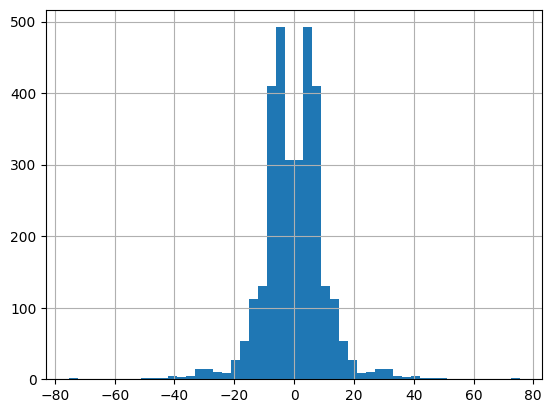

In [42]:
skewness_df["skewness"].hist(bins=50)

In [43]:
# example_lines = (
#     skewness_df
#     .groupby('skew_class')
#     .first()
#     .reset_index()
# )

# for _, row in example_lines.iterrows():

#     line = row['line']
#     skew_val = row['skewness']
#     skew_class = row['skew_class']

#     subset = congestion_spread[
#         congestion_spread['line'] == line
#     ]

#     fig = px.histogram(
#         subset,
#         x='congestion_spread',
#         nbins=50,
#         marginal='box',
#         opacity=0.75,
#         title=(
#             f'Line: {line} | '
#             f'Skewness = {skew_val:.3f} | '
#             f'{skew_class}'
#         )
#     )

#     fig.update_layout(
#         xaxis_title='Congestion Spread',
#         yaxis_title='Frequency',
#         template='plotly_white'
#     )

#     fig.show()

## heavy-tail vs light-tail

In [44]:
kurtosis_df = (
    congestion_spread
    .groupby('pair')['congestion_spread']
    .apply(lambda x: kurtosis(x.dropna(), fisher=True))
    .reset_index(name='kurtosis')
)


def classify_kurtosis(val, threshold=3):
    """
    Fisher kurtosis interpretation:
    
    kurtosis > threshold      -> leptokurtic (heavy tails)
    kurtosis < -threshold     -> platykurtic (light tails)
    otherwise                 -> mesokurtic (normal-like)
    """
    
    if val > 100:
        return 'outlier-dominated'
    elif val > 10:
        return 'heavy-tail'
    else:
        return 'moderate-tail'

kurtosis_df['kurtosis_class'] = (
    kurtosis_df['kurtosis']
    .apply(classify_kurtosis)
)

# View results
kurtosis_df.head()

,pair,kurtosis,kurtosis_class
0,1256-969,62.676133,heavy-tail
1,1291-969,62.458978,heavy-tail
2,13106-3270,45.405678,heavy-tail
3,13106-7075,39.354672,heavy-tail
4,13109-5454,56.843714,heavy-tail


In [45]:
kurtosis_df['kurtosis_class'].value_counts()

kurtosis_class
heavy-tail           1844
outlier-dominated    1312
moderate-tail          52
Name: count, dtype: int64

In [46]:
# example_lines = (
#     kurtosis_df
#     .groupby('kurtosis_class')
#     .first()
#     .reset_index()
# )

# for _, row in example_lines.iterrows():

#     line = row['line']
#     kurtosis_val = row['kurtosis']
#     kurtosis_class = row['kurtosis_class']

#     subset = congestion_spread[
#         congestion_spread['line'] == line
#     ]

#     fig = px.histogram(
#         subset,
#         x='congestion_spread',
#         nbins=50,
#         marginal='box',
#         opacity=0.75,
#         title=(
#             f'Line: {line} | '
#             f'Kurtosis = {kurtosis_val:.3f} | '
#             f'{kurtosis_class}'
#         )
#     )

#     fig.update_layout(
#         xaxis_title='Congestion Spread',
#         yaxis_title='Frequency',
#         template='plotly_white'
#     )

#     fig.show()

## CVaR/ES

In [47]:
def compute_cvar(x, alpha):

    x = pd.Series(x).dropna()

    if len(x) == 0:
        return np.nan

    # downside tail
    if alpha < 0.5:
        var = np.quantile(x, alpha)
        return x[x <= var].mean()

    # upside tail
    else:
        var = np.quantile(x, alpha)
        return x[x >= var].mean()


cvar_df = (
    congestion_spread
    .groupby("pair")["congestion_spread"]
    .apply(lambda x: pd.Series({
        "CVaR_01": compute_cvar(x, 0.01),
        "CVaR_99": compute_cvar(x, 0.99)
    }))
    .unstack()
    .reset_index()
)

# combined tail risk
cvar_df["CVaR"] = (
    cvar_df["CVaR_01"].abs()
    # + cvar_df["CVaR_98"].abs()
)

cvar_df.head()

,pair,CVaR_01,CVaR_99,CVaR
0,1256-969,-154.164563,6.846666,154.164563
1,1291-969,-200.519299,4.950351,200.519299
2,13106-3270,-155.080351,0.007104,155.080351
3,13106-7075,-19.664912,6.820526,19.664912
4,13109-5454,-183.515089,15.102456,183.515089


In [48]:
cvar_df['risk_class'] = pd.qcut(
    cvar_df['CVaR'],
    q=3,
    labels=[
        'low CVaR',
        'high CVaR',
        'extreme CVaR'
    ]
)

cvar_df.head()

,pair,CVaR_01,CVaR_99,CVaR,risk_class
0,1256-969,-154.164563,6.846666,154.164563,extreme CVaR
1,1291-969,-200.519299,4.950351,200.519299,extreme CVaR
2,13106-3270,-155.080351,0.007104,155.080351,extreme CVaR
3,13106-7075,-19.664912,6.820526,19.664912,high CVaR
4,13109-5454,-183.515089,15.102456,183.515089,extreme CVaR


In [49]:
# example_lines = (
#     cvar_df
#     .groupby('risk_class')
#     .first()
#     .reset_index()
# )

# for _, row in example_lines.iterrows():

#     line = row['line']
#     cvar_val = row['CVaR_95']
#     risk_class = row['risk_class']

#     subset = congestion_spread[
#         congestion_spread['line'] == line
#     ]

#     fig = px.histogram(
#         subset,
#         x='congestion_spread',
#         nbins=50,
#         marginal='box',
#         opacity=0.75,
#         title=(
#             f'Line: {line} | '
#             f'CVaR = {cvar_val:.3f} | '
#             f'{risk_class}'
#         )
#     )

#     fig.update_layout(
#         xaxis_title='Congestion Spread',
#         yaxis_title='Frequency',
#         template='plotly_white'
#     )

#     fig.show()

# Periodicity

In [50]:
congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


## FFT

In [51]:
def find_period_fft(ts, sampling_hours=1, plot=True):
    """
    ts: pandas Series indexed by time
    sampling_hours: spacing between samples
    """

    y = ts.values

    # remove mean
    y = y - np.mean(y)

    n = len(y)

    # FFT
    yf = fft(y)
    xf = fftfreq(n, d=sampling_hours)

    # positive frequencies only
    pos_mask = xf > 0
    xf = xf[pos_mask]
    power = np.abs(yf[pos_mask])

    # dominant frequency
    dominant_freq = xf[np.argmax(power)]

    # convert frequency -> period
    dominant_period = 1 / dominant_freq

    return dominant_period

In [52]:
period_results = {}

for pair, g in congestion_spread.groupby('pair'):

    ts = g.set_index('date')['congestion_spread']

    period = find_period_fft(ts, sampling_hours=1, plot=False)

    period_results[pair] = period

period_df = pd.DataFrame.from_dict(
    period_results,
    orient='index',
    columns=['dominant_period_hours']
)

period_df.index.name = 'pair'

period_df = period_df.reset_index()

period_df.head()

,pair,dominant_period_hours
0,1256-969,5688.0
1,1291-969,5688.0
2,13106-3270,5688.0
3,13106-7075,24.0
4,13109-5454,5688.0


In [53]:
# # plotly
# fig = px.histogram(
#     period_df,
#     x='dominant_period_hours',
#     nbins=500,
#     marginal='box',
#     opacity=0.75,
#     title='Distribution of Dominant Period (hours)'
# )

# fig.update_layout(
#     xaxis_title='Dominant Period (hours)',
#     yaxis_title='Frequency',
#     template='plotly_white'
# )

# fig.show()


In [54]:
def classify_period(period):

    if 22 <= period <= 26:
        return 'daily'

    elif 164 <= period <= 172:
        return 'weekly'

    else:
        return 'not_periodic'
    
period_df['periodicity'] = (
    period_df['dominant_period_hours']
    .apply(classify_period)
)

period_df.head()

,pair,dominant_period_hours,periodicity
0,1256-969,5688.0,not_periodic
1,1291-969,5688.0,not_periodic
2,13106-3270,5688.0,not_periodic
3,13106-7075,24.0,daily
4,13109-5454,5688.0,not_periodic


In [55]:
period_df["periodicity"].value_counts()

periodicity
not_periodic    2794
daily            414
Name: count, dtype: int64

In [56]:
# example_pairs = (
#     period_df
#     .groupby('periodicity')
#     .first()
#     .reset_index()
# )

# for _, row in example_pairs.iterrows():

#     pair = row['pair']
#     dom_period = row['dominant_period_hours']
#     periodicity = row['periodicity']

#     subset = congestion_spread[
#         congestion_spread['pair'] == pair
#     ]

#     fig = px.line(
#         subset,
#         x='date',
#         y='congestion_spread',
#         title=(
#             f'Pair: {pair} | '
#             f'Dominant Period = {dom_period:.3f} hours | '
#             f'{periodicity}'
#         )
#     )

#     fig.update_layout(
#         xaxis_title='Time',
#         yaxis_title='Congestion Spread',
#         template='plotly_white'
#     )

#     fig.show()

## ACF

In [57]:
def detect_period_acf(
    series,
    nlags=24*7,      # check up to 2 weeks for hourly data
    min_acf=0.5       # minimum peak height
):
    """
    Detect candidate periods using ACF peaks.
    """

    # remove NaNs
    series = series.dropna()

    # compute ACF
    acf_values = acf(series, nlags=nlags, fft=True)

    # ignore lag 0
    lags = np.arange(len(acf_values))[1:]
    acf_no0 = acf_values[1:]

    # find peaks
    peaks, props = find_peaks(acf_no0, height=min_acf)

    candidate_periods = lags[peaks]
    peak_strengths = props['peak_heights']

    return acf_values, candidate_periods, peak_strengths

In [58]:
results = {}

for pair, group in congestion_spread.groupby("pair"):

    ts = (
        group.sort_values("date")
             .set_index("date")["congestion_spread"]
    )

    acf_vals, periods, strengths = detect_period_acf(ts)

    results[pair] = {
        "periods": periods,
        "strengths": strengths,
        "acf": acf_vals
    }


In [59]:

# # collect ACF at lag 24 for each pair
# lag = 24

# acf_lag24 = {
#     pair: res["acf"][lag]
#     for pair, res in results.items()
#     if len(res["acf"]) > lag
# }

# # dataframe
# acf_df = pd.DataFrame({
#     "pair": list(acf_lag24.keys()),
#     "acf_lag24": list(acf_lag24.values())
# })

# # histogram distribution
# fig = px.histogram(
#     acf_df,
#     x="acf_lag24",
#     nbins=100,
#     title="Distribution of ACF at Lag 24 Across Pairs",
#     labels={"acf_lag24": "ACF Value at Lag 24"},
#     marginal="box"   # optional: adds boxplot on top
# )

# fig.show()

In [60]:
classification = {
    "daily": [],
    "weekly": [],
    "no_period": []
}

daily_lag = 24
weekly_lag = 168

tolerance_daily = 0      # allow 24 hours
tolerance_weekly = 0     # allow 168 hours

for pair, res in results.items():
    periods = res["periods"]
    strengths = res["strengths"]

    has_daily = np.any(
        (periods >= daily_lag - tolerance_daily) &
        (periods <= daily_lag + tolerance_daily)
    )

    has_weekly = np.any(
        (periods >= weekly_lag - tolerance_weekly) &
        (periods <= weekly_lag + tolerance_weekly)
    )

    if has_daily:
        classification["daily"].append(pair)
    elif has_weekly:
        classification["weekly"].append(pair)
    else:
        classification["no_period"].append(pair)

In [61]:
pair_period_class = []

for cls, pairs in classification.items():
    for pair in pairs:
        pair_period_class.append({
            "pair": pair,
            "period_class": cls
        })

pair_period_class = pd.DataFrame(pair_period_class)

pair_period_class.head()

,pair,period_class
0,1256-969,daily
1,1291-969,daily
2,13106-3270,daily
3,13106-7075,daily
4,13109-5454,daily


In [62]:
pair_period_class['period_class'].value_counts()

period_class
no_period    2486
daily         722
Name: count, dtype: int64

In [63]:
# # Select line
# selected_line = '26681-321368'

# # Filter data
# line_df = (
#     congestion_spread[
#         congestion_spread['pair'] == selected_line
#     ]
#     .sort_values('date')
# )

# fig = px.line(
#     line_df,
#     x='date',
#     y='congestion_spread',
#     title=f'Congestion Spread Over Time: {selected_line}',
#     markers=True
# )

# fig.update_layout(
#     xaxis_title='Date',
#     yaxis_title='Congestion Spread',
#     hovermode='x unified'
# )

# fig.show()

In [64]:
# # thresholds from line_volatility
# max_threshold = line_volatility["max"].quantile(0.5)
# min_threshold = line_volatility["min"].quantile(0.5)

single_peak_pairs = []
multi_peak_pairs = []

for pair in classification["no_period"]:

    ts = (
        congestion_spread.loc[
            congestion_spread["pair"] == pair
        ]
        .sort_values("date")["congestion_spread"]
        .dropna()
    )
    
    # # filter condition:
    # # require sufficiently large positive and negative excursions
    # if (
    #     ts.max() <= max_threshold
    #     or ts.min() >= min_threshold
    # ):
    #     continue

    # optional normalization
    ts_std = (ts - ts.mean()) / ts.std()

    # detect peaks
    peaks, props = find_peaks(
        ts_std,
        prominence=3,     # important tuning parameter
        distance=24       # avoid nearby duplicate peaks
    )

    n_peaks = len(peaks)

    if n_peaks <= 5:
        single_peak_pairs.append(pair)
    else:
        multi_peak_pairs.append(pair)

In [65]:
print("Peaky pairs:", len(single_peak_pairs))
print("Multi-peak no-period pairs:", len(multi_peak_pairs))

Peaky pairs: 99
Multi-peak no-period pairs: 2387


In [66]:
pair_period_class.loc[
    pair_period_class["pair"].isin(single_peak_pairs),
    "period_class"
] = "peaky"

pair_period_class["period_class"].value_counts()

period_class
no_period    2387
daily         722
peaky          99
Name: count, dtype: int64

In [67]:
# example_lines = (
#     pair_period_class
#     .groupby('period_class')
#     .first()
#     .reset_index()
# )

# for _, row in example_lines.iterrows():

#     pair = row['pair']
#     periodicity = row['period_class']

#     subset = congestion_spread[
#         congestion_spread['pair'] == pair
#     ]

#     fig = px.line(
#         subset,
#         x='date',
#         y='congestion_spread',
#         title=(
#             f'Pair: {pair} | '
#             f'Period Class = {periodicity} '
#         )
#     )

#     fig.update_layout(
#         xaxis_title='Time',
#         yaxis_title='Congestion Spread',
#         template='plotly_white'
#     )

#     fig.show()

## periodic average

In [68]:
congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


In [69]:
congestion_spread['date'] = pd.to_datetime(congestion_spread['date'])

### hourly

In [70]:
hourly_line_mean = (
    congestion_spread
    .assign(hour=congestion_spread["date"].dt.hour)
    .groupby(
        [
            "pair",
            "hour",
            "nodekey1",
            "nodekey2",
            "nodename1",
            "nodename2",
        ],
        as_index=False
    )["congestion_spread"]
    .mean()
    .rename(columns={"congestion_spread": "mean_congestion_spread"})
)

hourly_line_mean.head()

,pair,hour,nodekey1,nodekey2,nodename1,nodename2,mean_congestion_spread
0,1256-969,0,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,-0.577269
1,1256-969,1,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,-0.256582
2,1256-969,2,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,-0.069367
3,1256-969,3,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,-0.008559
4,1256-969,4,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,-0.005359


In [71]:
# selected_line = "13300-323655"

# line_hourly_band = (
#     congestion_spread
#     .assign(hour=congestion_spread["date"].dt.hour)
#     .query("pair == @selected_line")
#     .groupby("hour")["congestion_spread"]
#     .agg(
#         mean="mean",
#         std="std",
#         p10=lambda x: x.quantile(0.10),
#         p25=lambda x: x.quantile(0.25),
#         median="median",
#         p75=lambda x: x.quantile(0.75),
#         p90=lambda x: x.quantile(0.90),
#     )
#     .reset_index()
# )

# fig = go.Figure()

# # Outer percentile band: P10-P90
# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["p90"],
#     mode="lines",
#     line=dict(width=0),
#     showlegend=False,
#     hoverinfo="skip"
# ))

# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["p10"],
#     mode="lines",
#     fill="tonexty",
#     fillcolor="rgba(174, 198, 207, 0.28)",  # soft blue-gray
#     line=dict(width=0),
#     name="P10-P90 range",
#     hovertemplate="P10: %{y:.2f}<extra></extra>"
# ))

# # Inner percentile band: P25-P75
# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["p75"],
#     mode="lines",
#     line=dict(width=0),
#     showlegend=False,
#     hoverinfo="skip"
# ))

# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["p25"],
#     mode="lines",
#     fill="tonexty",
#     fillcolor="rgba(244, 194, 194, 0.38)",  # soft rose
#     line=dict(width=0),
#     name="P25-P75 range",
#     hovertemplate="P25: %{y:.2f}<extra></extra>"
# ))

# # Mean ± 1 std, lightly shown
# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["mean"] + line_hourly_band["std"],
#     mode="lines",
#     line=dict(color="rgba(120, 120, 120, 0.45)", width=1.5, dash="dot"),
#     name="Mean + 1 std"
# ))

# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["mean"] - line_hourly_band["std"],
#     mode="lines",
#     line=dict(color="rgba(120, 120, 120, 0.45)", width=1.5, dash="dot"),
#     name="Mean - 1 std"
# ))

# # Mean line
# fig.add_trace(go.Scatter(
#     x=line_hourly_band["hour"],
#     y=line_hourly_band["mean"],
#     mode="lines+markers",
#     line=dict(color="#C77D7D", width=2.5),
#     marker=dict(size=6, color="#C77D7D"),
#     name="Mean"
# ))

# fig.update_layout(
#     title=dict(
#         text=f"Line {selected_line} Hourly Congestion Spread Distribution",
#         x=0.5,
#         font=dict(size=20)
#     ),
#     xaxis=dict(
#         title="Hour of Day",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.45)",
#         zeroline=False
#     ),
#     yaxis=dict(
#         title="Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.45)",
#         zeroline=True,
#         zerolinecolor="rgba(120,120,120,0.35)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     margin=dict(l=60, r=40, t=90, b=60),
#     width=800,
#     height=500
# )

# fig.show()

In [72]:
# # reproducible random sample
# np.random.seed(7)

# # pick 10 random lines
# random_lines = np.random.choice(
#     hourly_line_mean["line"].unique(),
#     size=10,
#     replace=False
# )

# sample_df = hourly_line_mean[
#     hourly_line_mean["line"].isin(random_lines)
# ]

# fig = go.Figure()

# soft_colors = [
#     "#6B8E9E", "#C77D7D", "#8FAF88", "#B39BC8", "#D9A66B",
#     "#7AA6C2", "#C28F8F", "#A3BE8C", "#B48EAD", "#D8B26E"
# ]

# for i, line in enumerate(random_lines):

#     line_df = (
#         sample_df[sample_df["line"] == line]
#         .sort_values("hour")
#     )

#     fig.add_trace(
#         go.Scatter(
#             x=line_df["hour"],
#             y=line_df["mean_congestion_spread"],
#             mode="lines",
#             name=line,
#             line=dict(
#                 width=2.5,
#                 color=soft_colors[i]
#             ),
#             opacity=0.85
#         )
#     )

# fig.update_layout(
#     title=dict(
#         text="Hourly Mean Congestion Spread — Random 10 Lines",
#         x=0.5,
#         font=dict(size=22)
#     ),
#     xaxis=dict(
#         title="Hour of Day",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)"
#     ),
#     yaxis=dict(
#         title="Mean Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)",
#         zeroline=True,
#         zerolinecolor="rgba(150,150,150,0.3)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     width=1500,
#     height=800,
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     margin=dict(l=60, r=40, t=90, b=60)
# )

# fig.show()

In [73]:
filtered_hourly_line_mean = (
    hourly_line_mean
    .assign(
        spread_range=lambda df: (
            df.groupby("pair")["mean_congestion_spread"]
              .transform(lambda x: x.max() - x.min())
        )
    )
    .sort_values("spread_range", ascending=False)
)

# keep only top 10 lines by range
top_10_lines = (
    filtered_hourly_line_mean[["pair", "spread_range"]]
    .drop_duplicates()
    .nlargest(10, "spread_range")["pair"]
)

filtered_hourly_line_mean = filtered_hourly_line_mean[
    filtered_hourly_line_mean["pair"].isin(top_10_lines)
]

filtered_hourly_line_mean.head()

,pair,hour,nodekey1,nodekey2,nodename1,nodename2,mean_congestion_spread,spread_range
920,1629-1788,8,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,-5.505696,119.757384
921,1629-1788,9,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,-4.703418,119.757384
922,1629-1788,10,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,-10.970338,119.757384
923,1629-1788,11,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,-20.187384,119.757384
924,1629-1788,12,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,-33.713924,119.757384


In [74]:
filtered_hourly_line_mean["pair"].nunique()

10

In [75]:
# # reproducible random sample
# np.random.seed(7)

# # pick 10 random lines
# random_lines = np.random.choice(
#     filtered_hourly_line_mean["pair"].unique(),
#     size=5,
#     replace=False
# )

# sample_df = filtered_hourly_line_mean[
#     filtered_hourly_line_mean["pair"].isin(random_lines)
# ]

# fig = go.Figure()

# soft_colors = [
#     "#6B8E9E", "#C77D7D", "#8FAF88", "#B39BC8", "#D9A66B",
#     "#7AA6C2", "#C28F8F", "#A3BE8C", "#B48EAD", "#D8B26E"
# ]

# for i, line in enumerate(random_lines):

#     line_df = (
#         sample_df[sample_df["pair"] == line]
#         .sort_values("hour")
#     )

#     fig.add_trace(
#         go.Scatter(
#             x=line_df["hour"],
#             y=line_df["mean_congestion_spread"],
#             mode="lines",
#             name=line,
#             line=dict(
#                 width=2.5,
#                 color=soft_colors[i]
#             ),
#             opacity=0.85
#         )
#     )

# fig.update_layout(
#     title=dict(
#         text="Hourly Mean Congestion Spread — Random 10 Lines",
#         x=0.5,
#         font=dict(size=22)
#     ),
#     xaxis=dict(
#         title="Hour of Day",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)"
#     ),
#     yaxis=dict(
#         title="Mean Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)",
#         zeroline=True,
#         zerolinecolor="rgba(150,150,150,0.3)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     width=1500,
#     height=800,
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     margin=dict(l=60, r=40, t=90, b=60)
# )

# fig.show()

### daily

In [76]:
dow_line_mean = (
    congestion_spread
    .assign(day_of_week=congestion_spread["date"].dt.day_name())
    .groupby(
        [
            "pair",
            "nodekey1",
            "nodekey2",
            "nodename1",
            "nodename2",
            "day_of_week",
        ],
        as_index=False,
    )["congestion_spread"]
    .mean()
    .rename(columns={"congestion_spread": "mean_congestion_spread"})
)

# optional: sort weekday order
weekday_order = [
    "Monday", "Tuesday", "Wednesday",
    "Thursday", "Friday", "Saturday", "Sunday"
]

dow_line_mean["day_of_week"] = pd.Categorical(
    dow_line_mean["day_of_week"],
    categories=weekday_order,
    ordered=True,
)

dow_line_mean = dow_line_mean.sort_values(
    ["pair", "day_of_week"]
)

dow_line_mean.head()

,pair,nodekey1,nodekey2,nodename1,nodename2,day_of_week,mean_congestion_spread
1,1256-969,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,Monday,-5.275723
5,1256-969,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,Tuesday,-6.257659
6,1256-969,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,Wednesday,-4.094645
4,1256-969,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,Thursday,-4.698640
0,1256-969,1256,969,72 GOOSE34.5 KV L7280,433 CHAN138 KV TR71 12,Friday,-2.440556


In [77]:
# selected_line = "1082-1098"

# weekday_order = [
#     "Monday",
#     "Tuesday",
#     "Wednesday",
#     "Thursday",
#     "Friday",
#     "Saturday",
#     "Sunday",
# ]

# dow_hourly_band = (
#     congestion_spread
#     .assign(
#         day_of_week=lambda df: pd.Categorical(
#             df["date"].dt.day_name(),
#             categories=weekday_order,
#             ordered=True,
#         )
#     )
#     .query("line == @selected_line")
#     .groupby("day_of_week", observed=True)["congestion_spread"]
#     .agg(
#         mean="mean",
#         std="std",
#         p10=lambda x: x.quantile(0.10),
#         p25=lambda x: x.quantile(0.25),
#         median="median",
#         p75=lambda x: x.quantile(0.75),
#         p90=lambda x: x.quantile(0.90),
#     )
#     .reset_index()
#     .sort_values("day_of_week")
# )

# fig = go.Figure()

# # Outer percentile band: P10-P90
# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["p90"],
#     mode="lines",
#     line=dict(width=0),
#     showlegend=False,
#     hoverinfo="skip"
# ))

# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["p10"],
#     mode="lines",
#     fill="tonexty",
#     fillcolor="rgba(174, 198, 207, 0.28)",  # soft blue-gray
#     line=dict(width=0),
#     name="P10-P90 range",
#     hovertemplate="P10: %{y:.2f}<extra></extra>"
# ))

# # Inner percentile band: P25-P75
# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["p75"],
#     mode="lines",
#     line=dict(width=0),
#     showlegend=False,
#     hoverinfo="skip"
# ))

# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["p25"],
#     mode="lines",
#     fill="tonexty",
#     fillcolor="rgba(244, 194, 194, 0.38)",  # soft rose
#     line=dict(width=0),
#     name="P25-P75 range",
#     hovertemplate="P25: %{y:.2f}<extra></extra>"
# ))

# # Mean ± 1 std, lightly shown
# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["mean"] + dow_hourly_band["std"],
#     mode="lines",
#     line=dict(color="rgba(120, 120, 120, 0.45)", width=1.5, dash="dot"),
#     name="Mean + 1 std"
# ))

# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["mean"] - dow_hourly_band["std"],
#     mode="lines",
#     line=dict(color="rgba(120, 120, 120, 0.45)", width=1.5, dash="dot"),
#     name="Mean - 1 std"
# ))

# # Mean line
# fig.add_trace(go.Scatter(
#     x=dow_hourly_band["day_of_week"],
#     y=dow_hourly_band["mean"],
#     mode="lines+markers",
#     line=dict(color="#C77D7D", width=2.5),
#     marker=dict(size=6, color="#C77D7D"),
#     name="Mean"
# ))

# fig.update_layout(
#     title=dict(
#         text=f"Line {selected_line} Day of Week Congestion Spread Distribution",
#         x=0.5,
#         font=dict(size=20)
#     ),
#     xaxis=dict(
#         title="Day of Week",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.45)",
#         zeroline=False
#     ),
#     yaxis=dict(
#         title="Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.45)",
#         zeroline=True,
#         zerolinecolor="rgba(120,120,120,0.35)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     margin=dict(l=60, r=40, t=90, b=60),
#     width=950,
#     height=560
# )

# fig.show()

In [78]:
# # reproducible random sample
# np.random.seed(7)

# # pick 10 random lines
# random_lines = np.random.choice(
#     dow_line_mean["line"].unique(),
#     size=10,
#     replace=False
# )

# sample_df = dow_line_mean[
#     dow_line_mean["line"].isin(random_lines)
# ]

# fig = go.Figure()

# soft_colors = [
#     "#6B8E9E", "#C77D7D", "#8FAF88", "#B39BC8", "#D9A66B",
#     "#7AA6C2", "#C28F8F", "#A3BE8C", "#B48EAD", "#D8B26E"
# ]

# for i, line in enumerate(random_lines):

#     line_df = (
#         sample_df[sample_df["line"] == line]
#         .sort_values("day_of_week")
#     )

#     fig.add_trace(
#         go.Scatter(
#             x=line_df["day_of_week"],
#             y=line_df["mean_congestion_spread"],
#             mode="lines",
#             name=line,
#             line=dict(
#                 width=2.5,
#                 color=soft_colors[i]
#             ),
#             opacity=0.85
#         )
#     )

# fig.update_layout(
#     title=dict(
#         text="Day of Week Mean Congestion Spread — Random 10 Lines",
#         x=0.5,
#         font=dict(size=22)
#     ),
#     xaxis=dict(
#         title="Day of Week",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)"
#     ),
#     yaxis=dict(
#         title="Mean Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)",
#         zeroline=True,
#         zerolinecolor="rgba(150,150,150,0.3)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     width=1500,
#     height=600,
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     margin=dict(l=60, r=40, t=90, b=60)
# )

# fig.show()

In [79]:
filtered_dow_line_mean = (
    dow_line_mean
    .assign(
        spread_range=lambda df: (
            df.groupby("pair")["mean_congestion_spread"]
              .transform(lambda x: x.max() - x.min())
        )
    )
    .sort_values("spread_range", ascending=False)
)

# keep only top 10 lines by range
top_10_lines = (
    filtered_dow_line_mean[["pair", "spread_range"]]
    .drop_duplicates()
    .nlargest(10, "spread_range")["pair"]
)

filtered_dow_line_mean = filtered_dow_line_mean[
    filtered_dow_line_mean["pair"].isin(top_10_lines)
]

filtered_dow_line_mean.head()

,pair,nodekey1,nodekey2,nodename1,nodename2,day_of_week,mean_congestion_spread,spread_range
781,1788-1629,1788,1629,BECO 35 KV TX1,AQUEDUCT35 KV T1,Thursday,53.082721,35.588333
778,1788-1629,1788,1629,BECO 35 KV TX1,AQUEDUCT35 KV T1,Monday,44.127206,35.588333
267,1629-1788,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,Monday,-44.127206,35.588333
268,1629-1788,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1,Saturday,-18.433260,35.588333
782,1788-1629,1788,1629,BECO 35 KV TX1,AQUEDUCT35 KV T1,Tuesday,49.883517,35.588333


In [80]:
# # reproducible random sample
# np.random.seed(7)

# # pick 10 random lines
# random_lines = np.random.choice(
#     filtered_dow_line_mean["pair"].unique(),
#     size=5,
#     replace=False
# )

# sample_df = filtered_dow_line_mean[
#     filtered_dow_line_mean["pair"].isin(random_lines)
# ]

# fig = go.Figure()

# soft_colors = [
#     "#6B8E9E", "#C77D7D", "#8FAF88", "#B39BC8", "#D9A66B",
#     "#7AA6C2", "#C28F8F", "#A3BE8C", "#B48EAD", "#D8B26E"
# ]

# for i, pair in enumerate(random_lines):

#     line_df = (
#         sample_df[sample_df["pair"] == pair]
#         .sort_values("day_of_week")
#     )

#     fig.add_trace(
#         go.Scatter(
#             x=line_df["day_of_week"],
#             y=line_df["mean_congestion_spread"],
#             mode="lines",
#             name=pair,
#             line=dict(
#                 width=2.5,
#                 color=soft_colors[i]
#             ),
#             opacity=0.85
#         )
#     )

# fig.update_layout(
#     title=dict(
#         text="Hourly Mean Congestion Spread — Random 10 Lines",
#         x=0.5,
#         font=dict(size=22)
#     ),
#     xaxis=dict(
#         title="Hour of Day",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)"
#     ),
#     yaxis=dict(
#         title="Mean Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)",
#         zeroline=True,
#         zerolinecolor="rgba(150,150,150,0.3)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     width=1500,
#     height=800,
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     margin=dict(l=60, r=40, t=90, b=60)
# )

# fig.show()

In [81]:
weekend_days = ["Saturday", "Sunday"]

# add abs value column
filtered_dow_line_mean = (
    dow_line_mean
    .assign(
        abs_mean_congestion_spread=lambda df: df["mean_congestion_spread"].abs()
    )
)

# find the row with max abs spread for each pair
max_rows = (
    filtered_dow_line_mean
    .loc[
        filtered_dow_line_mean.groupby("pair")[
            "abs_mean_congestion_spread"
        ].idxmax()
    ]
)

# keep only pairs whose max occurs on weekend
top_weekend_pairs = (
    max_rows
    .loc[max_rows["day_of_week"].isin(weekend_days)]
    .sort_values("abs_mean_congestion_spread", ascending=False)
    .head(10)["pair"]
)

# filter original dataframe
filtered_dow_line_mean = (
    filtered_dow_line_mean
    .loc[filtered_dow_line_mean["pair"].isin(top_weekend_pairs)]
    .sort_values(["pair", "day_of_week"])
)

filtered_dow_line_mean.head()

,pair,nodekey1,nodekey2,nodename1,nodename2,day_of_week,mean_congestion_spread,abs_mean_congestion_spread
127,1439-1443,1439,1443,945 CRET13.5 KV CT-1,946 UNIV13.5 KV UP31-1,Monday,3.104767,3.104767
131,1439-1443,1439,1443,945 CRET13.5 KV CT-1,946 UNIV13.5 KV UP31-1,Tuesday,1.460037,1.460037
132,1439-1443,1439,1443,945 CRET13.5 KV CT-1,946 UNIV13.5 KV UP31-1,Wednesday,3.702512,3.702512
130,1439-1443,1439,1443,945 CRET13.5 KV CT-1,946 UNIV13.5 KV UP31-1,Thursday,1.573076,1.573076
126,1439-1443,1439,1443,945 CRET13.5 KV CT-1,946 UNIV13.5 KV UP31-1,Friday,2.112980,2.112980


In [82]:
# # reproducible random sample
# np.random.seed(7)

# # pick 10 random lines
# random_lines = np.random.choice(
#     filtered_dow_line_mean["pair"].unique(),
#     size=10,
#     replace=False
# )

# sample_df = filtered_dow_line_mean[
#     filtered_dow_line_mean["pair"].isin(random_lines)
# ]

# fig = go.Figure()

# soft_colors = [
#     "#6B8E9E", "#C77D7D", "#8FAF88", "#B39BC8", "#D9A66B",
#     "#7AA6C2", "#C28F8F", "#A3BE8C", "#B48EAD", "#D8B26E"
# ]

# for i, pair in enumerate(random_lines):

#     line_df = (
#         sample_df[sample_df["pair"] == pair]
#         .sort_values("day_of_week")
#     )

#     fig.add_trace(
#         go.Scatter(
#             x=line_df["day_of_week"],
#             y=line_df["mean_congestion_spread"],
#             mode="lines",
#             name=pair,
#             line=dict(
#                 width=2.5,
#                 color=soft_colors[i]
#             ),
#             opacity=0.85
#         )
#     )

# fig.update_layout(
#     title=dict(
#         text="Hourly Mean Congestion Spread — Random 10 Lines",
#         x=0.5,
#         font=dict(size=22)
#     ),
#     xaxis=dict(
#         title="Hour of Day",
#         tickmode="linear",
#         dtick=1,
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)"
#     ),
#     yaxis=dict(
#         title="Mean Congestion Spread",
#         showgrid=True,
#         gridcolor="rgba(220,220,220,0.4)",
#         zeroline=True,
#         zerolinecolor="rgba(150,150,150,0.3)"
#     ),
#     template="plotly_white",
#     hovermode="x unified",
#     width=1500,
#     height=800,
#     plot_bgcolor="rgba(250,250,248,1)",
#     paper_bgcolor="rgba(250,250,248,1)",
#     legend=dict(
#         orientation="h",
#         yanchor="bottom",
#         y=1.02,
#         xanchor="center",
#         x=0.5
#     ),
#     margin=dict(l=60, r=40, t=90, b=60)
# )

# fig.show()

# line char

In [83]:
line_char = line_volatility[["pair", "category"]].merge(skewness_df[["pair", "skew_class"]], on="pair").merge(cvar_df[["pair", "risk_class"]], on="pair").merge(pair_period_class, on="pair")

line_char.head()

,pair,category,skew_class,risk_class,period_class
0,1629-1788,negative-unilateral extreme,left-skewed,extreme CVaR,no_period
1,1788-1629,positive-unilateral extreme,right-skewed,high CVaR,no_period
2,6163-1788,negative-unilateral extreme,left-skewed,extreme CVaR,no_period
3,1788-6163,positive-unilateral extreme,right-skewed,high CVaR,no_period
4,322986-1821,positive-unilateral extreme,right-skewed,high CVaR,no_period


In [84]:
line_char["category"] = line_char["category"].replace({
    "negative-unilateral extreme": "negative unilateral extreme",
    "positive-unilateral extreme": "positive unilateral extreme"
})

line_char["skew_class"] = line_char["skew_class"].replace({
    "left-skewed": "skewed",
    "right-skewed": "skewed",
    "no-skewness": "balanced"
})

line_char["period_class"] = line_char["period_class"].replace({
    "no_period": "random"
})

In [85]:
line_char["pair"].nunique()

3208

In [86]:
# split line into nodekey1-nodekey2
line_map = (
    congestion_spread[
        ["pair", "nodekey1", "nodekey2", "nodename1", "nodename2"]
    ]
    .drop_duplicates("pair")
)

# merge into line_char
line_char = line_char.merge(
    line_map,
    on="pair",
    how="left"
)

line_char.head()

,pair,category,skew_class,risk_class,period_class,nodekey1,nodekey2,nodename1,nodename2
0,1629-1788,negative unilateral extreme,skewed,extreme CVaR,random,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1
1,1788-1629,positive unilateral extreme,skewed,high CVaR,random,1788,1629,BECO 35 KV TX1,AQUEDUCT35 KV T1
2,6163-1788,negative unilateral extreme,skewed,extreme CVaR,random,6163,1788,QUINCEOR69 KV LD1,BECO 35 KV TX1
3,1788-6163,positive unilateral extreme,skewed,high CVaR,random,1788,6163,BECO 35 KV TX1,QUINCEOR69 KV LD1
4,322986-1821,positive unilateral extreme,skewed,high CVaR,random,322986,1821,PACIFIC 36.5 KV TX1LOAD,BELLSMIL34 KV LD1B


In [87]:
# sankey
# cols = ["category", "skew_class", "risk_class", "period_class"]
cols = ["skew_class", "category", "risk_class", "period_class"]

df = line_char.copy()

# build node list
all_nodes = pd.unique(df[cols].values.ravel())
node_map = {v:i for i,v in enumerate(all_nodes)}

links = []

for c1, c2 in zip(cols[:-1], cols[1:]):

    temp = (
        df.groupby([c1, c2])
        .size()
        .reset_index(name="count")
    )

    for _, row in temp.iterrows():
        links.append({
            "source": node_map[row[c1]],
            "target": node_map[row[c2]],
            "value": row["count"]
        })

fig = go.Figure(go.Sankey(
    node=dict(
        label=list(all_nodes),
        pad=15,
        thickness=15
    ),
    link=dict(
        source=[x["source"] for x in links],
        target=[x["target"] for x in links],
        value=[x["value"] for x in links]
    )
))

fig.update_layout(
    title="Relationship Between Classification Systems",
    height=800
)

# fig.show()

# fig.write_html("graph/pair_congestion_spread/sankey_diagram_by_class.html")

In [88]:

# category_order = sorted(line_char["category"].dropna().unique())
# risk_order = sorted(line_char["risk_class"].dropna().unique())
# skew_order = sorted(line_char["skew_class"].dropna().unique())
# period_order = sorted(line_char["period_class"].dropna().unique())

category_order = [
    "bilateral extreme",
    "positive unilateral extreme",
    "negative unilateral extreme",
    "neutral",
]

risk_order = [
    "extreme CVaR",
    "high CVaR",
    "low CVaR",
]

skew_order = [
    "balanced",
    "skewed"
]

period_order = [
    "daily",
    "random",
    "peaky",
]

# dimensions
outer_rows = len(category_order)      # 3
outer_cols = len(risk_order)          # 3
inner_rows = len(skew_order)          # 2
inner_cols = len(period_order)        # 3

rows = outer_rows * inner_rows        # 9
cols = outer_cols * inner_cols        # 6

subplot_titles = []
cell_meta = []

# ordering:
# outer = category x risk
# inner = skew x period
for category in category_order:
    for skew in skew_order:
        for risk in risk_order:
            for period in period_order:
                subplot_titles.append(" ")  # placeholder
                cell_meta.append((category, risk, skew, period))

fig = make_subplots(
    rows=rows,
    cols=cols,
    subplot_titles=subplot_titles,
    horizontal_spacing=0.01,
    vertical_spacing=0.06
)

# pick representative pair
for idx, (category, risk, skew, period) in enumerate(cell_meta):

    row = idx // cols + 1
    col = idx % cols + 1

    subset_pairs = line_char.loc[
        (line_char["category"] == category) &
        (line_char["risk_class"] == risk) &
        (line_char["skew_class"] == skew) &
        (line_char["period_class"] == period),
        "pair"
    ].unique()

    cs = congestion_spread[
        congestion_spread["pair"].isin(subset_pairs)
    ].copy()

    if cs.empty:
        continue

    pair_stats = (
        cs.groupby("pair")["congestion_spread"]
        .agg(
            mean_abs=lambda x: x.abs().mean(),
            std="std",
            count="count"
        )
        .dropna()
    )

    if pair_stats.empty:
        continue

    # choose representative pair
    pair_stats["score"] = (
        (pair_stats["mean_abs"] - pair_stats["mean_abs"].median()).abs()
        + (pair_stats["std"] - pair_stats["std"].median()).abs()
    )

    typical_pair = (
        pair_stats
        .sort_values(["score", "count"], ascending=[True, False])
        .index[0]
    )

    pair_df = (
        congestion_spread[
            congestion_spread["pair"] == typical_pair
        ]
        .sort_values("date")
    )

    pair_info = line_char.loc[
        line_char["pair"] == typical_pair,
        ["nodekey1", "nodename1", "nodekey2", "nodename2"]
    ].drop_duplicates().iloc[0]

    pair_label = (
        f"{pair_info['nodekey1']} {pair_info['nodename1']} - "
        f"{pair_info['nodekey2']} {pair_info['nodename2']}"
    )

    fig.layout.annotations[idx].text = (
        f"{category} | {risk}<br>"
        f"{skew} | {period}<br>"
        f"{pair_label}"
    )

    ########################################
    max_dt = pair_df["date"].max()

    # 2026.3.1 -> max datetime, unchanged
    pair_2026 = pair_df[
        pair_df["date"].between(
            pd.Timestamp(today.year, today.month - 2, 1),  # 2026-03-01 if today is 2026-05-22
            max_dt
        )
    ].copy()

    pair_2026["plot_date"] = pair_2026["date"]

    # 2025.5.1 -> 2025.7.31, shifted forward by 1 year for display
    pair_2025 = pair_df[
        pair_df["date"].between(
            pd.Timestamp(today.year - 1, today.month - 2, 1),
            pd.Timestamp(today.year - 1, today.month, 1) + pd.DateOffset(months=3) - pd.Timedelta(seconds=1)
        )
    ].copy()

    pair_2025["plot_date"] = pair_2025["date"] + pd.DateOffset(years=1)

    fig.add_trace(
        go.Scatter(
            x=pair_2026["plot_date"],
            y=pair_2026["congestion_spread"],
            mode="lines",
            line=dict(width=1.2),
            showlegend=False
        ),
        row=row,
        col=col
    )

    fig.add_trace(
        go.Scatter(
            x=pair_2025["plot_date"],
            y=pair_2025["congestion_spread"],
            mode="lines",
            line=dict(width=1.2, dash="dot"),
            showlegend=False
        ),
        row=row,
        col=col
    )
    # fig.add_trace(
    #     go.Scatter(
    #         x=pair_df["date"],
    #         y=pair_df["congestion_spread"],
    #         mode="lines",
    #         line=dict(width=1.2),
    #         showlegend=False
    #     ),
    #     row=row,
    #     col=col
    # )

# axis formatting
fig.update_annotations(
    font_size=10,              # smaller subplot titles
    yshift=2                  # push titles slightly upward
)

fig.update_xaxes(
    showgrid=False,
    title_text="",
    tickfont=dict(size=7),
    nticks=6                  # fewer x ticks
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=0.3,
    tickfont=dict(size=7),
    nticks=10
)

# add separators
# thin separators for 3x2 blocks
for r in range(1, rows):
    y = 1 - r / rows

    fig.add_shape(
        type="line",
        x0=0,
        x1=1,
        y0=y,
        y1=y,
        xref="paper",
        yref="paper",
        line=dict(color="rgba(120,120,120,0.35)", width=1)
    )

for c in range(1, cols):
    x = c / cols

    fig.add_shape(
        type="line",
        x0=x,
        x1=x,
        y0=0,
        y1=1,
        xref="paper",
        yref="paper",
        line=dict(color="rgba(120,120,120,0.35)", width=1)
    )

# thick separators for outer 3x3 groups
for r in range(inner_rows, rows, inner_rows):
    y = 1 - r / rows

    fig.add_shape(
        type="line",
        x0=0,
        x1=1,
        y0=y,
        y1=y,
        xref="paper",
        yref="paper",
        line=dict(color="black", width=3)
    )

for c in range(inner_cols, cols, inner_cols):
    x = c / cols

    fig.add_shape(
        type="line",
        x0=x,
        x1=x,
        y0=0,
        y1=1,
        xref="paper",
        yref="paper",
        line=dict(color="black", width=3)
    )

fig.update_layout(
    title="Typical Congestion Spread by Class Structure",
    template="plotly_white",
    height=360 * rows,
    width=450 * cols,
    margin=dict(t=200, l=200, r=30, b=30)
)

# fig.write_html("graph/pair_congestion_spread/congestion_spread_by_class_structure.html")

In [89]:
import json
from plotly.subplots import make_subplots

# --------------------------------------------------
# Orders
# --------------------------------------------------
category_order = [
    "bilateral extreme",
    "positive unilateral extreme",
    "negative unilateral extreme",
    "neutral",
]

risk_order = [
    "extreme CVaR",
    "high CVaR",
    "low CVaR",
]

skew_order = [
    "balanced",
    "skewed",
]

period_order = [
    "daily",
    "random",
    "peaky",
]

n_pairs = 3

today = pd.Timestamp.today()
# today = pd.Timestamp("2026-05-22")

congestion_spread = congestion_spread.copy()
line_char = line_char.copy()

congestion_spread["date"] = pd.to_datetime(congestion_spread["date"])
congestion_spread["pair"] = congestion_spread["pair"].astype(str)
line_char["pair"] = line_char["pair"].astype(str)


# --------------------------------------------------
# Random 3 pairs for selected class
# --------------------------------------------------
def get_random_pairs(category, risk, skew, period, n=3, random_state=None):

    subset_pairs = line_char.loc[
        (line_char["category"] == category) &
        (line_char["risk_class"] == risk) &
        (line_char["skew_class"] == skew) &
        (line_char["period_class"] == period),
        "pair"
    ].dropna().unique()

    cs = congestion_spread[
        congestion_spread["pair"].isin(subset_pairs)
    ].copy()

    if cs.empty:
        return []

    valid_pairs = (
        cs.groupby("pair")["congestion_spread"]
        .agg(count="count", std="std")
        .dropna()
        .index
        .tolist()
    )

    if len(valid_pairs) == 0:
        return []

    return (
        pd.Series(valid_pairs)
        .sample(
            n=min(n, len(valid_pairs)),
            replace=False,
            random_state=random_state
        )
        .tolist()
    )


# --------------------------------------------------
# Build all class combinations
# --------------------------------------------------
class_combos = []

for category in category_order:
    for risk in risk_order:
        for skew in skew_order:
            for period in period_order:
                class_combos.append((category, risk, skew, period))


# --------------------------------------------------
# Figure: 3 rows, each row one random pair
# --------------------------------------------------
fig = make_subplots(
    rows=n_pairs,
    cols=1,
    subplot_titles=[" "] * n_pairs,
    vertical_spacing=0.08
)

trace_lookup = {}
title_lookup = {}
annotation_lookup = {}

trace_idx = 0

default_key = (
    category_order[0],
    risk_order[0],
    skew_order[0],
    period_order[0],
)

for combo_idx, (category, risk, skew, period) in enumerate(class_combos):

    key = f"{category}||{risk}||{skew}||{period}"

    trace_lookup[key] = []
    annotation_lookup[key] = ["", "", ""]
    title_lookup[key] = (
        "Random Congestion Spread Pairs by Class Structure<br>"
        f"{category} | {risk} | {skew} | {period}"
    )

    random_pairs = get_random_pairs(
        category,
        risk,
        skew,
        period,
        n=n_pairs,
        random_state=combo_idx
    )

    visible = (category, risk, skew, period) == default_key

    for row_i, pair in enumerate(random_pairs):

        row = row_i + 1

        pair_df = (
            congestion_spread[
                congestion_spread["pair"] == pair
            ]
            .sort_values("date")
            .copy()
        )

        pair_info_df = (
            line_char.loc[
                line_char["pair"] == pair,
                ["nodekey1", "nodename1", "nodekey2", "nodename2"]
            ]
            .drop_duplicates()
        )

        if pair_info_df.empty:
            pair_label = str(pair)
        else:
            pair_info = pair_info_df.iloc[0]

            pair_label = (
                f"{pair_info['nodekey1']} {pair_info['nodename1']} - "
                f"{pair_info['nodekey2']} {pair_info['nodename2']}"
            )

        annotation_lookup[key][row_i] = (
            f"Random pair {row_i + 1}<br>{pair_label}"
        )

        max_dt = pair_df["date"].max()

        pair_recent = pair_df[
            pair_df["date"].between(
                pd.Timestamp(today.year, today.month - 2, 1),
                max_dt
            )
        ].copy()

        pair_recent["plot_date"] = pair_recent["date"]

        pair_prior = pair_df[
            pair_df["date"].between(
                pd.Timestamp(today.year - 1, today.month - 2, 1),
                pd.Timestamp(today.year - 1, today.month, 1)
                + pd.DateOffset(months=3)
                - pd.Timedelta(seconds=1)
            )
        ].copy()

        pair_prior["plot_date"] = pair_prior["date"] + pd.DateOffset(years=1)

        fig.add_trace(
            go.Scatter(
                x=pair_recent["plot_date"],
                y=pair_recent["congestion_spread"],
                mode="lines",
                name="Recent period",
                line=dict(width=1.4),
                visible=visible,
                legendgroup="recent",
                showlegend=(row_i == 0),
                hovertemplate=(
                    f"<b>{pair_label}</b><br>"
                    "Date: %{x}<br>"
                    "Spread: %{y:.2f}<extra>Recent</extra>"
                )
            ),
            row=row,
            col=1
        )

        trace_lookup[key].append(trace_idx)
        trace_idx += 1

        fig.add_trace(
            go.Scatter(
                x=pair_prior["plot_date"],
                y=pair_prior["congestion_spread"],
                mode="lines",
                name="Prior-year shifted",
                line=dict(width=1.4, dash="dot"),
                visible=visible,
                legendgroup="prior",
                showlegend=(row_i == 0),
                hovertemplate=(
                    f"<b>{pair_label}</b><br>"
                    "Shifted Date: %{x}<br>"
                    "Spread: %{y:.2f}<extra>Prior-year shifted</extra>"
                )
            ),
            row=row,
            col=1
        )

        trace_lookup[key].append(trace_idx)
        trace_idx += 1


# --------------------------------------------------
# Initial annotations
# --------------------------------------------------
default_key_str = "||".join(default_key)

annotation_y = [1.00, 0.64, 0.28]

initial_annotations = [
    dict(
        text=annotation_lookup[default_key_str][i],
        x=0.5,
        y=annotation_y[i],
        xref="paper",
        yref="paper",
        showarrow=False,
        font=dict(size=12),
        xanchor="center",
        yanchor="bottom"
    )
    for i in range(n_pairs)
]

fig.update_layout(annotations=initial_annotations)


# --------------------------------------------------
# Layout
# --------------------------------------------------
fig.update_layout(
    title="Random Congestion Spread Pairs by Class Structure",
    template="plotly_white",
    height=420 * n_pairs,
    width=1300,
    margin=dict(t=210, l=90, r=40, b=60),
    legend=dict(
        orientation="h",
        x=0.0,
        y=1.05,
        xanchor="left",
        yanchor="bottom"
    )
)

fig.update_xaxes(
    showgrid=False,
    title_text="",
    tickfont=dict(size=9),
    nticks=8
)

fig.update_yaxes(
    showgrid=True,
    gridwidth=0.3,
    tickfont=dict(size=9),
    nticks=8,
    title_text="Congestion spread"
)


# --------------------------------------------------
# Export with custom four-dropdown shared-state controls
# --------------------------------------------------
fig_html = fig.to_html(
    full_html=False,
    include_plotlyjs="cdn",
    div_id="congestion_plot"
)

trace_lookup_json = json.dumps(trace_lookup)
annotation_lookup_json = json.dumps(annotation_lookup)
title_lookup_json = json.dumps(title_lookup)

category_options = "\n".join(
    [f'<option value="{x}">{x}</option>' for x in category_order]
)

risk_options = "\n".join(
    [f'<option value="{x}">{x}</option>' for x in risk_order]
)

skew_options = "\n".join(
    [f'<option value="{x}">{x}</option>' for x in skew_order]
)

period_options = "\n".join(
    [f'<option value="{x}">{x}</option>' for x in period_order]
)

custom_html = f"""
<!DOCTYPE html>
<html>
<head>
<meta charset="utf-8">
<title>Random Congestion Spread Pairs</title>
<style>
    body {{
        font-family: Arial, sans-serif;
        margin: 20px;
    }}

    .controls {{
        display: flex;
        gap: 16px;
        align-items: center;
        margin-bottom: 12px;
    }}

    .control-block {{
        display: flex;
        flex-direction: column;
        font-size: 13px;
        font-weight: 600;
    }}

    select {{
        min-width: 180px;
        padding: 6px 8px;
        margin-top: 4px;
    }}
</style>
</head>

<body>

<div class="controls">
    <div class="control-block">
        <label>Extreme</label>
        <select id="category_select">
            {category_options}
        </select>
    </div>

    <div class="control-block">
        <label>CVaR</label>
        <select id="risk_select">
            {risk_options}
        </select>
    </div>

    <div class="control-block">
        <label>Skewness</label>
        <select id="skew_select">
            {skew_options}
        </select>
    </div>

    <div class="control-block">
        <label>Periodicity</label>
        <select id="period_select">
            {period_options}
        </select>
    </div>
</div>

{fig_html}

<script>
const traceLookup = {trace_lookup_json};
const annotationLookup = {annotation_lookup_json};
const titleLookup = {title_lookup_json};

const nTraces = {len(fig.data)};
const nPairs = {n_pairs};
const annotationY = {json.dumps(annotation_y)};

function getKey() {{
    const category = document.getElementById("category_select").value;
    const risk = document.getElementById("risk_select").value;
    const skew = document.getElementById("skew_select").value;
    const period = document.getElementById("period_select").value;

    return category + "||" + risk + "||" + skew + "||" + period;
}}

function updatePlot() {{
    const key = getKey();

    const visible = Array(nTraces).fill(false);

    if (traceLookup[key]) {{
        traceLookup[key].forEach(function(i) {{
            visible[i] = true;
        }});
    }}

    const annotationTexts = annotationLookup[key] || ["", "", ""];

    const annotations = [];

    for (let i = 0; i < nPairs; i++) {{
        annotations.push({{
            text: annotationTexts[i] || "",
            x: 0.5,
            y: annotationY[i],
            xref: "paper",
            yref: "paper",
            showarrow: false,
            font: {{size: 12}},
            xanchor: "center",
            yanchor: "bottom"
        }});
    }}

    Plotly.update(
        "congestion_plot",
        {{visible: visible}},
        {{
            annotations: annotations
        }}
    );
}}

document.getElementById("category_select").addEventListener("change", updatePlot);
document.getElementById("risk_select").addEventListener("change", updatePlot);
document.getElementById("skew_select").addEventListener("change", updatePlot);
document.getElementById("period_select").addEventListener("change", updatePlot);
</script>

</body>
</html>
"""

html_path = "graph/pair_congestion_spread/random_congestion_spread.html"

with open(html_path, "w", encoding="utf-8") as f:
    f.write(custom_html)

print(f"Saved to: {html_path}")

Saved to: graph/pair_congestion_spread/random_congestion_spread.html


## line char class

In [90]:
congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


In [91]:
line_char.head()

,pair,category,skew_class,risk_class,period_class,nodekey1,nodekey2,nodename1,nodename2
0,1629-1788,negative unilateral extreme,skewed,extreme CVaR,random,1629,1788,AQUEDUCT35 KV T1,BECO 35 KV TX1
1,1788-1629,positive unilateral extreme,skewed,high CVaR,random,1788,1629,BECO 35 KV TX1,AQUEDUCT35 KV T1
2,6163-1788,negative unilateral extreme,skewed,extreme CVaR,random,6163,1788,QUINCEOR69 KV LD1,BECO 35 KV TX1
3,1788-6163,positive unilateral extreme,skewed,high CVaR,random,1788,6163,BECO 35 KV TX1,QUINCEOR69 KV LD1
4,322986-1821,positive unilateral extreme,skewed,high CVaR,random,322986,1821,PACIFIC 36.5 KV TX1LOAD,BELLSMIL34 KV LD1B


### bsed

In [130]:
# bsed = line_char[(line_char["category"] == "bilateral extreme") & (line_char["skew_class"] == "skewed") & (line_char["risk_class"] == "extreme CVaR") & (line_char["period_class"] == "daily")].copy()
bsed = line_char[(line_char["category"] == "bilateral extreme")].copy()
bsed.head()

,pair,category,skew_class,risk_class,period_class,nodekey1,nodekey2,nodename1,nodename2
66,321959-321954,bilateral extreme,skewed,extreme CVaR,random,321959,321954,EDELPHOS69 KV T1,VANWERT 69 KV T1
67,321954-321959,bilateral extreme,skewed,extreme CVaR,random,321954,321959,VANWERT 69 KV T1,EDELPHOS69 KV T1
86,321944-321959,bilateral extreme,skewed,extreme CVaR,random,321944,321959,NMIDDLEP69 KV T1,EDELPHOS69 KV T1
87,321959-321944,bilateral extreme,skewed,extreme CVaR,random,321959,321944,EDELPHOS69 KV T1,NMIDDLEP69 KV T1
90,321944-321946,bilateral extreme,skewed,extreme CVaR,random,321944,321946,NMIDDLEP69 KV T1,ELIDARD 69 KV ELIDA


In [131]:
bsed['pair'].nunique()

366

In [94]:
# pairs_to_plot = bsed["pair"].unique()

# plot_df = congestion_spread[
#     congestion_spread["pair"].isin(pairs_to_plot)
# ].copy()

# # plot
# fig = px.line(
#     plot_df,
#     x="date",
#     y="congestion_spread",
#     color="pair",
#     title="Congestion Spread Over Time for Pairs",
#     width=1000,   # plot width
#     height=600    # plot height
# )

# fig.update_layout(
#     xaxis_title="Date",
#     yaxis_title="Congestion Spread",
#     hovermode="x unified",
# )

# fig.show()

In [95]:
## example: 2657-6364

In [96]:
pair_id = "27303-5875"

In [97]:
# plot_df = (
#     congestion_spread
#     .loc[congestion_spread["pair"] == pair_id]
#     .copy()
#     .sort_values("date")
# )

# plot_df["date"] = pd.to_datetime(plot_df["date"])
# plot_df = plot_df.dropna(subset=["congestion_spread"])

# # number of histogram bins
# n_bins = 50

# x_min = plot_df["congestion_spread"].min()
# x_max = plot_df["congestion_spread"].max()

# bins = np.linspace(x_min, x_max, n_bins + 1)
# bin_width = bins[1] - bins[0]

# # assign bin number
# plot_df["bin_number"] = np.digitize(
#     plot_df["congestion_spread"],
#     bins,
#     right=False
# )

# plot_df["bin_number"] = plot_df["bin_number"].clip(1, n_bins)

# # animation dates
# dates = plot_df["date"].sort_values().unique()

# # reduce frames if needed
# max_frames = 80
# if len(dates) > max_frames:
#     dates = dates[np.linspace(0, len(dates) - 1, max_frames).astype(int)]

# x_grid = np.linspace(x_min, x_max, 500)

# # ==========================================================
# # FIXED Y-AXIS LIMITS USING FULL SAMPLE
# # ==========================================================

# full_values = plot_df["congestion_spread"].values

# # histogram max
# full_hist_counts, _ = np.histogram(
#     full_values,
#     bins=bins
# )

# hist_y_max = full_hist_counts.max() * 1.15

# # KDE max
# full_kde = gaussian_kde(full_values)

# full_kde_y = full_kde(x_grid)

# kde_y_max = full_kde_y.max() * 1.15

# frames = []

# for d in dates:

#     current_df = plot_df[
#         plot_df["date"] <= d
#     ]

#     values = current_df["congestion_spread"].values

#     # histogram
#     hist_counts, _ = np.histogram(
#         values,
#         bins=bins
#     )

#     # KDE on density scale
#     if len(values) > 2 and np.std(values) > 0:
#         kde = gaussian_kde(values)
#         kde_y = kde(x_grid)
#     else:
#         kde_y = np.zeros_like(x_grid)

#     frames.append(
#         go.Frame(
#             data=[
#                 # histogram
#                 go.Bar(
#                     x=(bins[:-1] + bins[1:]) / 2,
#                     y=hist_counts,
#                     width=bin_width,
#                     name="Histogram",
#                     yaxis="y1",
#                     opacity=0.7,
#                     customdata=np.arange(1, n_bins + 1),
#                     hovertemplate=(
#                         "Bin number: %{customdata}<br>"
#                         "Bin center: %{x:.2f}<br>"
#                         "Count: %{y}<extra></extra>"
#                     )
#                 ),

#                 # KDE
#                 go.Scatter(
#                     x=x_grid,
#                     y=kde_y,
#                     mode="lines",
#                     name="KDE",
#                     yaxis="y2",
#                     line=dict(width=3),
#                     hovertemplate=(
#                         "Congestion spread: %{x:.2f}<br>"
#                         "Density: %{y:.4f}<extra></extra>"
#                     )
#                 )
#             ],
#             name=str(pd.Timestamp(d).date())
#         )
#     )

# # initialize figure
# fig = go.Figure(
#     data=frames[0].data,
#     frames=frames
# )

# fig.update_layout(
#     title=f"Developing Distribution of Congestion Spread: {pair_id}",

#     width=1100,
#     height=700,

#     xaxis=dict(
#         title="Congestion Spread"
#     ),

#     # histogram axis
#     yaxis=dict(
#         title="Histogram Count",
#         side="left",
#         range=[0, hist_y_max]
#     ),

#     # KDE axis
#     yaxis2=dict(
#         title="KDE Density",
#         overlaying="y",
#         side="right",
#         showgrid=False,
#         range=[0, kde_y_max]
#     ),

#     bargap=0.03,

#     legend=dict(
#         x=0.01,
#         y=0.99
#     ),

#     updatemenus=[
#         {
#             "type": "buttons",
#             "showactive": False,
#             "buttons": [
#                 {
#                     "label": "Play",
#                     "method": "animate",
#                     "args": [
#                         None,
#                         {
#                             "frame": {
#                                 "duration": 250,
#                                 "redraw": True
#                             },
#                             "fromcurrent": True,
#                             "transition": {
#                                 "duration": 0
#                             }
#                         }
#                     ]
#                 },
#                 {
#                     "label": "Pause",
#                     "method": "animate",
#                     "args": [
#                         [None],
#                         {
#                             "frame": {
#                                 "duration": 0,
#                                 "redraw": False
#                             },
#                             "mode": "immediate"
#                         }
#                     ]
#                 }
#             ]
#         }
#     ],

#     sliders=[
#         {
#             "currentvalue": {
#                 "prefix": "Distribution through: "
#             },

#             "steps": [
#                 {
#                     "method": "animate",
#                     "label": f.name,
#                     "args": [
#                         [f.name],
#                         {
#                             "frame": {
#                                 "duration": 0,
#                                 "redraw": True
#                             },
#                             "mode": "immediate",
#                             "transition": {
#                                 "duration": 0
#                             }
#                         }
#                     ]
#                 }
#                 for f in frames
#             ]
#         }
#     ]
# )

# fig.show()

In [98]:
plot_df = (
    congestion_spread
    .loc[congestion_spread["pair"] == pair_id]
    .copy()
    .sort_values("date")
)

plot_df["date"] = pd.to_datetime(plot_df["date"])
plot_df = plot_df.dropna(subset=["congestion_spread"])

# number of histogram bins
n_bins = 50

x_min = plot_df["congestion_spread"].min()
x_max = plot_df["congestion_spread"].max()

bins = np.linspace(x_min, x_max, n_bins + 1)
bin_width = bins[1] - bins[0]

plot_df["bin_number"] = np.digitize(
    plot_df["congestion_spread"],
    bins,
    right=False
)

plot_df["bin_number"] = plot_df["bin_number"].clip(1, n_bins)

# animation dates
dates = plot_df["date"].sort_values().unique()

max_frames = 80
if len(dates) > max_frames:
    dates = dates[np.linspace(0, len(dates) - 1, max_frames).astype(int)]

x_grid = np.linspace(x_min, x_max, 500)

# FIXED Y-AXIS LIMITS USING FULL SAMPLE

full_values = plot_df["congestion_spread"].values

full_hist_counts, _ = np.histogram(
    full_values,
    bins=bins
)

hist_y_max = full_hist_counts.max() * 1.15

full_kde = gaussian_kde(full_values)
full_kde_y = full_kde(x_grid)
kde_y_max = full_kde_y.max() * 1.15

date_min = plot_df["date"].min()
date_max = plot_df["date"].max()

spread_y_min = plot_df["congestion_spread"].min() * 1.10
spread_y_max = plot_df["congestion_spread"].max() * 1.10

# handle negative-only / positive-only axis padding better
spread_pad = (
    plot_df["congestion_spread"].max()
    - plot_df["congestion_spread"].min()
) * 0.10

spread_y_min = plot_df["congestion_spread"].min() - spread_pad
spread_y_max = plot_df["congestion_spread"].max() + spread_pad

frames = []

for d in dates:

    current_df = plot_df[
        plot_df["date"] <= d
    ]

    values = current_df["congestion_spread"].values

    hist_counts, _ = np.histogram(
        values,
        bins=bins
    )

    if len(values) > 2 and np.std(values) > 0:
        kde = gaussian_kde(values)
        kde_y = kde(x_grid)
    else:
        kde_y = np.zeros_like(x_grid)

    frames.append(
        go.Frame(
            data=[
                # LEFT: congestion spread through time
                go.Scatter(
                    x=current_df["date"],
                    y=current_df["congestion_spread"],
                    mode="lines",
                    name="Congestion Spread",
                    line=dict(width=2),
                    hovertemplate=(
                        "Date: %{x|%Y-%m-%d}<br>"
                        "Congestion spread: %{y:.2f}<extra></extra>"
                    )
                ),

                # RIGHT: histogram
                go.Bar(
                    x=(bins[:-1] + bins[1:]) / 2,
                    y=hist_counts,
                    width=bin_width,
                    name="Histogram",
                    opacity=0.7,
                    customdata=np.arange(1, n_bins + 1),
                    hovertemplate=(
                        "Bin number: %{customdata}<br>"
                        "Bin center: %{x:.2f}<br>"
                        "Count: %{y}<extra></extra>"
                    )
                ),

                # RIGHT: KDE
                go.Scatter(
                    x=x_grid,
                    y=kde_y,
                    mode="lines",
                    name="KDE",
                    yaxis="y3",
                    line=dict(width=3),
                    hovertemplate=(
                        "Congestion spread: %{x:.2f}<br>"
                        "Density: %{y:.4f}<extra></extra>"
                    )
                )
            ],
            name=str(pd.Timestamp(d).date())
        )
    )

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[
        [{"secondary_y": False}, {"secondary_y": True}]
    ],
    subplot_titles=[
        "Congestion Spread Through Time",
        "Developing Distribution"
    ],
    horizontal_spacing=0.10
)

# initialize with first frame data
fig.add_trace(frames[0].data[0], row=1, col=1)
fig.add_trace(frames[0].data[1], row=1, col=2, secondary_y=False)
fig.add_trace(frames[0].data[2], row=1, col=2, secondary_y=True)

fig.frames = frames

fig.update_layout(
    title=f"Congestion Spread Progression and Distribution: {pair_id}",

    width=2000,
    height=700,

    template="plotly_white",

    bargap=0.03,

    legend=dict(
        orientation="h",
        yanchor="bottom",
        y=1.02,
        xanchor="center",
        x=0.5
    ),

    updatemenus=[
        {
            "type": "buttons",
            "showactive": False,
            "x": 0.0,
            "y": 1.15,
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {
                                "duration": 250,
                                "redraw": True
                            },
                            "fromcurrent": True,
                            "transition": {
                                "duration": 0
                            }
                        }
                    ]
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [
                        [None],
                        {
                            "frame": {
                                "duration": 0,
                                "redraw": False
                            },
                            "mode": "immediate"
                        }
                    ]
                }
            ]
        }
    ],

    sliders=[
        {
            "currentvalue": {
                "prefix": "Distribution through: "
            },

            "steps": [
                {
                    "method": "animate",
                    "label": f.name,
                    "args": [
                        [f.name],
                        {
                            "frame": {
                                "duration": 0,
                                "redraw": True
                            },
                            "mode": "immediate",
                            "transition": {
                                "duration": 0
                            }
                        }
                    ]
                }
                for f in frames
            ]
        }
    ]
)

# LEFT subplot axes
fig.update_xaxes(
    title_text="Date",
    range=[date_min, date_max],
    row=1,
    col=1
)

fig.update_yaxes(
    title_text="Congestion Spread",
    range=[spread_y_min, spread_y_max],
    row=1,
    col=1
)

# RIGHT subplot histogram axis
fig.update_xaxes(
    title_text="Congestion Spread",
    row=1,
    col=2
)

fig.update_yaxes(
    title_text="Histogram Count",
    range=[0, hist_y_max],
    row=1,
    col=2,
    secondary_y=False
)

# RIGHT subplot KDE axis
fig.update_yaxes(
    title_text="KDE Density",
    range=[0, kde_y_max],
    row=1,
    col=2,
    secondary_y=True
)

# fig.show()

In [99]:
# plot_df = congestion_spread[
#     congestion_spread["pair"] == pair_id
# ].copy()

# # sort by date first
# plot_df = plot_df.sort_values("date")

# # cumulative historical mean
# plot_df["mean_spread"] = (
#     plot_df["congestion_spread"]
#     .expanding()
#     .mean()
# )

# # plot
# fig = px.line(
#     plot_df,
#     x="date",
#     y="congestion_spread",
#     color="pair",
#     title="Congestion Spread Over Time for Pairs",
#     width=1000,
#     height=600
# )

# # add running mean curve
# fig.add_scatter(
#     x=plot_df["date"],
#     y=plot_df["mean_spread"],
#     mode="lines",
#     name="Historical Mean",
#     line=dict(width=3)
# )

# fig.update_layout(
#     xaxis_title="Date",
#     yaxis_title="Congestion Spread",
#     hovermode="x unified",
# )

# fig.show()

In [100]:
# plot_df = congestion_spread[
#     congestion_spread["pair"] == pair_id
# ].copy()

# plot_df["date"] = pd.to_datetime(plot_df["date"])
# plot_df = plot_df.sort_values("date")

# # -----------------------------
# # 1. Daily aggregation for mean curve only
# # -----------------------------
# daily_df = (
#     plot_df
#     .assign(day=plot_df["date"].dt.floor("D"))
#     .groupby("day", as_index=False)["congestion_spread"]
#     .mean()
# )

# # -----------------------------
# # 2. Exponential time-decayed mean
# # normalized weights:
# # w_i = exp(-lambda * age_i) / sum(exp(-lambda * age_i))
# # -----------------------------
# half_life_days = 3
# lambda_ = np.log(2) / half_life_days

# decayed_means = []

# for i, row in daily_df.iterrows():
#     current_day = row["day"]

#     hist = daily_df.loc[:i].copy()
#     age_days = (current_day - hist["day"]).dt.days

#     weights = np.exp(-lambda_ * age_days)
#     weights = weights / weights.sum()

#     decayed_mean = np.sum(weights * hist["congestion_spread"])
#     decayed_means.append(decayed_mean)

# daily_df["decayed_mean_spread"] = decayed_means

# fig = px.line(
#     plot_df,
#     x="date",
#     y="congestion_spread",
#     color="pair",
#     title="Congestion Spread Over Time for Pairs",
#     width=1000,
#     height=600
# )

# fig.add_scatter(
#     x=daily_df["day"],
#     y=daily_df["decayed_mean_spread"],
#     mode="lines",
#     name=f"Time-decayed daily mean, half-life={half_life_days}d",
#     line=dict(width=3)
# )

# fig.update_layout(
#     xaxis_title="Date",
#     yaxis_title="Congestion Spread",
#     hovermode="x unified",
# )

# fig.show()

## reference price

In [101]:
# reference_price = 0.9

# pair_df = congestion_spread[
#     congestion_spread["pair"].astype(str) == pair_id
# ].copy()

# cs = pair_df["congestion_spread"].dropna()

# # distances from preference price
# profit = cs[cs > reference_price] - reference_price
# loss = reference_price - cs[cs < reference_price]

# # mean values of distributions
# profit_mean = profit.mean() 
# loss_mean = loss.mean() * len(loss) / len(profit) 

# print(f"Profit Distribution Mean: {profit_mean:.2f}")
# print(f"Loss Distribution Mean: {loss_mean:.2f}")

# # histogram bins
# bins = np.arange(
#     0,
#     max(profit.max(), loss.max()) + 1,
#     1
# )

# profit_counts, edges = np.histogram(profit, bins=bins)
# loss_counts, _ = np.histogram(loss, bins=bins)

# centers = (edges[:-1] + edges[1:]) / 2

# # KDE fitting
# x_grid = np.linspace(0, centers.max(), 500)

# profit_kde = gaussian_kde(profit)
# loss_kde = gaussian_kde(loss)

# profit_curve = (
#     profit_kde(x_grid)
#     * len(profit)
#     * (bins[1] - bins[0])
# )

# loss_curve = (
#     loss_kde(x_grid)
#     * len(loss)
#     * (bins[1] - bins[0])
# )

# fig = go.Figure()

# # histograms
# fig.add_trace(
#     go.Bar(
#         x=centers,
#         y=profit_counts,
#         name="Profit Histogram",
#         opacity=0.4
#     )
# )

# fig.add_trace(
#     go.Bar(
#         x=centers,
#         y=-loss_counts,
#         name="Loss Histogram",
#         opacity=0.4
#     )
# )

# # KDE curves
# fig.add_trace(
#     go.Scatter(
#         x=x_grid,
#         y=profit_curve,
#         mode="lines",
#         name=f"Profit Fit (Mean={profit_mean:.2f})",
#         line=dict(width=3)
#     )
# )

# fig.add_trace(
#     go.Scatter(
#         x=x_grid,
#         y=-loss_curve,
#         mode="lines",
#         name=f"Loss Fit (Mean={loss_mean:.2f})",
#         line=dict(width=3)
#     )
# )

# # mean vertical lines
# fig.add_vline(
#     x=profit_mean,
#     line_dash="dash",
#     annotation_text=f"Profit Mean={profit_mean:.2f}",
#     annotation_position="top"
# )

# fig.add_vline(
#     x=loss_mean,
#     line_dash="dash",
#     annotation_text=f"Loss Mean={loss_mean:.2f}",
#     annotation_position="bottom"
# )

# fig.update_layout(
#     title=(
#         f"Profit / Loss Distribution with KDE Fits"
#         f"<br>Reference Price = {reference_price} | Pair {pair_id}"
#     ),
#     xaxis_title="Distance From Reference Price",
#     yaxis_title="Frequency",
#     template="plotly_dark",
#     barmode="overlay",
#     bargap=0.05,
#     hovermode="x unified"
# )

# # center axis
# fig.add_hline(
#     y=0,
#     line_width=2,
#     line_color="white"
# )

# fig.show()

### mean

In [102]:
pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == pair_id
].copy()

# pair_df = pair_df[pair_df["date"] < "2026-04-01"].copy()

cs = pair_df["congestion_spread"].dropna().values

# use quantile range instead of full min/max
q10 = np.quantile(cs, 0.05)
q90 = np.quantile(cs, 0.95)

# reference price range
p_values = np.linspace(q10, q90, 1000)

profit_means = []
loss_means = []

for p in p_values:

    # profit side
    profit = cs[cs > p] - p

    # loss side
    loss = p - cs[cs < p]

    # avoid empty arrays
    if len(profit) == 0:
        profit_mean = np.nan
        loss_mean = np.nan
    else:
        profit_mean = profit.mean()

        if len(loss) > 0:
            loss_mean = (
                loss.mean() * len(loss) / len(profit)
            )
        else:
            loss_mean = 0

    profit_means.append(profit_mean)
    loss_means.append(loss_mean)

plot_df = pd.DataFrame({
    "reference_price": p_values,
    "profit_mean": profit_means,
    "loss_mean": loss_means
})

# crossing point
idx = np.nanargmin(
    np.abs(plot_df["profit_mean"] - plot_df["loss_mean"])
)

optimal_p = plot_df.iloc[idx]["reference_price"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=plot_df["reference_price"],
        y=plot_df["profit_mean"],
        mode="lines",
        name="Profit Mean",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=plot_df["reference_price"],
        y=plot_df["loss_mean"],
        mode="lines",
        name="Loss Mean",
        line=dict(width=3)
    )
)

# optimal intersection point
fig.add_vline(
    x=optimal_p,
    line_dash="dash",
    annotation_text=f"Optimal p = {optimal_p:.2f}",
    annotation_position="top"
)

fig.update_layout(
    title=f"Profit Mean vs Loss Mean<br>Pair {pair_id}",
    xaxis_title="Reference Price",
    yaxis_title="Mean Value",
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Optimal Reference Price ≈ {optimal_p:.4f}")

Optimal Reference Price ≈ 5.9279


In [132]:
optimal_rows = []

for pair_id in bsed["pair"].astype(str).unique():

    pair_df = congestion_spread[
        congestion_spread["pair"].astype(str) == pair_id
    ].copy()

    cs = pair_df["congestion_spread"].dropna().values

    # skip pairs without enough data
    if len(cs) < 10:
        continue

    q05 = np.quantile(cs, 0.02)
    q95 = np.quantile(cs, 0.98)

    p_values = np.linspace(q05, q95, 500)

    profit_means = []
    loss_means = []

    for p in p_values:

        profit = cs[cs > p] - p
        loss = p - cs[cs < p]

        if len(profit) == 0:
            profit_mean = np.nan
            loss_mean = np.nan
        else:
            profit_mean = profit.mean()

            if len(loss) > 0:
                loss_mean = loss.mean() * len(loss) / len(profit)
            else:
                loss_mean = 0

        profit_means.append(profit_mean)
        loss_means.append(loss_mean)

    plot_df = pd.DataFrame({
        "reference_price": p_values,
        "profit_mean": profit_means,
        "loss_mean": loss_means
    })

    if plot_df[["profit_mean", "loss_mean"]].dropna().empty:
        continue

    idx = np.nanargmin(
        np.abs(plot_df["profit_mean"] - plot_df["loss_mean"])
    )

    optimal_p = plot_df.iloc[idx]["reference_price"]

    optimal_rows.append({
        "pair": pair_id,
        "optimal_reference_price": optimal_p,
        "q05": q05,
        "q95": q95,
        "n_obs": len(cs)
    })

optimal_p_by_pair = pd.DataFrame(optimal_rows)

optimal_p_by_pair = optimal_p_by_pair.sort_values(
    "optimal_reference_price",
    ascending=False
).reset_index(drop=True)

optimal_p_by_pair.head()

,pair,optimal_reference_price,q05,q95,n_obs
0,4764-321391,11.579992,-53.707801,118.665791,5688
1,27303-5650,11.347875,-31.593001,78.291601,5688
2,27303-2852,9.625755,-28.413800,67.940198,5688
3,1788-324640,9.238631,-0.369999,111.134804,5688
4,1768-1652,8.809772,-62.713002,190.406602,5688


In [133]:
RP1 = (
    optimal_p_by_pair[
        ["pair", "optimal_reference_price"]
    ]
    .rename(
        columns={
            "optimal_reference_price": "RP1"
        }
    )
)

RP1.head()

,pair,RP1
0,4764-321391,11.579992
1,27303-5650,11.347875
2,27303-2852,9.625755
3,1788-324640,9.238631
4,1768-1652,8.809772


### cvar

In [105]:
risk_alpha = 0.90   # CVaR level, 0.95 means worst 5% tail

pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == pair_id
].copy()

cs = pair_df["congestion_spread"].dropna().values

q10 = np.quantile(cs, 0.10)
q90 = np.quantile(cs, 0.90)

p_values = np.linspace(q10, q90, 300)

profit_risks = []
loss_risks = []

def cvar(values, alpha=0.90):
    """
    CVaR of positive distances.
    Measures the average of the largest tail values.
    """
    values = np.asarray(values)

    if len(values) == 0:
        return np.nan

    var_level = np.quantile(values, alpha)
    tail_values = values[values >= var_level]

    if len(tail_values) == 0:
        return np.nan

    return tail_values.mean()


for p in p_values:

    profit = cs[cs > p] - p
    loss = p - cs[cs < p]

    if len(profit) == 0:
        profit_risk = np.nan
        loss_risk = np.nan
    else:
        # upside tail opportunity
        profit_risk = cvar(profit, alpha=risk_alpha)

        if len(loss) > 0:
            # downside tail risk, normalized by profit frequency
            loss_risk = (
                cvar(loss, alpha=risk_alpha)
                * len(loss)
                / len(profit)
            )
        else:
            loss_risk = 0

    profit_risks.append(profit_risk)
    loss_risks.append(loss_risk)

plot_df = pd.DataFrame({
    "reference_price": p_values,
    "profit_CVaR": profit_risks,
    "loss_CVaR": loss_risks
})

idx = np.nanargmin(
    np.abs(plot_df["profit_CVaR"] - plot_df["loss_CVaR"])
)

optimal_p = plot_df.iloc[idx]["reference_price"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=plot_df["reference_price"],
        y=plot_df["profit_CVaR"],
        mode="lines",
        name=f"Profit CVaR {risk_alpha:.0%}",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=plot_df["reference_price"],
        y=plot_df["loss_CVaR"],
        mode="lines",
        name=f"Loss CVaR {risk_alpha:.0%}",
        line=dict(width=3)
    )
)

fig.add_vline(
    x=optimal_p,
    line_dash="dash",
    annotation_text=f"Optimal p = {optimal_p:.2f}",
    annotation_position="top"
)

fig.update_layout(
    title=f"Risk-Based Profit vs Loss using CVaR<br>Pair {pair_id}",
    xaxis_title="Reference Price",
    yaxis_title="Risk Measure Value",
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Optimal Reference Price using CVaR ≈ {optimal_p:.4f}")

Optimal Reference Price using CVaR ≈ -1.3238


In [134]:
risk_alpha = 0.90

results = []

def cvar(values, alpha=0.90):
    values = np.asarray(values)

    if len(values) == 0:
        return np.nan

    var_level = np.quantile(values, alpha)
    tail_values = values[values >= var_level]

    if len(tail_values) == 0:
        return np.nan

    return tail_values.mean()


for pair_id, pair_df in bsed.groupby("pair"):

    pair_df = congestion_spread[
        congestion_spread["pair"].astype(str) == pair_id
    ].copy()

    cs = pair_df["congestion_spread"].dropna().values

    if len(cs) < 10:
        continue

    q05 = np.quantile(cs, 0.02)
    q95 = np.quantile(cs, 0.98)

    if q05 == q95:
        continue

    p_values = np.linspace(q05, q95, 500)

    profit_risks = []
    loss_risks = []

    for p in p_values:

        profit = cs[cs > p] - p
        loss = p - cs[cs < p]

        if len(profit) == 0:
            profit_risk = np.nan
            loss_risk = np.nan
        else:
            profit_risk = cvar(profit, alpha=risk_alpha)

            if len(loss) > 0:
                loss_risk = (
                    cvar(loss, alpha=risk_alpha)
                    * len(loss)
                    / len(profit)
                )
            else:
                loss_risk = 0

        profit_risks.append(profit_risk)
        loss_risks.append(loss_risk)

    plot_df = pd.DataFrame({
        "reference_price": p_values,
        "profit_CVaR": profit_risks,
        "loss_CVaR": loss_risks
    })

    if plot_df[["profit_CVaR", "loss_CVaR"]].dropna().empty:
        continue

    idx = np.nanargmin(
        np.abs(plot_df["profit_CVaR"] - plot_df["loss_CVaR"])
    )

    optimal_p = plot_df.iloc[idx]["reference_price"]

    results.append({
        "pair": pair_id,
        "optimal_reference_price": optimal_p,
        "profit_CVaR": plot_df.iloc[idx]["profit_CVaR"],
        "loss_CVaR": plot_df.iloc[idx]["loss_CVaR"],
        "cvar_gap": abs(
            plot_df.iloc[idx]["profit_CVaR"]
            - plot_df.iloc[idx]["loss_CVaR"]
        ),
        "n_obs": len(cs),
        "q05": q05,
        "q95": q95
    })


optimal_prices_all_pairs = pd.DataFrame(results)

optimal_prices_all_pairs = optimal_prices_all_pairs.sort_values(
    "optimal_reference_price"
).reset_index(drop=True)

optimal_prices_all_pairs.head()

,pair,optimal_reference_price,profit_CVaR,loss_CVaR,cvar_gap,n_obs,q05,q95
0,324640-1788,-31.360827,35.506753,35.416866,0.089887,5688,-111.134804,0.369999
1,323914-1788,-22.800378,26.183217,26.153528,0.029689,5688,-48.088202,2.185201
2,324640-1770,-14.980882,25.835192,25.738792,0.096400,5688,-58.673816,0.252600
3,320012-323042,-12.174822,22.153477,22.292301,0.138824,5688,-72.485203,4.483800
4,5650-27303,-11.347875,44.035715,44.272370,0.236655,5688,-78.291601,31.593001


In [135]:
RP2 = (
    optimal_prices_all_pairs[
        ["pair", "optimal_reference_price"]
    ]
    .rename(
        columns={
            "optimal_reference_price": "RP2"
        }
    )
)

RP2.head()

,pair,RP2
0,324640-1788,-31.360827
1,323914-1788,-22.800378
2,324640-1770,-14.980882
3,320012-323042,-12.174822
4,5650-27303,-11.347875


### exp utility

In [118]:
# utility risk-aversion parameter
gamma_profit = 0.01
gamma_loss = 0.01

pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == pair_id
].copy()

cs = pair_df["congestion_spread"].dropna().values

q10 = np.quantile(cs, 0.05)
q90 = np.quantile(cs, 0.95)

p_values = np.linspace(q10, q90, 300)


def utility_gain(x, gamma=0.03):
    """
    Concave utility for profit.
    Larger profit is good, but marginal utility decreases.
    """
    return 1 - np.exp(-gamma * x)


def utility_loss(x, gamma=0.03):
    """
    Convex disutility for loss.
    Larger loss is bad and penalized increasingly.
    """
    return np.exp(gamma * x) - 1


profit_utilities = []
loss_utilities = []

for p in p_values:

    profit = cs[cs > p] - p
    loss = p - cs[cs < p]

    if len(profit) == 0:
        profit_utility = np.nan
        loss_utility = np.nan
    else:
        profit_utility = utility_gain(profit, gamma_profit).mean()

        if len(loss) > 0:
            loss_utility = (
                utility_loss(loss, gamma_loss).mean() * len(loss) / len(profit)
            )
        else:
            loss_utility = 0

    profit_utilities.append(profit_utility)
    loss_utilities.append(loss_utility)

plot_df = pd.DataFrame({
    "reference_price": p_values,
    "profit_utility": profit_utilities,
    "loss_utility": loss_utilities
})

idx = np.nanargmin(
    np.abs(plot_df["profit_utility"] - plot_df["loss_utility"])
)

optimal_p = plot_df.iloc[idx]["reference_price"]

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=plot_df["reference_price"],
        y=plot_df["profit_utility"],
        mode="lines",
        name="Profit Utility",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=plot_df["reference_price"],
        y=plot_df["loss_utility"],
        mode="lines",
        name="Loss Disutility",
        line=dict(width=3)
    )
)

fig.add_vline(
    x=optimal_p,
    line_dash="dash",
    annotation_text=f"Optimal p = {optimal_p:.2f}",
    annotation_position="top"
)

fig.update_layout(
    title=f"Utility-Based Profit vs Loss<br>Pair {pair_id}",
    xaxis_title="Reference Price",
    yaxis_title="Expected Utility",
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Optimal Reference Price using Utility ≈ {optimal_p:.4f}")

Optimal Reference Price using Utility ≈ -6.4454


In [136]:
gamma_profit = 0.01
gamma_loss = 0.01

results = []

def utility_gain(x, gamma=0.03):
    return 1 - np.exp(-gamma * x)


def utility_loss(x, gamma=0.03):
    return np.exp(gamma * x) - 1


for pair_id, pair_df in bsed.groupby("pair"):

    pair_df = congestion_spread[
        congestion_spread["pair"].astype(str) == pair_id
    ].copy()

    cs = pair_df["congestion_spread"].dropna().values

    if len(cs) < 10:
        continue

    q05 = np.quantile(cs, 0.02)
    q95 = np.quantile(cs, 0.98)

    if q05 == q95:
        continue

    p_values = np.linspace(q05, q95, 500)

    profit_utilities = []
    loss_utilities = []

    for p in p_values:

        profit = cs[cs > p] - p
        loss = p - cs[cs < p]

        if len(profit) == 0:
            profit_utility = np.nan
            loss_utility = np.nan
        else:
            profit_utility = (
                utility_gain(profit, gamma_profit).mean()
            )

            if len(loss) > 0:
                loss_utility = (
                    utility_loss(loss, gamma_loss).mean() * len(loss) / len(profit)
                )
            else:
                loss_utility = 0

        profit_utilities.append(profit_utility)
        loss_utilities.append(loss_utility)

    pair_result_df = pd.DataFrame({
        "reference_price": p_values,
        "profit_utility": profit_utilities,
        "loss_utility": loss_utilities
    })

    if pair_result_df[["profit_utility", "loss_utility"]].dropna().empty:
        continue

    idx = np.nanargmin(
        np.abs(
            pair_result_df["profit_utility"]
            - pair_result_df["loss_utility"]
        )
    )

    optimal_p = pair_result_df.iloc[idx]["reference_price"]

    results.append({
        "pair": pair_id,
        "optimal_reference_price": optimal_p,
        "profit_utility": pair_result_df.iloc[idx]["profit_utility"],
        "loss_utility": pair_result_df.iloc[idx]["loss_utility"],
        "utility_gap": abs(
            pair_result_df.iloc[idx]["profit_utility"]
            - pair_result_df.iloc[idx]["loss_utility"]
        ),
        "n_obs": len(cs),
        "q05": q05,
        "q95": q95
    })


utility_optimal_prices_all_pairs = pd.DataFrame(results)

utility_optimal_prices_all_pairs = (
    utility_optimal_prices_all_pairs
    .sort_values("optimal_reference_price")
    .reset_index(drop=True)
)

utility_optimal_prices_all_pairs.head()

,pair,optimal_reference_price,profit_utility,loss_utility,utility_gap,n_obs,q05,q95
0,1652-1768,-190.406602,0.837316,5.548766,4.711451,5688,-190.406602,62.713002
1,26341-6022,-177.364994,0.827909,5.550792,4.722882,5688,-177.364994,49.050400
2,26341-325881,-112.950402,0.664400,1.017635,0.353235,5688,-112.950402,25.482197
3,324640-1788,-111.134804,0.660648,26.452623,25.791976,5688,-111.134804,0.369999
4,26341-321765,-105.629801,0.640334,0.797491,0.157157,5688,-105.629801,25.954999


In [137]:
RP3 = (
    utility_optimal_prices_all_pairs[
        ["pair", "optimal_reference_price"]
    ]
    .rename(
        columns={
            "optimal_reference_price": "RP3"
        }
    )
)

RP3.head()

,pair,RP3
0,1652-1768,-190.406602
1,26341-6022,-177.364994
2,26341-325881,-112.950402
3,324640-1788,-111.134804
4,26341-321765,-105.629801


## PnL

In [121]:
pair_id

'8311-2991'

### mean pnl band 

In [ ]:
reference_price = -4.28

pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == pair_id
].copy()

pair_df = pair_df.sort_values("date")

cs = pair_df["congestion_spread"].dropna()

# distances from preference price
profit = cs[cs > reference_price] - reference_price
loss = reference_price - cs[cs < reference_price]

pair_df.tail()

In [ ]:
# -----------------------------------
# Historical congestion spread series
# -----------------------------------
pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == pair_id
].copy()

pair_df["date"] = pd.to_datetime(pair_df["date"])
pair_df = pair_df.sort_values("date")

cs = pair_df["congestion_spread"].dropna()

# -----------------------------------
# Parameters
# -----------------------------------
reference_price = -4.28
forecast_start = pd.Timestamp("2026-06-01")
forecast_end = pd.Timestamp("2026-06-30 23:00:00")
n_sims = 1000

last_date = pair_df["date"].max()
last_value = cs.iloc[-1]

n_steps = int((forecast_end - forecast_start).total_seconds() / 3600) + 1

# -----------------------------------
# Bootstrap from historical changes
# -----------------------------------
# historical_changes = cs.diff().dropna().values

# # optional: remove extreme bad data points if needed
# # lower, upper = np.quantile(historical_changes, [0.01, 0.99])
# # historical_changes = historical_changes[
# #     (historical_changes >= lower) & (historical_changes <= upper)
# # ]

# # Sample historical changes with replacement
# bootstrapped_changes = np.random.choice(
#     historical_changes,
#     size=(n_steps - 1, n_sims),
#     replace=True
# )

# # Build simulated congestion spread paths
# simulations = np.zeros((n_steps, n_sims))
# simulations[0, :] = last_value
# simulations[1:, :] = last_value + np.cumsum(bootstrapped_changes, axis=0)

historical_spreads = cs.dropna().values

# Sample historical spread levels with replacement
simulations = np.random.choice(
    historical_spreads,
    size=(n_steps, n_sims),
    replace=True
)

# # Force first simulated point to equal latest actual value
# simulations[0, :] = last_value

# -----------------------------------
# PnL Calculation
# -----------------------------------
# Long congestion spread relative to reference price
# cumulative spread
cumulative_spread = np.cumsum(simulations, axis=0)

# elapsed periods
step_count = np.arange(1, n_steps + 1).reshape(-1, 1)

# running average spread
avg_spread = cumulative_spread / step_count

pnl = avg_spread - reference_price

# -----------------------------------
# Quantiles
# -----------------------------------
pnl_q20 = np.quantile(pnl, 0.40, axis=1)
pnl_q50 = np.quantile(pnl, 0.60, axis=1)
pnl_q80 = np.quantile(pnl, 0.80, axis=1)
pnl_mean = pnl.mean(axis=1)

# -----------------------------------
# Timeline
# -----------------------------------
forecast_dates = pd.date_range(
    start=forecast_start,
    end=forecast_end,
    freq="h"
)

# -----------------------------------
# Plotly PnL Curve
# -----------------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=forecast_dates,
        y=pnl_q80,
        mode="lines",
        name="80% Quantile",
        line=dict(width=1)
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_dates,
        y=pnl_q20,
        mode="lines",
        name="20% Quantile",
        fill="tonexty",
        line=dict(width=1)
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_dates,
        y=pnl_q50,
        mode="lines",
        name="Median PnL",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_dates,
        y=pnl_mean,
        mode="lines",
        name="Mean PnL",
        line=dict(dash="dash")
    )
)

fig.add_hline(y=0, line_dash="dot")

fig.update_layout(
    title=f"Bootstrap Monte Carlo PnL Curve<br>Reference Price = {reference_price}",
    xaxis_title="Date",
    yaxis_title="PnL",
    template="plotly_dark",
    hovermode="x unified",
    height=700
)

fig.show()

# -----------------------------------
# Final Horizon Summary
# -----------------------------------
final_pnl = pnl[-1, :]

summary = pd.DataFrame({
    "Metric": [
        "Mean Final PnL",
        "Median Final PnL",
        "20% Quantile",
        "80% Quantile",
        "Probability Positive",
        "Reference Price",
        "Last Historical Spread"
    ],
    "Value": [
        final_pnl.mean(),
        np.median(final_pnl),
        np.quantile(final_pnl, 0.20),
        np.quantile(final_pnl, 0.80),
        (final_pnl > 0).mean(),
        reference_price,
        last_value
    ]
})

summary

### mean

In [ ]:
# pair_df = congestion_spread[
#     congestion_spread["pair"].astype(str) == pair_id
# ].copy()

# pair_df = pair_df.sort_values("date")

# cs = pair_df["congestion_spread"].dropna().values

# optimal_p = 1

# # realized pnl

# pair_df["realized_pnl"] = (
#     pair_df["congestion_spread"]
#     - optimal_p
# )

# # cumulative pnl
# pair_df["cum_pnl"] = (
#     pair_df["realized_pnl"]
#     .cumsum()
# )

# # drawdown

# pair_df["running_max"] = (
#     pair_df["cum_pnl"]
#     .cummax()
# )

# pair_df["drawdown"] = (
#     pair_df["cum_pnl"]
#     - pair_df["running_max"]
# )

# max_drawdown = pair_df["drawdown"].min()


# # hit rate

# hit_rate = (
#     (pair_df["realized_pnl"] > 0)
#     .mean()
# )

# # tail loss

# tail_alpha = 0.05

# tail_threshold = np.quantile(
#     pair_df["realized_pnl"],
#     tail_alpha
# )

# tail_loss = (
#     pair_df.loc[
#         pair_df["realized_pnl"] <= tail_threshold,
#         "realized_pnl"
#     ]
#     .mean()
# )

# # plots
# fig = go.Figure()

# fig.add_trace(
#     go.Scatter(
#         x=pair_df["date"],
#         y=pair_df["cum_pnl"],
#         mode="lines",
#         name="Cumulative PnL",
#         line=dict(width=3)
#     )
# )

# fig.add_trace(
#     go.Scatter(
#         x=pair_df["date"],
#         y=pair_df["drawdown"],
#         mode="lines",
#         name="Drawdown",
#         line=dict(width=2)
#     )
# )

# fig.update_layout(
#     title=(
#         f"Realized Performance using Optimal Reference Price"
#         f"<br>Pair {pair_id}"
#         f"<br>Optimal p = {optimal_p:.2f}"
#     ),
#     xaxis_title="Date",
#     yaxis_title="Value",
#     template="plotly_dark",
#     hovermode="x unified"
# )

# fig.show()

# # metrics

# print(f"Hit Rate        : {hit_rate:.2%}")
# print(f"Max Drawdown    : {max_drawdown:.2f}")
# print(f"Tail Loss (5%)  : {tail_loss:.2f}")
# print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### time decayed

In [ ]:
# pair_df = congestion_spread[
#     congestion_spread["pair"].astype(str) == pair_id
# ].copy()

# pair_df["date"] = pd.to_datetime(pair_df["date"])
# pair_df = pair_df.sort_values("date")

# # -----------------------------
# # Daily aggregation for signal only
# # -----------------------------
# daily_df = (
#     pair_df
#     .assign(day=pair_df["date"].dt.floor("D"))
#     .groupby("day", as_index=False)["congestion_spread"]
#     .mean()
# )

# # -----------------------------
# # Time-decayed daily mean
# # -----------------------------
# half_life_days = 7
# lambda_ = np.log(2) / half_life_days

# decayed_means = []

# for i, row in daily_df.iterrows():
#     current_day = row["day"]

#     hist = daily_df.loc[:i].copy()
#     age_days = (current_day - hist["day"]).dt.days

#     weights = np.exp(-lambda_ * age_days)
#     weights = weights / weights.sum()

#     decayed_mean = np.sum(weights * hist["congestion_spread"])
#     decayed_means.append(decayed_mean)

# daily_df["time_decayed_p"] = decayed_means

# # merge daily signal back to original data
# pair_df["day"] = pair_df["date"].dt.floor("D")

# pair_df = pair_df.merge(
#     daily_df[["day", "time_decayed_p"]],
#     on="day",
#     how="left"
# )

# # realized pnl using dynamic preference price
# pair_df["realized_pnl"] = (
#     pair_df["congestion_spread"]
#     - pair_df["time_decayed_p"]
# )

# # cumulative pnl
# pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

# # drawdown
# pair_df["running_max"] = pair_df["cum_pnl"].cummax()

# pair_df["drawdown"] = (
#     pair_df["cum_pnl"]
#     - pair_df["running_max"]
# )

# max_drawdown = pair_df["drawdown"].min()

# # hit rate
# hit_rate = (
#     pair_df["realized_pnl"] > 0
# ).mean()

# # tail loss
# tail_alpha = 0.05

# tail_threshold = np.quantile(
#     pair_df["realized_pnl"].dropna(),
#     tail_alpha
# )

# tail_loss = (
#     pair_df.loc[
#         pair_df["realized_pnl"] <= tail_threshold,
#         "realized_pnl"
#     ]
#     .mean()
# )

# fig = go.Figure()

# fig.add_trace(
#     go.Scatter(
#         x=pair_df["date"],
#         y=pair_df["cum_pnl"],
#         mode="lines",
#         name="Cumulative PnL",
#         line=dict(width=3)
#     )
# )

# fig.add_trace(
#     go.Scatter(
#         x=pair_df["date"],
#         y=pair_df["drawdown"],
#         mode="lines",
#         name="Drawdown",
#         line=dict(width=2)
#     )
# )

# fig.add_trace(
#     go.Scatter(
#         x=daily_df["day"],
#         y=daily_df["time_decayed_p"],
#         mode="lines",
#         name=f"Time-Decayed Reference Price, HL={half_life_days}d",
#         line=dict(width=2, dash="dash"),
#         yaxis="y2"
#     )
# )

# fig.update_layout(
#     title=(
#         f"Realized Performance using Time-Decayed Daily Mean Reference Price"
#         f"<br>Pair {pair_id}"
#         f"<br>Half-life = {half_life_days} days"
#     ),
#     xaxis_title="Date",
#     yaxis_title="PnL / Drawdown",
#     yaxis2=dict(
#         title="Reference Price",
#         overlaying="y",
#         side="right"
#     ),
#     template="plotly_dark",
#     hovermode="x unified"
# )

# fig.show()

# print(f"Hit Rate        : {hit_rate:.2%}")
# print(f"Max Drawdown    : {max_drawdown:.2f}")
# print(f"Tail Loss (5%)  : {tail_loss:.2f}")
# print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### extended monthly time decayed

In [ ]:
pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == str(pair_id)
].copy()

pair_df["date"] = pd.to_datetime(pair_df["date"])
pair_df = pair_df.sort_values("date")

# -----------------------------
# Daily aggregation for signal only
# -----------------------------
daily_df = (
    pair_df
    .assign(day=pair_df["date"].dt.floor("D"))
    .groupby("day", as_index=False)["congestion_spread"]
    .mean()
)

daily_df["month"] = daily_df["day"].dt.to_period("M").dt.to_timestamp()

# -----------------------------
# Time-decayed daily mean
# Uses only data before current month
# Including last month and earlier
# -----------------------------
half_life_days = 7
lambda_ = np.log(2) / half_life_days

decayed_means = []

for i, row in daily_df.iterrows():
    current_day = row["day"]
    current_month = row["month"]

    # only historical data before current month
    hist = daily_df[
        daily_df["day"] < current_month
    ].copy()

    if hist.empty:
        decayed_means.append(np.nan)
        continue

    age_days = (current_day - hist["day"]).dt.days

    weights = np.exp(-lambda_ * age_days)
    weights = weights / weights.sum()

    decayed_mean = np.sum(weights * hist["congestion_spread"])
    decayed_means.append(decayed_mean)

daily_df["time_decayed_p"] = decayed_means

# merge daily signal back to original data
pair_df["day"] = pair_df["date"].dt.floor("D")

pair_df = pair_df.merge(
    daily_df[["day", "time_decayed_p"]],
    on="day",
    how="left"
)

# drop first month since no previous-month data exists
pair_df = pair_df.dropna(subset=["time_decayed_p"]).copy()

# realized pnl using dynamic reference price
pair_df["realized_pnl"] = (
    pair_df["congestion_spread"]
    - pair_df["time_decayed_p"]
)

# cumulative pnl
pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

# drawdown
pair_df["running_max"] = pair_df["cum_pnl"].cummax()

pair_df["drawdown"] = (
    pair_df["cum_pnl"]
    - pair_df["running_max"]
)

max_drawdown = pair_df["drawdown"].min()

# hit rate
hit_rate = (
    pair_df["realized_pnl"] > 0
).mean()

# tail loss
tail_alpha = 0.05

tail_threshold = np.quantile(
    pair_df["realized_pnl"].dropna(),
    tail_alpha
)

tail_loss = (
    pair_df.loc[
        pair_df["realized_pnl"] <= tail_threshold,
        "realized_pnl"
    ]
    .mean()
)

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["cum_pnl"],
        mode="lines",
        name="Cumulative PnL",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["drawdown"],
        mode="lines",
        name="Drawdown",
        line=dict(width=2)
    )
)

fig.add_trace(
    go.Scatter(
        x=daily_df["day"],
        y=daily_df["time_decayed_p"],
        mode="lines",
        name=f"Time-Decayed Reference Price, HL={half_life_days}d",
        line=dict(width=2, dash="dash"),
        yaxis="y2"
    )
)

fig.update_layout(
    title=(
        f"Realized Performance using Time-Decayed Reference Price"
        f"<br>Pair {pair_id}"
        f"<br>Uses only data before current month, HL = {half_life_days} days"
    ),
    xaxis_title="Date",
    yaxis_title="PnL / Drawdown",
    yaxis2=dict(
        title="Reference Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Hit Rate        : {hit_rate:.2%}")
print(f"Max Drawdown    : {max_drawdown:.2f}")
print(f"Tail Loss (5%)  : {tail_loss:.2f}")
print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### extended daily mean

In [ ]:
# pair_df = congestion_spread[
#     congestion_spread["pair"].astype(str) == pair_id
# ].copy()

# pair_df["date"] = pd.to_datetime(pair_df["date"])
# pair_df = pair_df.sort_values("date")

# # -----------------------------
# # Daily aggregation for signal only
# # -----------------------------
# daily_df = (
#     pair_df
#     .assign(day=pair_df["date"].dt.floor("D"))
#     .groupby("day", as_index=False)["congestion_spread"]
#     .mean()
# )

# # precedent-days mean: exclude current day
# daily_df["precedent_mean_p"] = (
#     daily_df["congestion_spread"]
#     .expanding()
#     .mean()
#     .shift(1)
# )

# # merge daily signal back to original data
# pair_df["day"] = pair_df["date"].dt.floor("D")

# pair_df = pair_df.merge(
#     daily_df[["day", "precedent_mean_p"]],
#     on="day",
#     how="left"
# )

# # drop first day since no precedent-day mean exists
# pair_df = pair_df.dropna(subset=["precedent_mean_p"]).copy()

# # realized pnl using dynamic precedent-days mean
# pair_df["realized_pnl"] = (
#     pair_df["congestion_spread"]
#     - pair_df["precedent_mean_p"]
# )

# # cumulative pnl
# pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

# # drawdown
# pair_df["running_max"] = pair_df["cum_pnl"].cummax()

# pair_df["drawdown"] = (
#     pair_df["cum_pnl"]
#     - pair_df["running_max"]
# )

# max_drawdown = pair_df["drawdown"].min()

# # hit rate
# hit_rate = (
#     pair_df["realized_pnl"] > 0
# ).mean()

# # tail loss
# tail_alpha = 0.05

# tail_threshold = np.quantile(
#     pair_df["realized_pnl"].dropna(),
#     tail_alpha
# )

# tail_loss = (
#     pair_df.loc[
#         pair_df["realized_pnl"] <= tail_threshold,
#         "realized_pnl"
#     ]
#     .mean()
# )

# # plots
# fig = go.Figure()

# fig.add_trace(
#     go.Scatter(
#         x=pair_df["date"],
#         y=pair_df["cum_pnl"],
#         mode="lines",
#         name="Cumulative PnL",
#         line=dict(width=3)
#     )
# )

# fig.add_trace(
#     go.Scatter(
#         x=pair_df["date"],
#         y=pair_df["drawdown"],
#         mode="lines",
#         name="Drawdown",
#         line=dict(width=2)
#     )
# )

# fig.add_trace(
#     go.Scatter(
#         x=daily_df["day"],
#         y=daily_df["precedent_mean_p"],
#         mode="lines",
#         name="Precedent-Days Mean Price",
#         line=dict(width=2, dash="dash"),
#         yaxis="y2"
#     )
# )

# fig.update_layout(
#     title=(
#         f"Realized Performance using Precedent-Days Mean Reference Price"
#         f"<br>Pair {pair_id}"
#     ),
#     xaxis_title="Date",
#     yaxis_title="PnL / Drawdown",
#     yaxis2=dict(
#         title="Reference Price",
#         overlaying="y",
#         side="right"
#     ),
#     template="plotly_dark",
#     hovermode="x unified"
# )

# fig.show()

# print(f"Hit Rate        : {hit_rate:.2%}")
# print(f"Max Drawdown    : {max_drawdown:.2f}")
# print(f"Tail Loss (5%)  : {tail_loss:.2f}")
# print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### extended monthly mean

In [ ]:
pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == str(pair_id)
].copy()

pair_df["date"] = pd.to_datetime(pair_df["date"])
pair_df = pair_df.sort_values("date")

# -----------------------------
# Monthly aggregation for signal only
# -----------------------------
pair_df["month"] = pair_df["date"].dt.to_period("M").dt.to_timestamp()

monthly_df = (
    pair_df
    .groupby("month", as_index=False)["congestion_spread"]
    .mean()
)

# precedent-months mean: exclude current month
monthly_df["precedent_mean_p"] = (
    monthly_df["congestion_spread"]
    .expanding()
    .mean()
    .shift(1)
)

# merge monthly signal back to original data
pair_df = pair_df.merge(
    monthly_df[["month", "precedent_mean_p"]],
    on="month",
    how="left"
)

# drop first month since no precedent-month mean exists
pair_df = pair_df.dropna(subset=["precedent_mean_p"]).copy()

# realized pnl using dynamic precedent-months mean
pair_df["realized_pnl"] = (
    pair_df["congestion_spread"]
    - pair_df["precedent_mean_p"]
)

# cumulative pnl
pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

# drawdown
pair_df["running_max"] = pair_df["cum_pnl"].cummax()

pair_df["drawdown"] = (
    pair_df["cum_pnl"]
    - pair_df["running_max"]
)

max_drawdown = pair_df["drawdown"].min()

# hit rate
hit_rate = (
    pair_df["realized_pnl"] > 0
).mean()

# tail loss
tail_alpha = 0.05

tail_threshold = np.quantile(
    pair_df["realized_pnl"].dropna(),
    tail_alpha
)

tail_loss = (
    pair_df.loc[
        pair_df["realized_pnl"] <= tail_threshold,
        "realized_pnl"
    ]
    .mean()
)

# -----------------------------
# Plot
# -----------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["cum_pnl"],
        mode="lines",
        name="Cumulative PnL",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["drawdown"],
        mode="lines",
        name="Drawdown",
        line=dict(width=2)
    )
)

# legend item for monthly reference line
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="lines",
        name="Precedent-Months Mean Price",
        line=dict(width=2, dash="dash"),
        yaxis="y2"
    )
)

# horizontal reference-price line for each month
for _, row in monthly_df.dropna(subset=["precedent_mean_p"]).iterrows():

    month_start = row["month"]
    month_end = month_start + pd.offsets.MonthEnd(1)

    fig.add_trace(
        go.Scatter(
            x=[month_start, month_end],
            y=[row["precedent_mean_p"], row["precedent_mean_p"]],
            mode="lines",
            line=dict(width=2, dash="dash"),
            yaxis="y2",
            showlegend=False,
            hovertemplate=(
                "Month: %{x|%Y-%m}<br>"
                "Precedent-Months Mean Price: %{y:.2f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title=(
        f"Realized Performance using Precedent-Months Mean Reference Price"
        f"<br>Pair {pair_id}"
    ),
    xaxis_title="Date",
    yaxis_title="PnL / Drawdown",
    yaxis2=dict(
        title="Reference Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Hit Rate        : {hit_rate:.2%}")
print(f"Max Drawdown    : {max_drawdown:.2f}")
print(f"Tail Loss (5%)  : {tail_loss:.2f}")
print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### extended month Bayes mean

In [ ]:
pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == str(pair_id)
].copy()

pair_df["date"] = pd.to_datetime(pair_df["date"])
pair_df = pair_df.sort_values("date")

# -----------------------------
# Monthly Bayesian-updated signal
# One p for one month
# -----------------------------
pair_df["month"] = pair_df["date"].dt.to_period("M").dt.to_timestamp()

monthly_df = (
    pair_df
    .groupby("month")
    .agg(
        month_mean=("congestion_spread", "mean"),
        month_std=("congestion_spread", "std"),
        month_n=("congestion_spread", "count")
    )
    .reset_index()
)

p_rows = []

for i in range(len(monthly_df)):

    current_month = monthly_df.loc[i, "month"]

    # Need at least:
    # historical months before last month
    # last month as recent update
    if i < 1:
        continue

    historical = monthly_df.iloc[:i].copy()
    recent = monthly_df.iloc[i-1].copy()

    # Historical prior mean
    mu_0 = historical["month_mean"].mean()

    # Historical prior variance
    sigma_0_sq = historical["month_mean"].var()

    # Recent observation: last month's mean
    x_bar = recent["month_mean"]

    # Recent uncertainty: last month's daily variance
    sigma_sq = recent["month_std"] ** 2

    # Fallbacks
    if pd.isna(sigma_0_sq) or sigma_0_sq == 0:
        sigma_0_sq = 1e-6

    if pd.isna(sigma_sq) or sigma_sq == 0:
        sigma_sq = 1e-6

    # Bayesian / precision-style update
    p_month = (
        sigma_0_sq * x_bar
        + sigma_sq * mu_0
    ) / (
        sigma_0_sq
        + sigma_sq
    )

    p_rows.append({
        "month": current_month,
        "p": p_month,
        "historical_mean": mu_0,
        "recent_month_mean": x_bar,
        "recent_month_std": recent["month_std"],
        "sigma_0_sq": sigma_0_sq,
        "sigma_sq": sigma_sq
    })

signal_df = pd.DataFrame(p_rows)

# Merge monthly p back to daily data
pair_df = pair_df.merge(
    signal_df,
    on="month",
    how="left"
)

# Drop months without valid p
pair_df = pair_df.dropna(subset=["p"]).copy()

# -----------------------------
# Realized PnL
# -----------------------------
pair_df["realized_pnl"] = (
    pair_df["congestion_spread"]
    - pair_df["p"]
)

pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

pair_df["running_max"] = pair_df["cum_pnl"].cummax()

pair_df["drawdown"] = (
    pair_df["cum_pnl"]
    - pair_df["running_max"]
)

max_drawdown = pair_df["drawdown"].min()

hit_rate = (
    pair_df["realized_pnl"] > 0
).mean()

tail_alpha = 0.05

tail_threshold = np.quantile(
    pair_df["realized_pnl"].dropna(),
    tail_alpha
)

tail_loss = (
    pair_df.loc[
        pair_df["realized_pnl"] <= tail_threshold,
        "realized_pnl"
    ]
    .mean()
)

# -----------------------------
# Plot
# -----------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["cum_pnl"],
        mode="lines",
        name="Cumulative PnL",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["drawdown"],
        mode="lines",
        name="Drawdown",
        line=dict(width=2)
    )
)

# Legend item for monthly reference price
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="lines",
        name="Monthly Bayesian Updated Price",
        line=dict(width=2, dash="dash"),
        yaxis="y2"
    )
)

# One horizontal p line for each month
for _, row in signal_df.iterrows():

    month_start = row["month"]
    month_end = month_start + pd.offsets.MonthEnd(1)

    fig.add_trace(
        go.Scatter(
            x=[month_start, month_end],
            y=[row["p"], row["p"]],
            mode="lines",
            line=dict(width=2, dash="dash"),
            yaxis="y2",
            showlegend=False,
            hovertemplate=(
                "Month: %{x|%Y-%m}<br>"
                "Monthly Bayesian Updated Price p: %{y:.2f}<br>"
                f"Historical Mean: {row['historical_mean']:.2f}<br>"
                f"Recent Month Mean: {row['recent_month_mean']:.2f}<br>"
                f"Recent Month Std: {row['recent_month_std']:.2f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title=(
        "Realized Performance using Monthly Bayesian Updated Reference Price"
        f"<br>Pair {pair_id}"
    ),
    xaxis_title="Date",
    yaxis_title="PnL / Drawdown",
    yaxis2=dict(
        title="Reference Price p",
        overlaying="y",
        side="right"
    ),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Hit Rate        : {hit_rate:.2%}")
print(f"Max Drawdown    : {max_drawdown:.2f}")
print(f"Tail Loss (5%)  : {tail_loss:.2f}")
print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### extended monthly CVaR

In [ ]:
risk_alpha = 0.90   # CVaR level, 0.90 means worst 10% tail

pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == str(pair_id)
].copy()

pair_df["date"] = pd.to_datetime(pair_df["date"])
pair_df = pair_df.sort_values("date")
pair_df = pair_df.dropna(subset=["congestion_spread"]).copy()

pair_df["day"] = pair_df["date"].dt.floor("D")
pair_df["month"] = pair_df["date"].dt.to_period("M").dt.to_timestamp()

# -----------------------------
# Daily aggregation for signal only
# -----------------------------
daily_df = (
    pair_df
    .groupby("day", as_index=False)["congestion_spread"]
    .mean()
)

daily_df["month"] = daily_df["day"].dt.to_period("M").dt.to_timestamp()

# -----------------------------
# CVaR helper
# -----------------------------
def cvar(values, alpha=0.90):
    values = np.asarray(values)

    if len(values) == 0:
        return np.nan

    var_level = np.quantile(values, alpha)
    tail_values = values[values >= var_level]

    if len(tail_values) == 0:
        return np.nan

    return tail_values.mean()


# -----------------------------
# Monthly optimal_p using only precedent days
# -----------------------------
monthly_results = []

months = sorted(daily_df["month"].unique())

for month in months:

    # only data before current month
    hist = daily_df[
        daily_df["day"] < month
    ].copy()

    cs = hist["congestion_spread"].dropna().values

    if len(cs) < 10:
        monthly_results.append({
            "month": month,
            "optimal_p": np.nan
        })
        continue

    q10 = np.quantile(cs, 0.10)
    q90 = np.quantile(cs, 0.90)

    p_values = np.linspace(q10, q90, 300)

    profit_risks = []
    loss_risks = []

    for p in p_values:

        profit = cs[cs > p] - p
        loss = p - cs[cs < p]

        if len(profit) == 0:
            profit_risk = np.nan
            loss_risk = np.nan
        else:
            profit_risk = cvar(profit, alpha=risk_alpha)

            if len(loss) > 0:
                loss_risk = (
                    cvar(loss, alpha=risk_alpha)
                    * len(loss)
                    / len(profit)
                )
            else:
                loss_risk = 0

        profit_risks.append(profit_risk)
        loss_risks.append(loss_risk)

    risk_df = pd.DataFrame({
        "reference_price": p_values,
        "profit_CVaR": profit_risks,
        "loss_CVaR": loss_risks
    }).dropna()

    if risk_df.empty:
        optimal_p = np.nan
    else:
        idx = np.argmin(
            np.abs(risk_df["profit_CVaR"] - risk_df["loss_CVaR"])
        )

        optimal_p = risk_df.iloc[idx]["reference_price"]

    monthly_results.append({
        "month": month,
        "optimal_p": optimal_p
    })

monthly_optimal_df = pd.DataFrame(monthly_results)

# -----------------------------
# Merge monthly optimal_p back to original data
# -----------------------------
pair_df = pair_df.merge(
    monthly_optimal_df,
    on="month",
    how="left"
)

# drop months with no precedent data
pair_df = pair_df.dropna(subset=["optimal_p"]).copy()

# -----------------------------
# Realized PnL using monthly optimal_p
# -----------------------------
pair_df["realized_pnl"] = (
    pair_df["congestion_spread"]
    - pair_df["optimal_p"]
)

pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

pair_df["running_max"] = pair_df["cum_pnl"].cummax()

pair_df["drawdown"] = (
    pair_df["cum_pnl"]
    - pair_df["running_max"]
)

max_drawdown = pair_df["drawdown"].min()

hit_rate = (
    pair_df["realized_pnl"] > 0
).mean()

tail_alpha = 0.05

tail_threshold = np.quantile(
    pair_df["realized_pnl"].dropna(),
    tail_alpha
)

tail_loss = (
    pair_df.loc[
        pair_df["realized_pnl"] <= tail_threshold,
        "realized_pnl"
    ]
    .mean()
)

# -----------------------------
# Plot
# -----------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["cum_pnl"],
        mode="lines",
        name="Cumulative PnL",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["drawdown"],
        mode="lines",
        name="Drawdown",
        line=dict(width=2)
    )
)

# legend item for monthly optimal_p
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="lines",
        name="Monthly Optimal P",
        line=dict(width=2, dash="dash"),
        yaxis="y2"
    )
)

# horizontal optimal_p line for each month
for _, row in monthly_optimal_df.dropna(subset=["optimal_p"]).iterrows():

    month_start = row["month"]
    month_end = month_start + pd.offsets.MonthEnd(1)

    fig.add_trace(
        go.Scatter(
            x=[month_start, month_end],
            y=[row["optimal_p"], row["optimal_p"]],
            mode="lines",
            line=dict(width=2, dash="dash"),
            yaxis="y2",
            showlegend=False,
            hovertemplate=(
                "Month: %{x|%Y-%m}<br>"
                "Optimal P: %{y:.2f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title=(
        f"Realized Performance using Monthly Optimal P"
        f"<br>Pair {pair_id}"
        f"<br>Optimal P uses all precedent days before each month"
    ),
    xaxis_title="Date",
    yaxis_title="PnL / Drawdown",
    yaxis2=dict(
        title="Optimal Reference Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Hit Rate        : {hit_rate:.2%}")
print(f"Max Drawdown    : {max_drawdown:.2f}")
print(f"Tail Loss (5%)  : {tail_loss:.2f}")
print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

### extended monthly utility 

In [ ]:
# utility risk-aversion parameter
gamma_profit = 0.03
gamma_loss = 0.03

pair_df = congestion_spread[
    congestion_spread["pair"].astype(str) == str(pair_id)
].copy()

pair_df["date"] = pd.to_datetime(pair_df["date"])
pair_df = pair_df.sort_values("date")
pair_df = pair_df.dropna(subset=["congestion_spread"]).copy()

pair_df["day"] = pair_df["date"].dt.floor("D")
pair_df["month"] = pair_df["date"].dt.to_period("M").dt.to_timestamp()

# -----------------------------
# Daily aggregation for signal only
# -----------------------------
daily_df = (
    pair_df
    .groupby("day", as_index=False)["congestion_spread"]
    .mean()
)

daily_df["month"] = daily_df["day"].dt.to_period("M").dt.to_timestamp()


def utility_gain(x, gamma=0.03):
    """
    Concave utility for profit.
    Larger profit is good, but marginal utility decreases.
    """
    return 1 - np.exp(-gamma * x)


def utility_loss(x, gamma=0.03):
    """
    Convex disutility for loss.
    Larger loss is bad and penalized increasingly.
    """
    return np.exp(gamma * x) - 1


# -----------------------------
# Monthly optimal_p using only precedent days
# -----------------------------
monthly_results = []

months = sorted(daily_df["month"].unique())

for month in months:

    # only data before current month
    hist = daily_df[
        daily_df["day"] < month
    ].copy()

    cs = hist["congestion_spread"].dropna().values

    if len(cs) < 10:
        monthly_results.append({
            "month": month,
            "optimal_p": np.nan
        })
        continue

    q10 = np.quantile(cs, 0.10)
    q90 = np.quantile(cs, 0.90)

    p_values = np.linspace(q10, q90, 300)

    profit_utilities = []
    loss_utilities = []

    for p in p_values:

        profit = cs[cs > p] - p
        loss = p - cs[cs < p]

        if len(profit) == 0:
            profit_utility = np.nan
            loss_utility = np.nan
        else:
            profit_utility = (
                utility_gain(profit, gamma_profit).sum()
                / len(profit)
            )

            if len(loss) > 0:
                loss_utility = (
                    utility_loss(loss, gamma_loss).sum()
                    / len(profit)
                )
            else:
                loss_utility = 0

        profit_utilities.append(profit_utility)
        loss_utilities.append(loss_utility)

    utility_df = pd.DataFrame({
        "reference_price": p_values,
        "profit_utility": profit_utilities,
        "loss_utility": loss_utilities
    }).dropna()

    if utility_df.empty:
        optimal_p = np.nan
    else:
        idx = np.argmin(
            np.abs(
                utility_df["profit_utility"]
                - utility_df["loss_utility"]
            )
        )

        optimal_p = utility_df.iloc[idx]["reference_price"]

    monthly_results.append({
        "month": month,
        "optimal_p": optimal_p
    })

monthly_optimal_df = pd.DataFrame(monthly_results)

# -----------------------------
# Merge monthly optimal_p back to original data
# -----------------------------
pair_df = pair_df.merge(
    monthly_optimal_df,
    on="month",
    how="left"
)

# drop months with no precedent data
pair_df = pair_df.dropna(subset=["optimal_p"]).copy()

# -----------------------------
# Realized PnL using monthly optimal_p
# -----------------------------
pair_df["realized_pnl"] = (
    pair_df["congestion_spread"]
    - pair_df["optimal_p"]
)

pair_df["cum_pnl"] = pair_df["realized_pnl"].cumsum()

pair_df["running_max"] = pair_df["cum_pnl"].cummax()

pair_df["drawdown"] = (
    pair_df["cum_pnl"]
    - pair_df["running_max"]
)

max_drawdown = pair_df["drawdown"].min()

hit_rate = (
    pair_df["realized_pnl"] > 0
).mean()

tail_alpha = 0.05

tail_threshold = np.quantile(
    pair_df["realized_pnl"].dropna(),
    tail_alpha
)

tail_loss = (
    pair_df.loc[
        pair_df["realized_pnl"] <= tail_threshold,
        "realized_pnl"
    ]
    .mean()
)

# -----------------------------
# Plot
# -----------------------------
fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["cum_pnl"],
        mode="lines",
        name="Cumulative PnL",
        line=dict(width=3)
    )
)

fig.add_trace(
    go.Scatter(
        x=pair_df["date"],
        y=pair_df["drawdown"],
        mode="lines",
        name="Drawdown",
        line=dict(width=2)
    )
)

# legend item for monthly optimal_p
fig.add_trace(
    go.Scatter(
        x=[None],
        y=[None],
        mode="lines",
        name="Monthly Utility Optimal P",
        line=dict(width=2, dash="dash"),
        yaxis="y2"
    )
)

# horizontal optimal_p line for each month
for _, row in monthly_optimal_df.dropna(subset=["optimal_p"]).iterrows():

    month_start = row["month"]
    month_end = month_start + pd.offsets.MonthEnd(1)

    fig.add_trace(
        go.Scatter(
            x=[month_start, month_end],
            y=[row["optimal_p"], row["optimal_p"]],
            mode="lines",
            line=dict(width=2, dash="dash"),
            yaxis="y2",
            showlegend=False,
            hovertemplate=(
                "Month: %{x|%Y-%m}<br>"
                "Utility Optimal P: %{y:.2f}"
                "<extra></extra>"
            )
        )
    )

fig.update_layout(
    title=(
        f"Realized Performance using Monthly Utility Optimal P"
        f"<br>Pair {pair_id}"
        f"<br>Optimal P uses all precedent days before each month"
    ),
    xaxis_title="Date",
    yaxis_title="PnL / Drawdown",
    yaxis2=dict(
        title="Optimal Reference Price",
        overlaying="y",
        side="right"
    ),
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

print(f"Hit Rate        : {hit_rate:.2%}")
print(f"Max Drawdown    : {max_drawdown:.2f}")
print(f"Tail Loss (5%)  : {tail_loss:.2f}")
print(f"Final Cum PnL   : {pair_df['cum_pnl'].iloc[-1]:.2f}")

## risk grading

### bsed avatar

In [138]:
bsed.head()

,pair,category,skew_class,risk_class,period_class,nodekey1,nodekey2,nodename1,nodename2
66,321959-321954,bilateral extreme,skewed,extreme CVaR,random,321959,321954,EDELPHOS69 KV T1,VANWERT 69 KV T1
67,321954-321959,bilateral extreme,skewed,extreme CVaR,random,321954,321959,VANWERT 69 KV T1,EDELPHOS69 KV T1
86,321944-321959,bilateral extreme,skewed,extreme CVaR,random,321944,321959,NMIDDLEP69 KV T1,EDELPHOS69 KV T1
87,321959-321944,bilateral extreme,skewed,extreme CVaR,random,321959,321944,EDELPHOS69 KV T1,NMIDDLEP69 KV T1
90,321944-321946,bilateral extreme,skewed,extreme CVaR,random,321944,321946,NMIDDLEP69 KV T1,ELIDARD 69 KV ELIDA


In [139]:
# keep only pairs that exist in bsed
pairs_in_bsed = bsed["pair"].astype(str).unique()

filtered_cs = congestion_spread[
    congestion_spread["pair"].astype(str).isin(pairs_in_bsed)
].copy()

# find row with minimum congestion_spread for each pair
idx = (
    filtered_cs
    .groupby("pair")["congestion_spread"]
    .idxmin()
)

min_spread_by_pair = (
    filtered_cs.loc[
        idx,
        ["pair", "date", "congestion_spread"]
    ]
    .rename(
        columns={
            "date": "max_loss_date",
            "congestion_spread": "min_congestion_spread"
        }
    )
    .reset_index(drop=True)
)

min_spread_by_pair.head()

,pair,max_loss_date,min_congestion_spread
0,13314-2657,2026-05-20 10:00:00,-108.799997
1,13314-27303,2025-07-30 16:00:00,-129.349998
2,13314-321120,2025-07-30 16:00:00,-129.349998
3,1439-1443,2025-07-28 22:00:00,-72.770000
4,1439-321672,2025-03-18 05:00:00,-72.049997


In [140]:
bsed_avatar = bsed[['pair', 'nodename1', 'nodename2', 'category', 'skew_class', 'risk_class', 'period_class']].merge(RP1, on='pair', how='left').merge(RP2, on='pair', how='left').merge(RP3, on='pair', how='left').merge(min_spread_by_pair, on='pair', how='left')

bsed_avatar.head()

,pair,nodename1,nodename2,category,skew_class,risk_class,period_class,RP1,RP2,RP3,max_loss_date,min_congestion_spread
0,321959-321954,EDELPHOS69 KV T1,VANWERT 69 KV T1,bilateral extreme,skewed,extreme CVaR,random,1.304415,0.470884,-42.039200,2025-07-30 20:00:00,-1369.379971
1,321954-321959,VANWERT 69 KV T1,EDELPHOS69 KV T1,bilateral extreme,skewed,extreme CVaR,random,-1.304415,-0.470884,-61.943799,2026-05-18 19:00:00,-1337.590026
2,321944-321959,NMIDDLEP69 KV T1,EDELPHOS69 KV T1,bilateral extreme,skewed,extreme CVaR,random,-1.938659,-1.116063,-59.725998,2026-05-18 19:00:00,-1378.400024
3,321959-321944,EDELPHOS69 KV T1,NMIDDLEP69 KV T1,bilateral extreme,skewed,extreme CVaR,random,1.938659,1.116063,-42.892801,2025-07-30 20:00:00,-993.440029
4,321944-321946,NMIDDLEP69 KV T1,ELIDARD 69 KV ELIDA,bilateral extreme,skewed,extreme CVaR,random,-2.088220,-1.061256,-59.598200,2026-05-18 19:00:00,-1375.059998


In [ ]:
# bsed_avatar.to_csv('data/nodeDALMPH/bsed_avatar.csv')

In [141]:
congestion_spread.head()

,date,nodekey1,nodekey2,pair,distance,congestion_1,congestion_2,congestion_spread,nodename1,lat1,lon1,nodename2,lat2,lon2
0,2025-03-01 00:00:00,517,321988,517-321988,5.463062,-23.469999,-12.55,-10.919999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
1,2025-03-01 01:00:00,517,321988,517-321988,5.463062,-18.070000,-10.69,-7.380000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
2,2025-03-01 02:00:00,517,321988,517-321988,5.463062,-17.709999,-10.85,-6.859999,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
3,2025-03-01 03:00:00,517,321988,517-321988,5.463062,-16.450001,-10.70,-5.750001,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556
4,2025-03-01 04:00:00,517,321988,517-321988,5.463062,-14.130000,-9.96,-4.170000,125 NORM138 KV TR77 34,41.621187,-89.723244,980 WALN34.5 KV WALNTRWF,41.700096,-89.716556


In [ ]:

# from dash import Dash, dash_table, dcc, html, Input, Output
# from dash.dependencies import State

# # =========================================================
# # DATA PREP
# # =========================================================

# avatar = bsed_avatar.copy()
# spread = congestion_spread.copy()

# avatar["pair"] = avatar["pair"].astype(str)
# spread["pair"] = spread["pair"].astype(str)

# spread["date"] = pd.to_datetime(spread["date"])

# avatar["nodes"] = (
#     avatar["nodename1"].astype(str)
#     + "  →  "
#     + avatar["nodename2"].astype(str)
# )

# # columns shown in table
# display_cols = [
#     "pair",
#     "nodes"
# ] + [
#     c for c in avatar.columns
#     if c not in ["pair", "nodes", "nodename1", "nodename2"]
# ]

# avatar_view = avatar[display_cols].copy()

# # =========================================================
# # DASH APP
# # =========================================================

# app = Dash(__name__)

# app.layout = html.Div(
#     style={
#         "display": "grid",
#         "gridTemplateColumns": "42% 58%",
#         "height": "98vh",
#         "gap": "10px",
#         "padding": "10px",
#         "fontFamily": "Arial"
#     },

#     children=[

#         # =================================================
#         # LEFT PANEL
#         # =================================================

#         html.Div(

#             style={
#                 "border": "1px solid #d0d0d0",
#                 "borderRadius": "6px",
#                 "padding": "8px",
#                 "overflow": "hidden"
#             },

#             children=[

#                 html.H3(
#                     "Pair Information",
#                     style={"marginBottom": "8px"}
#                 ),

#                 dash_table.DataTable(

#                     id="pair-table",

#                     data=avatar_view.to_dict("records"),

#                     columns=[

#                         {
#                             "name": c,
#                             "id": c,
#                             "type": (
#                                 "numeric"
#                                 if pd.api.types.is_numeric_dtype(
#                                     avatar_view[c]
#                                 )
#                                 else "text"
#                             )
#                         }

#                         for c in avatar_view.columns
#                     ],

#                     filter_action="native",
#                     sort_action="native",

#                     sort_mode="multi",

#                     row_selectable="single",

#                     selected_rows=[0],

#                     page_action="none",

#                     fixed_rows={"headers": True},

#                     style_table={
#                         "height": "88vh",
#                         "overflowY": "auto",
#                         "overflowX": "auto"
#                     },

#                     style_cell={
#                         "textAlign": "left",
#                         "padding": "5px",
#                         "fontSize": 12,
#                         "whiteSpace": "normal",
#                         "height": "auto",
#                         "minWidth": "90px",
#                         "maxWidth": "220px"
#                     },

#                     style_header={
#                         "backgroundColor": "#f3f3f3",
#                         "fontWeight": "bold"
#                     },

#                     style_data_conditional=[

#                         {
#                             "if": {"state": "selected"},
#                             "backgroundColor": "#dbeafe",
#                             "border": "1px solid #2563eb"
#                         }

#                     ]
#                 )
#             ]
#         ),

#         # =================================================
#         # RIGHT PANEL
#         # =================================================

#         html.Div(

#             style={
#                 "border": "1px solid #d0d0d0",
#                 "borderRadius": "6px",
#                 "padding": "8px"
#             },

#             children=[

#                 html.Div(
#                     id="selected-title",
#                     style={
#                         "fontSize": "18px",
#                         "fontWeight": "bold",
#                         "marginBottom": "5px"
#                     }
#                 ),

#                 dcc.Graph(
#                     id="spread-graph",
#                     style={"height": "90vh"},
#                     config={
#                         "displaylogo": False,
#                         "scrollZoom": True
#                     }
#                 )
#             ]
#         )
#     ]
# )

# # =========================================================
# # CALLBACK
# # =========================================================

# @app.callback(

#     Output("spread-graph", "figure"),
#     Output("selected-title", "children"),

#     Input("pair-table", "derived_virtual_data"),
#     Input("pair-table", "derived_virtual_selected_rows")

# )

# def update_graph(rows, selected_rows):

#     if rows is None or len(rows) == 0:
#         return go.Figure(), "No selection"

#     selected_idx = (
#         selected_rows[0]
#         if selected_rows
#         else 0
#     )

#     selected_row = rows[selected_idx]

#     pair_id = str(selected_row["pair"])

#     pair_df = spread[
#         spread["pair"] == pair_id
#     ].copy()

#     if pair_df.empty:
#         return go.Figure(), f"No data for {pair_id}"

#     pair_df = pair_df.sort_values("date")

#     # =====================================================
#     # DATE WINDOWS
#     # =====================================================

#     today = pd.Timestamp.today()

#     max_dt = pair_df["date"].max()

#     # current year
#     current_start = pd.Timestamp(
#         today.year,
#         max(1, today.month - 2),
#         1
#     )

#     pair_current = pair_df[
#         pair_df["date"].between(
#             current_start,
#             max_dt
#         )
#     ].copy()

#     pair_current["plot_date"] = (
#         pair_current["date"]
#     )

#     # previous year shifted
#     prior_start = pd.Timestamp(
#         today.year - 1,
#         max(1, today.month - 2),
#         1
#     )

#     prior_end = (
#         pd.Timestamp(
#             today.year - 1,
#             today.month,
#             1
#         )
#         + pd.DateOffset(months=3)
#         - pd.Timedelta(seconds=1)
#     )

#     pair_prior = pair_df[
#         pair_df["date"].between(
#             prior_start,
#             prior_end
#         )
#     ].copy()

#     pair_prior["plot_date"] = (
#         pair_prior["date"]
#         + pd.DateOffset(years=1)
#     )

#     # =====================================================
#     # FIGURE
#     # =====================================================

#     fig = go.Figure()

#     # current year
#     fig.add_trace(

#         go.Scatter(

#             x=pair_current["plot_date"],

#             y=pair_current["congestion_spread"],

#             mode="lines",

#             name=f"{today.year}",

#             line=dict(
#                 width=1.5
#             ),

#             hovertemplate=
#                 "<b>Date</b>: %{x}<br>"
#                 "<b>Spread</b>: %{y:.2f}<extra></extra>"
#         )
#     )

#     # prior year
#     fig.add_trace(

#         go.Scatter(

#             x=pair_prior["plot_date"],

#             y=pair_prior["congestion_spread"],

#             mode="lines",

#             name=f"{today.year - 1} shifted",

#             line=dict(
#                 width=1.5,
#                 dash="dot"
#             ),

#             hovertemplate=
#                 "<b>Date</b>: %{x}<br>"
#                 "<b>Spread</b>: %{y:.2f}<extra></extra>"
#         )
#     )

#     # =====================================================
#     # REFERENCE PRICE LINES
#     # =====================================================

#     for rp_col in ["RP1", "RP2", "RP3"]:

#         if (
#             rp_col in selected_row
#             and pd.notna(selected_row[rp_col])
#         ):

#             fig.add_hline(

#                 y=float(selected_row[rp_col]),

#                 line_dash="dash",

#                 annotation_text=rp_col,

#                 annotation_position="right"
#             )

#     # =====================================================
#     # LAYOUT
#     # =====================================================

#     graph_title = (
#         f"{selected_row.get('category', '')} | "
#         f"{selected_row.get('risk_class', '')} | "
#         f"{selected_row.get('period_class', '')}"
#     )

#     fig.update_layout(

#         template="plotly_white",

#         hovermode="x unified",

#         margin=dict(
#             l=40,
#             r=20,
#             t=60,
#             b=40
#         ),

#         legend=dict(
#             orientation="h",
#             yanchor="bottom",
#             y=1.02,
#             xanchor="right",
#             x=1
#         ),

#         title={
#             "text":
#                 f"{selected_row.get('nodes', '')}"
#                 "<br>"
#                 f"<sup>{graph_title}</sup>",
#             "x": 0.5
#         },

#         xaxis=dict(
#             title="Date"
#         ),

#         yaxis=dict(
#             title="Congestion Spread"
#         )
#     )

#     return fig, f"Selected Pair: {pair_id}"

# # =========================================================
# # EXPORT TO HTML
# # =========================================================

# if __name__ == "__main__":

#     app.run(
#         debug=False,
#         port=8050
#     )

In [142]:
import json
from plotly.utils import PlotlyJSONEncoder

# --------------------------------------------------
# Inputs
# --------------------------------------------------
avatar_df = bsed_avatar.copy()
spread_df = congestion_spread.copy()

avatar_df["pair"] = avatar_df["pair"].astype(str)
spread_df["pair"] = spread_df["pair"].astype(str)
spread_df["date"] = pd.to_datetime(spread_df["date"])

today = pd.Timestamp.today()

# --------------------------------------------------
# Columns shown in left table
# --------------------------------------------------
avatar_df["nodename1-nodename2"] = (
    avatar_df["nodename1"].astype(str)
    + " | "
    + avatar_df["nodename2"].astype(str)
)

table_cols = (
    ["pair", "nodename1-nodename2"]
    + [c for c in avatar_df.columns if c not in ["pair", "nodename1", "nodename2", "nodename1-nodename2"]]
)

avatar_table = avatar_df[table_cols].copy()

# Convert datetimes to string for JSON
for c in avatar_table.columns:
    if pd.api.types.is_datetime64_any_dtype(avatar_table[c]):
        avatar_table[c] = avatar_table[c].astype(str)

# --------------------------------------------------
# Precompute Plotly figures by pair
# --------------------------------------------------
figures = {}

for pair_id in avatar_table["pair"].unique():

    pair_df = spread_df[spread_df["pair"] == pair_id].copy()

    if pair_df.empty:
        continue

    pair_df = pair_df.sort_values("date")
    max_dt = pair_df["date"].max()

    # current year window: from two months before current month to max date
    start_2026 = pd.Timestamp(today.year, today.month - 2, 1)

    pair_current = pair_df[
        pair_df["date"].between(start_2026, max_dt)
    ].copy()

    pair_current["plot_date"] = pair_current["date"]

    # prior year comparison window, shifted forward by 1 year
    start_prior = pd.Timestamp(today.year - 1, today.month - 2, 1)
    end_prior = (
        pd.Timestamp(today.year - 1, today.month, 1)
        + pd.DateOffset(months=3)
        - pd.Timedelta(seconds=1)
    )

    pair_prior = pair_df[
        pair_df["date"].between(start_prior, end_prior)
    ].copy()

    pair_prior["plot_date"] = pair_prior["date"] + pd.DateOffset(years=1)

    row_info = avatar_table.loc[avatar_table["pair"] == pair_id].iloc[0]

    title = (
        f"{row_info.get('category', '')} | {row_info.get('risk_class', '')}<br>"
        f"{row_info.get('skew_class', '')} | {row_info.get('period_class', '')}<br>"
        f"{row_info.get('nodename1-nodename2', '')}"
    )

    fig = go.Figure()

    fig.add_trace(
        go.Scatter(
            x=pair_current["plot_date"],
            y=pair_current["congestion_spread"],
            mode="lines",
            name=str(today.year),
            line=dict(width=1.4)
        )
    )

    fig.add_trace(
        go.Scatter(
            x=pair_prior["plot_date"],
            y=pair_prior["congestion_spread"],
            mode="lines",
            name=str(today.year - 1) + " shifted",
            line=dict(width=1.4, dash="dot")
        )
    )

    fig.update_layout(
        title=dict(text=title, x=0.5),
        height=650,
        margin=dict(l=50, r=30, t=90, b=40),
        template="plotly_white",
        hovermode="x unified",
        xaxis_title="Date",
        yaxis_title="Congestion Spread",
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    figures[pair_id] = fig.to_dict()

# --------------------------------------------------
# Build standalone HTML
# --------------------------------------------------
table_json = avatar_table.to_dict(orient="records")
columns_json = [{"title": c, "data": c} for c in avatar_table.columns]

html = f"""
<!DOCTYPE html>
<html>
<head>
    <meta charset="utf-8">
    <title>Bilateral Avatar Interactive Viewer</title>

    <script src="https://cdn.plot.ly/plotly-2.32.0.min.js"></script>
    <script src="https://code.jquery.com/jquery-3.7.1.min.js"></script>

    <link rel="stylesheet"
          href="https://cdn.datatables.net/2.0.8/css/dataTables.dataTables.min.css">
    <script src="https://cdn.datatables.net/2.0.8/js/dataTables.min.js"></script>

    <style>
        body {{
            margin: 0;
            font-family: Arial, sans-serif;
            background: #f7f8fa;
        }}

        .container {{
            display: grid;
            grid-template-columns: 48% 52%;
            height: 100vh;
            gap: 8px;
            padding: 8px;
            box-sizing: border-box;
        }}

        .left-panel, .right-panel {{
            background: white;
            border-radius: 8px;
            padding: 12px;
            overflow: hidden;
            box-shadow: 0 1px 5px rgba(0,0,0,0.12);
        }}

        .left-panel {{
            overflow-y: auto;
        }}

        table.dataTable tbody tr {{
            cursor: pointer;
        }}

        table.dataTable tbody tr.selected {{
            background-color: #d9eaff !important;
        }}

        .filter-row select {{
            width: 100%;
            font-size: 11px;
        }}

        #chart {{
            width: 100%;
            height: 95vh;
        }}

        h3 {{
            margin-top: 0;
        }}
    </style>
</head>

<body>
<div class="container">

    <div class="left-panel">
        <h3>Pair Information</h3>
        <table id="pairTable" class="display compact" style="width:100%">
            <thead>
                <tr>
                    {"".join([f"<th>{c}</th>" for c in avatar_table.columns])}
                </tr>
                <tr class="filter-row">
                    {"".join([f"<th></th>" for c in avatar_table.columns])}
                </tr>
            </thead>
        </table>
    </div>

    <div class="right-panel">
        <div id="chart"></div>
    </div>

</div>

<script>
const tableData = {json.dumps(table_json, cls=PlotlyJSONEncoder)};
const tableColumns = {json.dumps(columns_json, cls=PlotlyJSONEncoder)};
const figures = {json.dumps(figures, cls=PlotlyJSONEncoder)};

function drawPair(pair) {{
    if (!(pair in figures)) {{
        Plotly.newPlot(
            "chart",
            [],
            {{
                title: "No congestion spread data for pair " + pair,
                template: "plotly_white"
            }}
        );
        return;
    }}

    const fig = figures[pair];
    Plotly.newPlot("chart", fig.data, fig.layout, {{responsive: true}});
}}

$(document).ready(function() {{

    const table = $("#pairTable").DataTable({{
        data: tableData,
        columns: tableColumns,
        pageLength: 25,
        scrollX: true,
        scrollY: "78vh",
        orderCellsTop: true,
        fixedHeader: true
    }});

    // Dropdown filters for categorical columns
    table.columns().every(function(index) {{
        const column = this;
        const colName = tableColumns[index].data;

        const values = column
            .data()
            .toArray()
            .filter(v => v !== null && v !== undefined && v !== "")
            .map(v => String(v));

        const uniqueValues = [...new Set(values)].sort();

        // Only create dropdown for low-cardinality columns
        if (uniqueValues.length <= 30) {{
            const select = $('<select><option value="">All</option></select>')
                .appendTo($('.filter-row th').eq(index).empty())
                .on('change', function() {{
                    const val = $.fn.dataTable.util.escapeRegex($(this).val());
                    column.search(val ? '^' + val + '$' : '', true, false).draw();
                }});

            uniqueValues.forEach(function(v) {{
                select.append('<option value="' + v + '">' + v + '</option>');
            }});
        }}
    }});

    // Click row to update chart
    $("#pairTable tbody").on("click", "tr", function() {{
        const rowData = table.row(this).data();

        if (!rowData) return;

        $("#pairTable tbody tr").removeClass("selected");
        $(this).addClass("selected");

        drawPair(String(rowData["pair"]));
    }});

    // Initial chart: first pair
    if (tableData.length > 0) {{
        drawPair(String(tableData[0]["pair"]));
    }}
}});
</script>

</body>
</html>
"""

# --------------------------------------------------
# Save
# --------------------------------------------------
output_path = "graph/pair_congestion_spread/bilateral_avatar_interactive_viewer.html"

with open(output_path, "w", encoding="utf-8") as f:
    f.write(html)

print(f"Saved to: {output_path}")

Saved to: graph/pair_congestion_spread/bilateral_avatar_interactive_viewer.html


### tailrisk + drawdown + volatility + momentum

In [143]:
# Pair Risk Grading System

pairs = list(bsed["pair"].unique())

cs_df = congestion_spread[congestion_spread["pair"].isin(pairs)].copy()

# Pair -> nodename pair lookup
pair_name_map = (
    congestion_spread[
        ["pair", "nodename1", "nodename2"]
    ]
    .drop_duplicates(subset=["pair"])
    .copy()
)

pair_name_map["node_pair"] = (
    pair_name_map["nodename1"].astype(str)
    + "-"
    + pair_name_map["nodename2"].astype(str)
)

pair_name_map = pair_name_map[["pair", "node_pair"]]

cs_df["date"] = pd.to_datetime(cs_df["date"])
cs_df["pair"] = cs_df["pair"].astype(str)
cs_df = cs_df.sort_values(["pair", "date"])

# Keep only valid spread observations
cs_df = cs_df.dropna(subset=["congestion_spread"])

# functions
def max_drawdown(x):
    """
    Compute max drawdown from cumulative spread/PnL path.
    More negative = worse.
    """
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return np.nan

    cumulative = x.cumsum()
    running_max = cumulative.cummax()
    drawdown = cumulative - running_max

    return drawdown.min()


def downside_cvar(x, alpha=0.05):
    """
    Compute downside CVaR at alpha.
    More negative = worse.
    """
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return np.nan

    threshold = x.quantile(alpha)
    tail = x[x <= threshold]

    if len(tail) == 0:
        return np.nan

    return tail.mean()


def momentum_score_raw(x, short_window=24, long_window=168):
    """
    Momentum instability metric.
    Uses distance between short-term and long-term rolling mean.
    Larger absolute value = stronger recent deviation = riskier.
    """
    x = pd.Series(x).dropna()

    if len(x) < long_window:
        return np.nan

    short_mean = x.rolling(short_window).mean()
    long_mean = x.rolling(long_window).mean()

    momentum = short_mean - long_mean

    return momentum.abs().mean()


def robust_volatility(x):
    """
    Robust volatility using MAD.
    Less sensitive to extreme spikes than standard deviation.
    """
    x = pd.Series(x).dropna()

    if len(x) == 0:
        return np.nan

    med = x.median()
    mad = np.median(np.abs(x - med))

    return 1.4826 * mad

def periodicity_score_raw(x, periods=(24, 168)):
    """
    Measures how periodic/stable the spread is.

    Higher value = stronger periodicity = less risky.

    Uses autocorrelation at common power-market cycles:
    - 24 hours: daily pattern
    - 168 hours: weekly pattern
    """
    x = pd.Series(x).dropna()

    if len(x) < max(periods) * 2:
        return np.nan

    scores = []

    for p in periods:
        ac = x.autocorr(lag=p)
        if pd.notna(ac):
            scores.append(abs(ac))

    if len(scores) == 0:
        return np.nan

    return np.mean(scores)


# metrics
risk_rows = []

for pair_id, g in cs_df.groupby("pair"):
    spread = g["congestion_spread"].dropna()

    if len(spread) < 100:
        continue

    tail_cvar_5 = downside_cvar(spread, alpha=0.05)
    mdd = max_drawdown(spread)
    vol = robust_volatility(spread)
    mom = momentum_score_raw(spread, short_window=24, long_window=168)
    periodicity = periodicity_score_raw(spread, periods=(24, 168))

    risk_rows.append({
        "pair": pair_id,
        "n_obs": len(spread),
        "mean_spread": spread.mean(),
        "median_spread": spread.median(),
        "tail_cvar_5": tail_cvar_5,
        "max_drawdown": mdd,
        "robust_volatility": vol,
        "momentum_instability": mom,
        "periodicity_score": periodicity,
        "q05": spread.quantile(0.05),
        "q95": spread.quantile(0.95),
    })

pair_risk_raw = pd.DataFrame(risk_rows)

# attach node pair labels
pair_risk_raw = pair_risk_raw.merge(
    pair_name_map,
    on="pair",
    how="left"
)

# risk ranks
# Higher rank = higher risk.
# For CVaR and max drawdown, more negative is worse, so multiply by -1.

pair_risk = pair_risk_raw.copy()

pair_risk["tail_severity"] = -pair_risk["tail_cvar_5"]
pair_risk["drawdown_severity"] = -pair_risk["max_drawdown"]
# Higher periodicity = lower risk, so invert it
pair_risk["periodicity_risk"] = 1 - pair_risk["periodicity_score"]

rank_inputs = {
    "tail_risk_rank": "tail_severity",
    "drawdown_rank": "drawdown_severity",
    "volatility_rank": "robust_volatility",
    "momentum_rank": "momentum_instability",
    "periodicity_rank": "periodicity_risk",
}

for rank_col, source_col in rank_inputs.items():
    pair_risk[rank_col] = pair_risk[source_col].rank(pct=True)


# weighted rank
weights = {
    "tail_risk_rank": 0.35,
    "drawdown_rank": 0.15,
    "volatility_rank": 0.15,
    "momentum_rank": 0.10,
    "periodicity_rank": 0.25,
}

pair_risk["risk_index"] = 0

for col, w in weights.items():
    pair_risk["risk_index"] += w * pair_risk[col]

pair_risk["risk_score"] = 100 * pair_risk["risk_index"]


# risk grades
min_score = pair_risk["risk_score"].min()
max_score = pair_risk["risk_score"].max()

pair_risk["risk_grade"] = pd.cut(
    pair_risk["risk_score"],
    bins=np.linspace(min_score, max_score, 4),
    labels=["A", "B", "C"],
    include_lowest=True
)

# labels
def risk_description(grade):
    if grade == "A":
        return "Low risk"
    if grade == "B":
        return "High risk"
    if grade == "C":
        return "Extreme risk"

    return np.nan

pair_risk["risk_description"] = pair_risk["risk_grade"].apply(risk_description)

preferred_cols = [
    "pair",
    "node_pair",
    "risk_grade",
    "risk_score",
    "risk_description",
    "tail_cvar_5",
    "max_drawdown",
    "robust_volatility",
    "momentum_instability",
    "periodicity_score",
    "mean_spread",
    "median_spread",
    "q05",
    "q95",
    "n_obs",
]

extra_cols = [c for c in pair_risk.columns if c not in preferred_cols]

pair_risk_final = pair_risk[preferred_cols + extra_cols].sort_values(
    "risk_score",
    ascending=False,
)

pair_risk_final.head()

,pair,node_pair,risk_grade,risk_score,risk_description,tail_cvar_5,max_drawdown,robust_volatility,momentum_instability,periodicity_score,...,n_obs,tail_severity,drawdown_severity,periodicity_risk,tail_risk_rank,drawdown_rank,volatility_rank,momentum_rank,periodicity_rank,risk_index
39,26341-321765,COCHRANM230 KV LOAD-POLANDRD34.5 KV TX1,C,82.431694,Extreme risk,-126.666526,-25816.440003,0.163086,9.726688,0.132738,...,5688,126.666526,25816.440003,0.867262,0.972678,0.857923,0.280055,0.922131,0.883880,0.824317
41,26341-325881,COCHRANM230 KV LOAD-AVIATOR 36 KV LD1,C,82.090164,Extreme risk,-133.400807,-27964.690101,0.163086,10.014149,0.139281,...,5688,133.400807,27964.690101,0.860719,0.975410,0.879781,0.280055,0.927596,0.851093,0.820902
162,321954-321959,VANWERT 69 KV T1-EDELPHOS69 KV T1,C,82.021858,Extreme risk,-154.946948,-33224.599999,0.467019,19.459749,0.233988,...,5688,154.946948,33224.599999,0.766012,0.986339,0.939891,0.506831,0.998634,0.632514,0.820219
164,321959-321954,EDELPHOS69 KV T1-VANWERT 69 KV T1,C,82.021858,Extreme risk,-137.710736,-36991.039738,0.467019,19.459749,0.233988,...,5688,137.710736,36991.039738,0.766012,0.978142,0.959016,0.506831,0.998634,0.632514,0.820219
156,321944-321959,NMIDDLEP69 KV T1-EDELPHOS69 KV T1,C,81.871585,Extreme risk,-155.285755,-31871.719991,0.177912,18.367964,0.200581,...,5688,155.285755,31871.719991,0.799419,0.989071,0.934426,0.299180,0.993169,0.752732,0.818716


In [144]:
pair_risk_final["pair"] = pair_risk_final["pair"].astype(str)
congestion_spread["pair"] = congestion_spread["pair"].astype(str)

pairs = pair_risk_final["pair"].tolist()

fig = go.Figure()

buttons = []

for i, pair in enumerate(pairs):

    line_df = (
        congestion_spread[
            congestion_spread["pair"] == pair
        ]
        .sort_values("date")
    )

    risk_row = (
        pair_risk_final[
            pair_risk_final["pair"] == pair
        ]
        .iloc[0]
    )

    node_pair = risk_row["node_pair"]

    display_name = f"{pair} | {node_pair}"

    risk_text = (
        f"<b>{display_name}</b><br>"
        f"Grade: {risk_row['risk_grade']}<br>"
        f"Score: {risk_row['risk_score']:.1f}<br>"
        f"{risk_row['risk_description']}"
    )

    fig.add_trace(
        go.Scatter(
            x=line_df["date"],
            y=line_df["congestion_spread"],
            mode="lines",
            name=display_name,
            visible=(i == 0),

            hovertemplate=
                "Date: %{x}<br>"
                "Spread: %{y:.2f}<extra></extra>"
        )
    )

    visible = [False] * len(pairs)
    visible[i] = True

    buttons.append(
        dict(
            label=display_name,

            method="update",

            args=[
                {"visible": visible},

                {
                    "title": f"{display_name} Congestion Spread",

                    "annotations": [
                        dict(
                            text=risk_text,

                            x=0.01,
                            y=0.99,

                            xref="paper",
                            yref="paper",

                            showarrow=False,

                            align="left",

                            bgcolor="rgba(255,255,255,0.7)",

                            borderwidth=1,

                            font=dict(size=11)
                        )
                    ]
                }
            ]
        )
    )

# initial annotation
first_pair = pairs[0]

first_row = (
    pair_risk_final[
        pair_risk_final["pair"] == first_pair
    ]
    .iloc[0]
)

first_display_name = (
    f"{first_pair} | {first_row['node_pair']}"
)

initial_text = (
    f"<b>{first_display_name}</b><br>"
    f"Grade: {first_row['risk_grade']}<br>"
    f"Score: {first_row['risk_score']:.1f}<br>"
    f"{first_row['risk_description']}"
)

fig.update_layout(

    title="Pair Risk Level",

    template="plotly_white",

    height=500,

    margin=dict(
        l=40,
        r=40,
        t=80,
        b=40
    ),

    hovermode="x unified",

    xaxis_title="Date",
    yaxis_title="Congestion Spread",

    updatemenus=[
        dict(
            type="dropdown",

            buttons=buttons,

            x=0.0,
            y=1.18,

            xanchor="left",
            yanchor="top",

            bgcolor="white",

            bordercolor="lightgray",

            font=dict(size=11),

            pad=dict(r=5, t=5),

            showactive=True
        )
    ],

    annotations=[
        dict(
            text=initial_text,

            x=0.01,
            y=0.99,

            xref="paper",
            yref="paper",

            showarrow=False,

            align="left",

            bgcolor="rgba(255,255,255,0.7)",

            borderwidth=1,

            font=dict(size=11)
        )
    ]
)

fig.show()

# Regression

## QRF+copula

slow 16.9s

In [ ]:
congestion_spread.tail()

In [ ]:
from quantile_forest import RandomForestQuantileRegressor

TARGET = "congestion_spread"

LAGS = [1, 2, 6, 24, 48, 168]
ROLL_WINDOWS = [24, 168]

QUANTILES = [0.01, 0.05, 0.10, 0.50, 0.90, 0.95, 0.99]

def add_time_features(df):
    df = df.copy()
    df["hour"] = df["date"].dt.hour
    df["dow"] = df["date"].dt.dayofweek
    df["month"] = df["date"].dt.month
    df["is_weekend"] = (df["dow"] >= 5).astype(int)
    return df


def add_lag_features(df, target=TARGET, lags=LAGS):
    df = df.copy()

    for lag in lags:
        df[f"lag_{lag}"] = df.groupby("pair")[target].shift(lag)

    return df


def add_rolling_features(df, target=TARGET, windows=ROLL_WINDOWS):
    df = df.copy()

    shifted = df.groupby("pair")[target].shift(1)

    for w in windows:
        df[f"roll_mean_{w}"] = (
            shifted.groupby(df["pair"])
            .rolling(w)
            .mean()
            .reset_index(level=0, drop=True)
        )

        df[f"roll_std_{w}"] = (
            shifted.groupby(df["pair"])
            .rolling(w)
            .std()
            .reset_index(level=0, drop=True)
        )

    return df


def make_features(df):
    df = df.copy()

    df["date"] = pd.to_datetime(df["date"])

    df = df.sort_values(["pair", "date"])

    df = add_time_features(df)
    df = add_lag_features(df)
    df = add_rolling_features(df)

    return df.dropna().reset_index(drop=True)


def get_feature_cols():

    base_cols = [
        "hour",
        "dow",
        "month",
        "is_weekend",
        "distance",
    ]

    lag_cols = [f"lag_{lag}" for lag in LAGS]

    rolling_cols = []

    for w in ROLL_WINDOWS:
        rolling_cols += [
            f"roll_mean_{w}",
            f"roll_std_{w}",
        ]

    return base_cols + lag_cols + rolling_cols


def make_future_row(ts, pair, history, distance):

    hist_y = history[TARGET].values

    row = {
        "date": ts,
        "pair": pair,
        "hour": ts.hour,
        "dow": ts.dayofweek,
        "month": ts.month,
        "is_weekend": int(ts.dayofweek >= 5),
        "distance": distance,
    }

    for lag in LAGS:
        row[f"lag_{lag}"] = hist_y[-lag]

    for w in ROLL_WINDOWS:
        row[f"roll_mean_{w}"] = hist_y[-w:].mean()
        row[f"roll_std_{w}"] = hist_y[-w:].std()

    return row


def qname(q):
    return f"q{int(q * 100):02d}"


# Prepare data
df_raw = congestion_spread[
    congestion_spread["nodekey1"] == 326527
].copy()

df = make_features(df_raw)

feature_cols = get_feature_cols()

last_date = df["date"].max()

next_day_start = last_date.normalize()

next_day_hours = pd.date_range(
    next_day_start,
    periods=24,
    freq="h"
)

# Train QRF and forecast

models = {}

all_forecasts = []

for pair, g in df.groupby("pair"):

    g = g.sort_values("date").copy()

    X = g[feature_cols]

    y = g[TARGET]

    model = RandomForestQuantileRegressor(
        n_estimators=500,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1,
    )

    model.fit(X, y)

    models[pair] = model

    history = g.copy()

    distance = g["distance"].iloc[-1]

    pair_rows = []

    for ts in next_day_hours:

        row = make_future_row(
            ts,
            pair,
            history,
            distance
        )

        X_next = pd.DataFrame([row])[feature_cols]

        q_pred = np.array(
            model.predict(
                X_next,
                quantiles=QUANTILES
            )
        ).reshape(-1)

        pred_row = {
            "date": ts,
            "pair": pair,
        }

        for q, value in zip(QUANTILES, q_pred):
            pred_row[qname(q)] = value

        pair_rows.append(pred_row)

        # recursive median update
        new_history_row = row.copy()

        new_history_row[TARGET] = q_pred[
            QUANTILES.index(0.50)
        ]

        history = pd.concat(
            [
                history,
                pd.DataFrame([new_history_row])
            ],
            ignore_index=True
        )

    all_forecasts.append(pd.DataFrame(pair_rows))

qrf_forecast = pd.concat(
    all_forecasts,
    ignore_index=True
)

qrf_forecast.head()

In [ ]:

# Example: filter one pair
pair_id = "326527-326529"
df_pair = qrf_forecast[qrf_forecast["pair"] == pair_id].copy()

# Ensure datetime
df_pair["date"] = pd.to_datetime(df_pair["date"])

fig = go.Figure()

# --- Quantile bands ---
# q99-q01 outer band
fig.add_trace(
    go.Scatter(
        x=pd.concat([df_pair["date"], df_pair["date"][::-1]]),
        y=pd.concat([df_pair["q99"], df_pair["q01"][::-1]]),
        fill='toself',
        fillcolor='rgba(0,100,255,0.10)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='q01-q99'
    )
)

# q95-q05 middle band
fig.add_trace(
    go.Scatter(
        x=pd.concat([df_pair["date"], df_pair["date"][::-1]]),
        y=pd.concat([df_pair["q95"], df_pair["q05"][::-1]]),
        fill='toself',
        fillcolor='rgba(0,100,255,0.20)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='q05-q95'
    )
)

# q90-q10 inner band
fig.add_trace(
    go.Scatter(
        x=pd.concat([df_pair["date"], df_pair["date"][::-1]]),
        y=pd.concat([df_pair["q90"], df_pair["q10"][::-1]]),
        fill='toself',
        fillcolor='rgba(0,100,255,0.35)',
        line=dict(color='rgba(255,255,255,0)'),
        hoverinfo="skip",
        name='q10-q90'
    )
)

# --- Median forecast ---
fig.add_trace(
    go.Scatter(
        x=df_pair["date"],
        y=df_pair["q50"],
        mode="lines",
        line=dict(color="black", width=2),
        name="Median Forecast (q50)"
    )
)

fig.update_layout(
    title=f"Quantile Forecast for Pair {pair_id}",
    xaxis_title="Date",
    yaxis_title="Forecast",
    template="plotly_white",
    hovermode="x unified"
)

fig.show()

In [ ]:
from scipy.stats import norm, rankdata

# -----------------------------
# 1. Fit Gaussian copula across pairs
# -----------------------------
def fit_gaussian_copula(df, target="congestion_spread"):

    wide = (
        df.pivot(
            index="date",
            columns="pair",
            values=target
        )
        .dropna()
        .sort_index()
    )

    pairs = list(wide.columns)

    # Convert each pair to empirical uniforms
    U = np.zeros_like(
        wide.values,
        dtype=float
    )

    for j in range(wide.shape[1]):

        ranks = rankdata(
            wide.iloc[:, j].values,
            method="average"
        )

        U[:, j] = ranks / (len(ranks) + 1.0)

    U = np.clip(U, 1e-6, 1 - 1e-6)

    # Gaussianize
    Z = norm.ppf(U)

    # Correlation matrix
    corr = np.corrcoef(Z, rowvar=False)

    # Numerical stabilization
    corr = np.nan_to_num(
        corr,
        nan=0.0
    )

    np.fill_diagonal(corr, 1.0)

    corr += np.eye(corr.shape[0]) * 1e-8

    return pairs, corr


pairs, copula_corr = fit_gaussian_copula(
    df,
    target=TARGET
)

# Simulate correlated uniforms
def simulate_gaussian_copula(
    corr,
    n_scenarios,
    random_state=42
):

    rng = np.random.default_rng(random_state)

    n_dim = corr.shape[0]

    Z = rng.multivariate_normal(
        mean=np.zeros(n_dim),
        cov=corr,
        size=n_scenarios
    )

    U = norm.cdf(Z)

    U = np.clip(U, 1e-6, 1 - 1e-6)

    return U

# Invert QRF quantile forecast

def inverse_quantile_forecast(
    forecast_row,
    u,
    quantiles=QUANTILES
):

    q_cols = [qname(q) for q in quantiles]

    q_grid = np.asarray(
        quantiles,
        dtype=float
    )

    y_grid = forecast_row[q_cols].to_numpy(
        dtype=float
    )

    # Avoid ambiguous array truth-value errors
    valid = (
        np.isfinite(q_grid)
        & np.isfinite(y_grid)
    )

    if valid.sum() < 2:
        return np.nan

    q_grid = q_grid[valid]
    y_grid = y_grid[valid]

    order = np.argsort(q_grid)

    q_grid = q_grid[order]
    y_grid = y_grid[order]

    # Ensure monotone inverse CDF
    y_grid = np.maximum.accumulate(y_grid)

    return float(
        np.interp(
            float(u),
            q_grid,
            y_grid
        )
    )


# Generate scenario forecast
def generate_copula_scenarios(
    qrf_forecast,
    pairs,
    corr,
    n_scenarios=1000,
    random_state=42
):

    forecast_lookup = {
        (row["date"], row["pair"]): row
        for _, row in qrf_forecast.iterrows()
    }

    dates = sorted(
        qrf_forecast["date"].unique()
    )

    output = []

    rng = np.random.default_rng(random_state)

    for ts in dates:

        U = simulate_gaussian_copula(
            corr=corr,
            n_scenarios=n_scenarios,
            random_state=int(
                rng.integers(0, 1_000_000)
            )
        )

        for s in range(n_scenarios):

            for j, pair in enumerate(pairs):

                key = (ts, pair)

                if key not in forecast_lookup:
                    continue

                row = forecast_lookup[key]

                u = U[s, j]

                value = inverse_quantile_forecast(
                    row,
                    u
                )

                output.append({
                    "scenario": s,
                    "date": ts,
                    "pair": pair,
                    "scenario_congestion_spread": value
                })

    return pd.DataFrame(output)


scenario_forecast = generate_copula_scenarios(
    qrf_forecast=qrf_forecast,
    pairs=pairs,
    corr=copula_corr,
    n_scenarios=10,
    random_state=42
)

scenario_forecast.head()

In [ ]:

# plot_df = scenario_forecast[
#     scenario_forecast["pair"].astype(str) == "440-13300"
# ].copy()

# plot_df["date"] = pd.to_datetime(plot_df["date"])

# fig = go.Figure()

# # All scenarios
# for scenario_id, g in plot_df.groupby("scenario"):

#     fig.add_trace(
#         go.Scatter(
#             x=g["date"],
#             y=g["scenario_congestion_spread"],
#             mode="lines",
#             line=dict(width=1),
#             opacity=0.15,
#             showlegend=False,
#             hovertemplate=(
#                 "Scenario: %{customdata}<br>"
#                 "Date: %{x}<br>"
#                 "Spread: %{y:.4f}<extra></extra>"
#             ),
#             customdata=[scenario_id] * len(g)
#         )
#     )

# # Median
# median_path = (
#     plot_df.groupby("date")["scenario_congestion_spread"]
#     .median()
#     .reset_index()
# )

# fig.add_trace(
#     go.Scatter(
#         x=median_path["date"],
#         y=median_path["scenario_congestion_spread"],
#         mode="lines",
#         name="Median",
#         line=dict(width=4)
#     )
# )

# fig.update_layout(
#     title="Scenario Forecasts",
#     xaxis_title="Date",
#     yaxis_title="Scenario Congestion Spread",
#     template="plotly_white",
#     height=600,
#     width=1200,
#     hovermode="x unified"
# )

# fig.show()

## Quantile LSTM

fast 12.8s

In [ ]:
congestion_spread.head()

In [ ]:
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import Dataset, DataLoader

TARGET = "congestion_spread"
DATE_COL = "date"
LINE_COL = "pair"

LOOKBACK = 168
HORIZON = 24
QUANTILES = [0.1, 0.5, 0.9]

BATCH_SIZE = 256
EPOCHS = 10
LR = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# FEATURE ENGINEERING

df = congestion_spread[congestion_spread["pair"] == "440-13300"].copy()
df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values([LINE_COL, DATE_COL]).reset_index(drop=True)

# Line encoding
line_encoder = LabelEncoder()
df["line_id"] = line_encoder.fit_transform(df[LINE_COL])
num_lines = df["line_id"].nunique()

# Time features
df["hour"] = df[DATE_COL].dt.hour
df["dayofweek"] = df[DATE_COL].dt.dayofweek
df["month"] = df[DATE_COL].dt.month
df["is_weekend"] = (df["dayofweek"] >= 5).astype(int)

df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# Target transform
df["target_transformed"] = np.sign(df[TARGET]) * np.log1p(np.abs(df[TARGET]))

# Lag features
lags = [1, 2, 3, 6, 12, 24, 48, 168]

for lag in lags:
    df[f"spread_lag_{lag}"] = (
        df.groupby(LINE_COL)["target_transformed"]
        .shift(lag)
    )

# Rolling features
windows = [6, 12, 24, 72, 168]

for w in windows:
    df[f"spread_mean_{w}"] = (
        df.groupby(LINE_COL)["target_transformed"]
        .shift(1)
        .rolling(w)
        .mean()
        .reset_index(level=0, drop=True)
    )

    df[f"spread_std_{w}"] = (
        df.groupby(LINE_COL)["target_transformed"]
        .shift(1)
        .rolling(w)
        .std()
        .reset_index(level=0, drop=True)
    )

df = df.dropna().reset_index(drop=True)

feature_cols = [
    "distance",
    "lat1", "lon1", "lat2", "lon2",
    "hour_sin", "hour_cos",
    "dow_sin", "dow_cos",
    "month", "is_weekend",
]

feature_cols += [f"spread_lag_{lag}" for lag in lags]
feature_cols += [f"spread_mean_{w}" for w in windows]
feature_cols += [f"spread_std_{w}" for w in windows]

feature_cols = [c for c in feature_cols if c in df.columns]

last_datetime = df[DATE_COL].max()
test_start = last_datetime - pd.Timedelta(days=7)

train_df = df[df[DATE_COL] < test_start].copy()
test_df = df[df[DATE_COL] >= test_start].copy()

scaler = StandardScaler()
train_df[feature_cols] = scaler.fit_transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])

df_scaled = pd.concat([train_df, test_df]).sort_values([LINE_COL, DATE_COL]).reset_index(drop=True)

# dataset
class CongestionDataset(Dataset):
    def __init__(self, data, feature_cols, lookback, horizon):
        self.X = []
        self.y = []
        self.line_ids = []

        for line, g in data.groupby(LINE_COL):
            g = g.sort_values(DATE_COL).reset_index(drop=True)

            features = g[feature_cols].values.astype(np.float32)
            target = g["target_transformed"].values.astype(np.float32)
            line_id = g["line_id"].iloc[0]

            for i in range(lookback, len(g) - horizon + 1):
                self.X.append(features[i - lookback:i])
                self.y.append(target[i:i + horizon])
                self.line_ids.append(line_id)

        self.X = torch.tensor(np.array(self.X), dtype=torch.float32)
        self.y = torch.tensor(np.array(self.y), dtype=torch.float32)
        self.line_ids = torch.tensor(np.array(self.line_ids), dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.line_ids[idx], self.y[idx]


train_dataset = CongestionDataset(train_df, feature_cols, LOOKBACK, HORIZON)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# model
class QuantileLSTM(nn.Module):
    def __init__(
        self,
        input_size,
        num_lines,
        embedding_dim=16,
        hidden_size=128,
        num_layers=2,
        horizon=24,
        quantiles=[0.1, 0.5, 0.9]
    ):
        super().__init__()

        self.horizon = horizon
        self.quantiles = quantiles

        self.line_embedding = nn.Embedding(num_lines, embedding_dim)

        self.lstm = nn.LSTM(
            input_size=input_size + embedding_dim,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2
        )

        self.fc = nn.Linear(hidden_size, horizon * len(quantiles))

    def forward(self, x, line_id):
        batch_size, seq_len, _ = x.shape

        emb = self.line_embedding(line_id)
        emb = emb.unsqueeze(1).repeat(1, seq_len, 1)

        x = torch.cat([x, emb], dim=-1)

        out, _ = self.lstm(x)
        out = out[:, -1, :]

        out = self.fc(out)
        out = out.view(batch_size, self.horizon, len(self.quantiles))

        return out


def quantile_loss(preds, target, quantiles):
    losses = []

    for i, q in enumerate(quantiles):
        errors = target - preds[:, :, i]
        loss = torch.max((q - 1) * errors, q * errors)
        losses.append(loss.unsqueeze(-1))

    return torch.mean(torch.sum(torch.cat(losses, dim=-1), dim=-1))


model = QuantileLSTM(
    input_size=len(feature_cols),
    num_lines=num_lines,
    horizon=HORIZON,
    quantiles=QUANTILES
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

# training
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for X_batch, line_batch, y_batch in train_loader:
        X_batch = X_batch.to(DEVICE)
        line_batch = line_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad()

        preds = model(X_batch, line_batch)
        loss = quantile_loss(preds, y_batch, QUANTILES)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch + 1}/{EPOCHS} | Loss: {total_loss / len(train_loader):.5f}")

model.eval()

forecast_rows = []

latest_time = df_scaled[DATE_COL].max()
tomorrow_start = latest_time + pd.Timedelta(hours=1)

with torch.no_grad():

    for line, g in df_scaled.groupby(LINE_COL):
        g = g.sort_values(DATE_COL).reset_index(drop=True)

        if len(g) < LOOKBACK:
            continue

        latest_seq = g[feature_cols].iloc[-LOOKBACK:].values.astype(np.float32)
        line_id = int(g["line_id"].iloc[-1])

        X_input = torch.tensor(latest_seq).unsqueeze(0).to(DEVICE)
        line_input = torch.tensor([line_id], dtype=torch.long).to(DEVICE)

        pred = model(X_input, line_input)
        pred = pred.cpu().numpy()[0]

        # inverse signed log transform
        pred_original = np.sign(pred) * (np.expm1(np.abs(pred)))

        for h in range(HORIZON):
            row = {
                "forecast_datetime": tomorrow_start + pd.Timedelta(hours=h),
                "line": line,
                "nodekey1": g["nodekey1"].iloc[-1],
                "nodekey2": g["nodekey2"].iloc[-1],
                "nodename1": g["nodename1"].iloc[-1],
                "nodename2": g["nodename2"].iloc[-1],
                "distance": g["distance"].iloc[-1],
                "q10": pred_original[h, 0],
                "q50": pred_original[h, 1],
                "q90": pred_original[h, 2],
            }

            forecast_rows.append(row)

forecast_df = pd.DataFrame(forecast_rows)

forecast_df.head()

In [ ]:

# PLOT QUANTILE FORECASTS
selected_line = forecast_df["line"].iloc[0]

plot_df = (
    forecast_df[forecast_df["line"] == selected_line]
    .sort_values("forecast_datetime")
)

fig = go.Figure()

# Q10
fig.add_trace(
    go.Scatter(
        x=plot_df["forecast_datetime"],
        y=plot_df["q10"],
        mode="lines",
        name="Q10",
        line=dict(dash="dot")
    )
)

# Q50
fig.add_trace(
    go.Scatter(
        x=plot_df["forecast_datetime"],
        y=plot_df["q50"],
        mode="lines",
        name="Q50",
        line=dict(width=3)
    )
)

# Q90
fig.add_trace(
    go.Scatter(
        x=plot_df["forecast_datetime"],
        y=plot_df["q90"],
        mode="lines",
        name="Q90",
        line=dict(dash="dot")
    )
)

# Confidence band
fig.add_trace(
    go.Scatter(
        x=pd.concat([
            plot_df["forecast_datetime"],
            plot_df["forecast_datetime"][::-1]
        ]),
        y=pd.concat([
            plot_df["q90"],
            plot_df["q10"][::-1]
        ]),
        fill="toself",
        fillcolor="rgba(0,100,255,0.15)",
        line=dict(color="rgba(255,255,255,0)"),
        hoverinfo="skip",
        showlegend=True,
        name="Q10-Q90 Band"
    )
)

fig.update_layout(
    title=f"Quantile LSTM Forecast - {selected_line}",
    xaxis_title="Forecast Hour",
    yaxis_title="Congestion Spread",
    template="plotly_dark",
    hovermode="x unified",
    height=600,
    width=1100
)

fig.show()

In [ ]:
# # Select line
# selected_line = '440-13300'

# # Filter data
# line_df = (
#     congestion_spread[
#         congestion_spread['pair'] == selected_line
#     ]
#     .sort_values('date')
# )

# fig = px.line(
#     line_df,
#     x='date',
#     y='congestion_spread',
#     title=f'Congestion Spread Over Time: {selected_line}',
#     markers=True
# )

# fig.update_layout(
#     xaxis_title='Date',
#     yaxis_title='Congestion Spread',
#     hovermode='x unified'
# )

# fig.show()

## Temporal Fusion Transformer

slow 105.3s

In [ ]:

import torch
import lightning.pytorch as pl

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer, NaNLabelEncoder
from pytorch_forecasting.metrics import QuantileLoss
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor

df = congestion_spread.copy()

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# choose one line
line_id = "440-13300"
df = df[df["pair"] == line_id].copy()

# remove duplicate timestamps if any
df = df.drop_duplicates(subset=["date", "pair"])

# create continuous hourly index
full_time = pd.date_range(df["date"].min(), df["date"].max(), freq="h")

df = (
    df.set_index("date")
      .reindex(full_time)
      .rename_axis("date")
      .reset_index()
)

df["pair"] = line_id
df["series"] = line_id

# fill static line information
static_cols = [
    "nodekey1", "nodekey2", "distance",
    "nodename1", "lat1", "lon1",
    "nodename2", "lat2", "lon2"
]

for col in static_cols:
    if col in congestion_spread.columns:
        df[col] = df[col].ffill().bfill()

# fill missing target as 0 only if missing means no congestion
df["congestion_spread"] = df["congestion_spread"].fillna(0)

# signed log transform
df["target"] = np.sign(df["congestion_spread"]) * np.log1p(
    np.abs(df["congestion_spread"])
)

# time index
df["time_idx"] = np.arange(len(df))

# calendar features
df["hour"] = df["date"].dt.hour.astype(str)
df["dayofweek"] = df["date"].dt.dayofweek.astype(str)
df["month"] = df["date"].dt.month.astype(str)
df["is_weekend"] = (df["date"].dt.dayofweek >= 5).astype(str)

# numeric time features
df["hour_sin"] = np.sin(2 * np.pi * df["date"].dt.hour / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["date"].dt.hour / 24)
df["dow_sin"] = np.sin(2 * np.pi * df["date"].dt.dayofweek / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["date"].dt.dayofweek / 7)

# zero/congestion regime feature
df["is_zero"] = (df["congestion_spread"] == 0).astype(float)
df["is_congested"] = (df["congestion_spread"].abs() > 0).astype(float)

# lag features
for lag in [1, 2, 24, 48, 168]:
    df[f"lag_{lag}"] = df["target"].shift(lag)

# rolling features
df["rolling_mean_24"] = df["target"].rolling(24).mean()
df["rolling_std_24"] = df["target"].rolling(24).std()
df["rolling_max_24"] = df["target"].rolling(24).max()
df["rolling_min_24"] = df["target"].rolling(24).min()

df = df.dropna().reset_index(drop=True)
df["time_idx"] = np.arange(len(df))



# Forecast horizon settings

max_encoder_length = 7 * 24
max_prediction_length = 24

training_cutoff = df["time_idx"].max() - max_prediction_length


# Build TimeSeriesDataSet
training = TimeSeriesDataSet(
    df[df["time_idx"] <= training_cutoff],

    time_idx="time_idx",
    target="target",
    group_ids=["series"],

    max_encoder_length=max_encoder_length,
    max_prediction_length=max_prediction_length,

    static_categoricals=["series"],

    time_varying_known_categoricals=[
        "hour",
        "dayofweek",
        "month",
        "is_weekend",
    ],

    time_varying_known_reals=[
        "time_idx",
        "hour_sin",
        "hour_cos",
        "dow_sin",
        "dow_cos",
    ],

    time_varying_unknown_reals=[
        "target",
        "lag_1",
        "lag_2",
        "lag_24",
        "lag_48",
        "lag_168",
        "rolling_mean_24",
        "rolling_std_24",
        "rolling_max_24",
        "rolling_min_24",
        "is_zero",
        "is_congested",
    ],

    categorical_encoders={
        "series": NaNLabelEncoder().fit(df["series"]),
    },

    target_normalizer=GroupNormalizer(
        groups=["series"],
        center=True,
        scale_by_group=True,
    ),

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation = TimeSeriesDataSet.from_dataset(
    training,
    df,
    predict=True,
    stop_randomization=True,
)

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=64,
    num_workers=0,
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=64,
    num_workers=0,
)

# Train

pl.seed_everything(42)

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=8,
    verbose=True,
    mode="min",
)

lr_logger = LearningRateMonitor()

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="auto",
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback, lr_logger],
    enable_checkpointing=True,
)

tft = TemporalFusionTransformer.from_dataset(
    training,

    learning_rate=1e-3,
    hidden_size=32,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=16,

    loss=QuantileLoss(
        quantiles=[0.1, 0.25, 0.5, 0.75, 0.9]
    ),

    output_size=5,
    reduce_on_plateau_patience=4,
)

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)


# Predict tomorrow
raw_predictions = tft.predict(
    val_dataloader,
    mode="quantiles",
    return_x=False,
)

pred_array = raw_predictions.detach().cpu().numpy()[0]

# columns correspond to quantiles
quantiles = [0.1, 0.25, 0.5, 0.75, 0.9]

pred_df = pd.DataFrame(
    pred_array,
    columns=[f"q{int(q * 100)}" for q in quantiles]
)

# inverse signed log transform
for col in pred_df.columns:
    pred_df[col] = np.sign(pred_df[col]) * np.expm1(np.abs(pred_df[col]))

last_date = df["date"].max()
future_dates = pd.date_range(
    last_date + pd.Timedelta(hours=1),
    periods=24,
    freq="h",
)

pred_df.insert(0, "date", future_dates)
pred_df.insert(1, "line", line_id)

pred_df["point_forecast"] = pred_df["q50"]

pred_df

In [ ]:
import plotly.graph_objects as go

plot_df = pred_df.copy()
plot_df["date"] = pd.to_datetime(plot_df["date"])

fig = go.Figure()

# 10–90% prediction band
fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["q90"],
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip",
))

fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["q10"],
    mode="lines",
    line=dict(width=0),
    fill="tonexty",
    name="80% Prediction Band (q10–q90)",
    hoverinfo="skip",
))

# 25–75% prediction band
fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["q75"],
    mode="lines",
    line=dict(width=0),
    showlegend=False,
    hoverinfo="skip",
))

fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["q25"],
    mode="lines",
    line=dict(width=0),
    fill="tonexty",
    name="50% Prediction Band (q25–q75)",
    hoverinfo="skip",
))

# median forecast
fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["q50"],
    mode="lines+markers",
    name="Median Forecast (q50)",
    line=dict(width=3),
))

# optional point forecast
fig.add_trace(go.Scatter(
    x=plot_df["date"],
    y=plot_df["point_forecast"],
    mode="lines",
    name="Point Forecast",
    line=dict(width=2, dash="dash"),
))

fig.update_layout(
    title=f"TFT Congestion Spread Forecast with Quantile Bands<br>Line: {plot_df['line'].iloc[0]}",
    xaxis_title="Datetime",
    yaxis_title="Congestion Spread",
    template="plotly_dark",
    hovermode="x unified",
    width=1100,
    height=600,
)

fig.show()

## Implicit Quantile network

fast 7.6s

In [ ]:
# ============================================================
# Implicit Quantile Network (IQN)
# Hourly congestion_spread forecasting for one transmission line
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler

# CONFIG

LINE_NAME = "440-13300"

ENCODER_LENGTH = 168      # 7 days history
PRED_LENGTH = 24          # tomorrow

BATCH_SIZE = 64
HIDDEN_SIZE = 128
LR = 1e-3
EPOCHS = 10

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# FILTER 
df = congestion_spread.copy()

df["date"] = pd.to_datetime(df["date"])

df = df[df["pair"] == LINE_NAME].copy()

df = df.sort_values("date").reset_index(drop=True)


# TIME FEATURES
df["hour"] = df["date"].dt.hour
df["dayofweek"] = df["date"].dt.dayofweek
df["month"] = df["date"].dt.month

# cyclical encoding
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["dayofweek"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["dayofweek"] / 7)

# LAG FEATURES
lags = [1, 2, 3, 24, 48, 72, 168]

for lag in lags:
    df[f"lag_{lag}"] = df["congestion_spread"].shift(lag)

# rolling stats
df["rolling_mean_24"] = (
    df["congestion_spread"]
    .rolling(24)
    .mean()
)

df["rolling_std_24"] = (
    df["congestion_spread"]
    .rolling(24)
    .std()
)

# FEATURE SET
FEATURES = [
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "distance",

    "lag_1",
    "lag_2",
    "lag_3",
    "lag_24",
    "lag_48",
    "lag_72",
    "lag_168",

    "rolling_mean_24",
    "rolling_std_24",
]

TARGET = "congestion_spread"

df = df.dropna().reset_index(drop=True)

# TRAIN / TEST SPLIT
split_idx = len(df) - 24*14

train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()


# SCALE FEATURES
x_scaler = StandardScaler()
y_scaler = StandardScaler()

train_x = x_scaler.fit_transform(train_df[FEATURES])
test_x  = x_scaler.transform(test_df[FEATURES])

train_y = y_scaler.fit_transform(
    train_df[[TARGET]]
).flatten()

test_y = y_scaler.transform(
    test_df[[TARGET]]
).flatten()


# DATASET
class SequenceDataset(Dataset):

    def __init__(self, x, y,
                 encoder_length,
                 pred_length):

        self.x = x
        self.y = y

        self.encoder_length = encoder_length
        self.pred_length = pred_length

    def __len__(self):
        return (
            len(self.x)
            - self.encoder_length
            - self.pred_length
        )

    def __getitem__(self, idx):

        x_seq = self.x[
            idx : idx + self.encoder_length
        ]

        y_seq = self.y[
            idx + self.encoder_length :
            idx + self.encoder_length + self.pred_length
        ]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_seq, dtype=torch.float32),
        )

train_dataset = SequenceDataset(
    train_x,
    train_y,
    ENCODER_LENGTH,
    PRED_LENGTH
)

test_dataset = SequenceDataset(
    test_x,
    test_y,
    ENCODER_LENGTH,
    PRED_LENGTH
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# IQN MODEL
class IQN(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size,
        pred_length
    ):
        super().__init__()

        self.hidden_size = hidden_size
        self.pred_length = pred_length

        self.lstm = nn.LSTM(
            input_size,
            hidden_size,
            batch_first=True
        )

        self.quantile_fc = nn.Sequential(
            nn.Linear(1, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size)
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size * 2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, pred_length)
        )

    def forward(self, x, taus):

        batch_size = x.size(0)

        _, (h, _) = self.lstm(x)

        h = h[-1]

        tau_embed = self.quantile_fc(
            taus.unsqueeze(-1)
        )

        combined = torch.cat(
            [h, tau_embed],
            dim=-1
        )

        out = self.head(combined)

        return out


# QUANTILE LOSS
def quantile_loss(preds, target, taus):

    errors = target - preds

    loss = torch.max(
        (taus.unsqueeze(-1) - 1) * errors,
        taus.unsqueeze(-1) * errors
    )

    return loss.mean()


# TRAIN
model = IQN(
    input_size=len(FEATURES),
    hidden_size=HIDDEN_SIZE,
    pred_length=PRED_LENGTH
).to(DEVICE)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR
)

for epoch in range(EPOCHS):

    model.train()

    total_loss = 0

    for x_batch, y_batch in train_loader:

        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        taus = torch.rand(
            x_batch.size(0),
            device=DEVICE
        )

        preds = model(x_batch, taus)

        loss = quantile_loss(
            preds,
            y_batch,
            taus
        )

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(
        f"Epoch {epoch+1} | "
        f"Loss: {total_loss / len(train_loader):.4f}"
    )

# FORECAST TOMORROW
model.eval()

latest_x = test_x[
    -ENCODER_LENGTH:
]

latest_x = torch.tensor(
    latest_x,
    dtype=torch.float32
).unsqueeze(0).to(DEVICE)

quantiles = [0.05, 0.1, 0.25, 0.5, 0.75, 0.9, 0.95]

forecast_dict = {}

with torch.no_grad():

    for q in quantiles:

        taus = torch.tensor(
            [q],
            dtype=torch.float32
        ).to(DEVICE)

        pred = model(latest_x, taus)

        pred = (
            y_scaler.inverse_transform(
                pred.cpu().numpy().reshape(-1, 1)
            )
            .flatten()
        )

        forecast_dict[q] = pred


future_dates = pd.date_range(
    start=df["date"].max() + pd.Timedelta(hours=1),
    periods=24,
    freq="h"
)

forecast_df = pd.DataFrame({
    "date": future_dates,
    "q05": forecast_dict[0.05],
    "q10": forecast_dict[0.10],
    "q25": forecast_dict[0.25],
    "q50": forecast_dict[0.50],
    "q75": forecast_dict[0.75],
    "q90": forecast_dict[0.90],
    "q95": forecast_dict[0.95],
})

forecast_df.head()

In [ ]:

fig = go.Figure()

# 90% interval
fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["q95"],
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["q05"],
        fill='tonexty',
        mode='lines',
        name='90% Interval'
    )
)

# 50% interval
fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["q75"],
        line=dict(width=0),
        showlegend=False,
        hoverinfo="skip"
    )
)

fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["q25"],
        fill='tonexty',
        mode='lines',
        name='50% Interval'
    )
)

# median
fig.add_trace(
    go.Scatter(
        x=forecast_df["date"],
        y=forecast_df["q50"],
        mode="lines+markers",
        name="Median Forecast"
    )
)

fig.update_layout(
    title=f"IQN Forecast - {LINE_NAME}",
    xaxis_title="Hour",
    yaxis_title="Congestion Spread",
    template="plotly_dark",
    hovermode="x unified"
)

fig.show()

# New Update nodes

In [ ]:
dtype_map = {
    "agg_pjm_ExternalNodeID": "int64",
    "pjm_ExternalNodeID": "string",
    "agg_NodeName": "string",
    "NodeName": "string",
    "forecast_area": "string",
    "is_valid": "int8"
}

offset = 0
today_str = (datetime.today() - timedelta(days=offset)).strftime("%m%d") 

hourly_load = pd.read_csv(
    f"data/hourly_load_MW_by_distribution/hourly_load_MW_by_distribution_{today_str}.csv",
    skiprows=[1],
    dtype=dtype_map,
    parse_dates=["datetime_ending_ept", "insert_datetime"]
)

hourly_load.columns = (
    hourly_load.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
offset = 7
today_str = (datetime.today() - timedelta(days=offset)).strftime("%m%d") 

hourly_load_old = pd.read_csv(
    f"data/hourly_load_MW_by_distribution/hourly_load_MW_by_distribution_{today_str}.csv",
    skiprows=[1],
    dtype=dtype_map,
    parse_dates=["datetime_ending_ept", "insert_datetime"]
)

hourly_load_old.columns = (
    hourly_load.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

In [ ]:
hourly_load['nodename'].nunique()

In [ ]:
hourly_load_old['nodename'].nunique()

In [ ]:
new_nodes = set(hourly_load["nodename"]) - set(hourly_load_old["nodename"])

new_node_df = (
    node[node["nodename"].isin(new_nodes)][["nodename", "nodekey"]]
    .drop_duplicates()
    .reset_index(drop=True)
)

# Add lat/lon from pnode_to_bus using nodename + nodekey
new_node_df = (
    new_node_df.merge(
        pnode_to_bus[["nodename", "nodekey", "lat", "lon"]].drop_duplicates(),
        on=["nodename", "nodekey"],
        how="left"
    )
    .reset_index(drop=True)
)

new_node_df

In [ ]:
new_node_df = new_node_df.dropna(subset=["lat", "lon"])

merge_cols = ['nodekey', 'congestion', 'marketdatetime']

# Merge into new_node_df
new_node_df = new_node_df.merge(
    df[merge_cols],
    on='nodekey',
    how='left'
)

# Preview
new_node_df.head()

## selected congestion spread

In [ ]:
# 1) node1 pool: filtered nodes
nodes1 = (
    new_node_df[["nodekey", "lat", "lon"]]
    .drop_duplicates("nodekey")
    .reset_index(drop=True)
)

# 2) node2 pool: all nodes
nodes2 = (
    node_lmp[["nodekey", "lat", "lon"]]
    .drop_duplicates("nodekey")
    .reset_index(drop=True)
)

# coordinates
coords1_rad = np.radians(nodes1[["lat", "lon"]].to_numpy())
coords2_rad = np.radians(nodes2[["lat", "lon"]].to_numpy())

# build tree on node2 pool
tree = BallTree(coords2_rad, metric="haversine")

earth_radius_miles = 3958.7613
radius_miles = 10
radius_rad = radius_miles / earth_radius_miles

# find node2 neighbors within 5 miles for each node1
ind, dist = tree.query_radius(
    coords1_rad,
    r=radius_rad,
    return_distance=True,
    sort_results=True
)

pairs = []

for i, node1 in enumerate(nodes1["nodekey"]):
    for j, d in zip(ind[i], dist[i]):

        node2 = nodes2.loc[j, "nodekey"]

        # skip same node
        if node1 == node2:
            continue

        pairs.append({
            "nodekey1": node1,
            "nodekey2": node2,
            "line": f"{node1}-{node2}",
            "distance": d * earth_radius_miles
        })

nearest_pairs = pd.DataFrame(pairs)

nearest_pairs["line"] = (
    nearest_pairs["nodekey1"].astype(str)
    + "-"
    + nearest_pairs["nodekey2"].astype(str)
)

nearest_pairs = nearest_pairs.drop_duplicates(
    ["nodekey1", "nodekey2"]
).reset_index(drop=True)


# 3) calculate congestion spread over time
wide1 = new_node_df.pivot_table(
    index="marketdatetime",
    columns="nodekey",
    values="congestion"
)

wide2 = node_lmp.pivot_table(
    index="marketdatetime",
    columns="nodekey",
    values="congestion"
)

spread_rows = []

for _, r in nearest_pairs.iterrows():

    n1, n2 = r["nodekey1"], r["nodekey2"]

    if n1 in wide1.columns and n2 in wide2.columns:

        common_dates = wide1.index.intersection(wide2.index)

        tmp = pd.DataFrame({
            "date": common_dates,
            "nodekey1": n1,
            "nodekey2": n2,
            "line": r["line"],
            "distance": r["distance"],
            "congestion_1": wide1.loc[common_dates, n1].values,
            "congestion_2": wide2.loc[common_dates, n2].values,
        })

        tmp["congestion_spread"] = (
            tmp["congestion_1"] - tmp["congestion_2"]
        )

        spread_rows.append(tmp)

congestion_spread = pd.concat(spread_rows, ignore_index=True)

congestion_spread.head()

In [ ]:
congestion_spread["line"].nunique()

In [ ]:
# Pivot so each nodekey becomes a row with dates as columns
pivot = congestion_spread.pivot(index='line', columns='date', values='congestion_spread')

# Round to reduce noise
pivot_rounded = pivot.round()

# Drop near-duplicates
deduped = pivot_rounded.drop_duplicates()

lines_to_keep = deduped.index

# Filter original dataframe
congestion_spread = congestion_spread[congestion_spread['line'].isin(lines_to_keep)]


In [ ]:
congestion_spread["line"].nunique()

In [ ]:
# Create lookup table
node_lookup = (
    node_lmp[['nodekey', 'nodename']]
    .drop_duplicates()
)

# Merge nodename1
congestion_spread = congestion_spread.merge(
    node_lookup.rename(columns={
        'nodekey': 'nodekey1',
        'nodename': 'nodename1'
    }),
    on='nodekey1',
    how='left'
)

# Merge nodename2
congestion_spread = congestion_spread.merge(
    node_lookup.rename(columns={
        'nodekey': 'nodekey2',
        'nodename': 'nodename2'
    }),
    on='nodekey2',
    how='left'
)

# View result
congestion_spread.head()

## features

In [ ]:
line_volatility = (
    congestion_spread
    .groupby('line')['congestion_spread']
    .agg([
        'mean',
        'std',
        'min',
        'max'
    ])
    .sort_values('std', ascending=False)
)

# define thresholds
MAX_THRESHOLD = line_volatility['max'].quantile(0.5)
MIN_THRESHOLD = line_volatility['min'].quantile(0.5)

def classify_line(row):
    large_max = row['max'] >= MAX_THRESHOLD
    large_min = row['min'] <= MIN_THRESHOLD

    if large_max and large_min:
        if row["max"] > -2 * row["min"]:
            return 'positive-unilateral extreme'
        elif row["min"] < -2 * row["max"]:
            return 'negative-unilateral extreme'
        else:
            return 'bilateral extreme'

    elif large_max and not large_min:
        return 'positive-unilateral extreme'

    elif large_min and not large_max:
        return 'negative-unilateral extreme'

    else:
        return 'neutral'

# apply classification
line_volatility['category'] = line_volatility.apply(classify_line, axis=1)

line_volatility.reset_index('line', inplace=True)

# pick one example line per category
example_lines = (
    line_volatility
    .reset_index()
    .groupby('category')['line']
    .first()
    .to_dict()
)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=[
        f"{cat}: {line}"
        for cat, line in example_lines.items()
    ]
)

positions = {
    cat: (i // 2 + 1, i % 2 + 1)
    for i, cat in enumerate(example_lines.keys())
}

for cat, selected_line in example_lines.items():
    line_df = (
        congestion_spread[
            congestion_spread['line'] == selected_line
        ]
        .sort_values('date')
    )

    row, col = positions[cat]

    fig.add_trace(
        go.Scatter(
            x=line_df['date'],
            y=line_df['congestion_spread'],
            mode='lines+markers',
            name=f"{cat}: {selected_line}",
            showlegend=False
        ),
        row=row,
        col=col
    )

fig.update_layout(
    title='Example Congestion Spread Time Series by Line Category',
    height=1000,
    width=1600,
    hovermode='x unified'
)

fig.update_xaxes(title_text='Date')
fig.update_yaxes(title_text='Congestion Spread')

fig.show()

In [ ]:
# Count directional congestion flow by line and summarize by node

from collections import defaultdict

# Example:
# congestion_spread columns:
# ['date', 'nodekey1', 'nodekey2', 'line',
#  'distance', 'congestion_1', 'congestion_2', 'congestion_spread']

# ---------------------------------------------------
# Step 1: Count >10 and <-10 for each line
# ---------------------------------------------------

line_summary = (
    congestion_spread
    .groupby(['nodekey1', 'nodekey2', 'line'])
    .agg(
        gt10_count=('congestion_spread', lambda x: (x > 10).sum()),
        lt_minus10_count=('congestion_spread', lambda x: (x < -10).sum())
    )
    .reset_index()
)

# ---------------------------------------------------
# Step 2: Determine flow direction
# ---------------------------------------------------

def determine_flow(row):
    gt10 = row['gt10_count']
    lt10 = row['lt_minus10_count']
    
    if gt10 > lt10:
        return pd.Series({
            'source': row['nodekey2'],
            'sink': row['nodekey1']
        })
    
    elif lt10 > gt10:
        return pd.Series({
            'source': row['nodekey1'],
            'sink': row['nodekey2']
        })
    
    else:
        # both equal (including both 0)
        return pd.Series({
            'source': None,
            'sink': None
        })

flow_direction = line_summary.apply(determine_flow, axis=1)

line_summary = pd.concat([line_summary, flow_direction], axis=1)

# ---------------------------------------------------
# Step 3: Count source/sink occurrences per node
# ---------------------------------------------------

source_counts = (
    line_summary['source']
    .dropna()
    .value_counts()
    .rename('source_count')
)

sink_counts = (
    line_summary['sink']
    .dropna()
    .value_counts()
    .rename('sink_count')
)

node_summary = pd.concat([source_counts, sink_counts], axis=1).fillna(0)

node_summary = node_summary.astype(int).reset_index()
node_summary = node_summary.rename(columns={'index': 'nodekey'})

# ---------------------------------------------------
# Results
# ---------------------------------------------------

print("Line-level flow direction:")
print(line_summary.head())

print("\nNode-level source/sink counts:")
print(node_summary.head())

In [ ]:

def classify_node(row):
    if row['source_count'] > row['sink_count']:
        return 'source'
    elif row['sink_count'] > row['source_count']:
        return 'sink'
    else:
        return 'no flow'

node_summary['flow_type'] = node_summary.apply(classify_node, axis=1)

node_plot = node_summary.merge(
    node_lmp_day_filtered[['nodekey', 'lat', 'lon']],
    on='nodekey',
    how='left'
)

node_plot = node_plot.dropna(subset=['lat', 'lon'])

fig = px.scatter_map(
    node_plot,
    lat='lat',
    lon='lon',
    color='flow_type',
    hover_name='nodekey',
    hover_data={
        'source_count': True,
        'sink_count': True,
        'lat': False,
        'lon': False
    },
    zoom=11,
    height=700,
    title='Node Source / Sink Classification'
)

fig.update_layout(
    mapbox_style='open-street-map',
    legend_title_text='Flow Type',
    margin=dict(l=0, r=0, t=50, b=0)
)

# fig.write_html("graph/pair_congestion_spread/node_flow_map.html")